## Notebook 1 — Paired-Control Stream Design Validation

### Analysis units and independence assumptions

The physical QRNG call is the source observation: bit 0 assigns labels, bits 1–150 form physical half A, and bits 151–300 form physical half B. The analysis then reconstructs the labeled **Subject** and **Paired Control Stream (PCS)** halves and calculates row-aligned paired estimands.

Blocks from the same session—and repeated sessions from the same Human participant—are not assumed statistically independent merely because the QRNG calls are distinct. Point estimates may be block-weighted when that is the stated estimand, but uncertainty and null procedures must preserve the relevant session and participant structure. Each analysis below states its observational unit, inferential unit, estimand, and resampling scheme.

Canonical paired estimands are:

- `delta_hit = subject_hit_rate - pcs_hit_rate`
- `delta_hurst = subject_hurst - pcs_hurst`

Legacy source fields containing `demon` are retained only as compatibility aliases for PCS. Raw fractions of ones are composition measures, not hit rates; hit rates are always scored against each row's actual `target_bit`.

Sensitivity calculations characterize resolution, not proof that smaller effects are absent. Null findings are not treated as proof of independence, equivalence, universal artifact cancellation, or absence of all hardware structure.

The notebook's temporal ordering metric is the single-scale score
`log(R/S) / log(n)` computed once at `n = 150`. It is retained as an ordering-sensitive
R/S summary. It is not a classical multiscale Hurst-exponent estimate and is not direct
evidence of long-range dependence.


### Load Frozen Data

Place these five frozen data files either in the same folder from which this notebook is run or in a `data/` subfolder:

- `Frozen_Blocks_2026-02-10_195735.csv`
- `Frozen_Sessions_2026-02-10_195735.csv`
- `Frozen_Participants_2026-02-10_195735.csv`
- `Frozen_Audits_2026-02-10_195735.csv`
- `Frozen_Exp4_RawBlockBits_2026-07-26*.pkl` (the wildcard accepts a download suffix such as `(1)`)

The setup searches the current project folder recursively, requires exactly one copy of each file, and stops with a clear error if a file is missing or duplicated. It does not depend on ChatGPT storage paths or download mutable internet data.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
import ast
import pickle
import hashlib
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import ks_2samp
from numpy.random import default_rng

warnings.filterwarnings("ignore")

STRUCTURAL_REVISION = "2026-08-04 structural gates 1-8"

REQUIRED_INPUTS = {
    "blocks": "Frozen_Blocks_2026-02-10_195735.csv",
    "sessions": "Frozen_Sessions_2026-02-10_195735.csv",
    "participants": "Frozen_Participants_2026-02-10_195735.csv",
    "audits": "Frozen_Audits_2026-02-10_195735.csv",
    "raw_calls": "Frozen_Exp4_RawBlockBits_2026-07-26*.pkl",
}

def locate_required_inputs(filenames, search_root=None):
    """Find one unambiguous local copy of every frozen input file."""
    root = Path.cwd() if search_root is None else Path(search_root)
    resolved = {}
    problems = []
    for label, filename_pattern in filenames.items():
        # Common layouts are checked first; recursive search supports a project
        # root containing notebook/ and data/ subfolders.
        candidates = []
        for parent in (root, root / "data"):
            if parent.is_dir():
                candidates.extend(path.resolve() for path in parent.glob(filename_pattern) if path.is_file())
        if not candidates:
            candidates = [
                path.resolve()
                for path in root.rglob(filename_pattern)
                if path.is_file()
            ]
        candidates = sorted(set(candidates))
        if len(candidates) == 1:
            resolved[label] = str(candidates[0])
        elif len(candidates) == 0:
            problems.append(f"MISSING: {filename_pattern}")
        else:
            locations = ", ".join(str(path) for path in candidates)
            problems.append(f"DUPLICATED accepted input for {label}: {locations}")
    if problems:
        expected = "\n".join(f"  - {pattern}" for pattern in filenames.values())
        details = "\n".join(problems)
        raise FileNotFoundError(
            "Frozen input-file check failed.\n"
            f"{details}\n\n"
            "Place exactly one copy of each required file in the notebook's working "
            "folder or its data/ subfolder:\n"
            f"{expected}\n"
            f"Current search root: {root.resolve()}"
        )
    return resolved

INPUT_PATHS = locate_required_inputs(REQUIRED_INPUTS)
FROZEN_BLOCKS_PATH = INPUT_PATHS["blocks"]
FROZEN_SESSIONS_PATH = INPUT_PATHS["sessions"]
FROZEN_PARTICIPANTS_PATH = INPUT_PATHS["participants"]
FROZEN_AUDITS_PATH = INPUT_PATHS["audits"]
FROZEN_RAW_BITS_PATH = INPUT_PATHS["raw_calls"]

def sha256_file(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        for chunk in iter(lambda: handle.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()

input_manifest = pd.DataFrame([
    {
        "label": label,
        "filename": Path(path).name,
        "bytes": Path(path).stat().st_size,
        "sha256": sha256_file(path),
    }
    for label, path in INPUT_PATHS.items()
])

print("Loading frozen data once...")
df_blocks_raw = pd.read_csv(FROZEN_BLOCKS_PATH)
df_sessions_raw = pd.read_csv(FROZEN_SESSIONS_PATH)
df_participants_raw = pd.read_csv(FROZEN_PARTICIPANTS_PATH)
df_audits_raw = pd.read_csv(FROZEN_AUDITS_PATH)

with open(FROZEN_RAW_BITS_PATH, "rb") as handle:
    raw_call_mapping = pickle.load(handle)

assert isinstance(raw_call_mapping, dict), "Raw-call pickle must be a session-keyed dictionary"
raw_call_rows = [
    (session_id, block_idx, bits301)
    for session_id, session_calls in raw_call_mapping.items()
    for block_idx, bits301 in session_calls
]
df_raw_calls = pd.DataFrame(raw_call_rows, columns=["session_id", "block_idx", "bits301"])
assert not df_raw_calls.duplicated(["session_id", "block_idx"]).any(), "Duplicate raw-call key"
valid_301 = df_raw_calls["bits301"].apply(
    lambda value: isinstance(value, str) and len(value) == 301 and set(value) <= {"0", "1"}
)
assert valid_301.all(), f"Invalid 301-bit strings: {(~valid_301).sum()}"
df_raw_calls["bit0"] = df_raw_calls["bits301"].str[0].astype("int8")
df_raw_calls["halfA"] = df_raw_calls["bits301"].str[1:151].apply(
    lambda value: np.fromiter((int(bit) for bit in value), dtype=np.int8, count=150)
)
df_raw_calls["halfB"] = df_raw_calls["bits301"].str[151:301].apply(
    lambda value: np.fromiter((int(bit) for bit in value), dtype=np.int8, count=150)
)
df_raw_calls["raw_sha256"] = df_raw_calls["bits301"].apply(
    lambda value: hashlib.sha256(value.encode("ascii")).hexdigest()
)

# Compatibility names: these objects are never mutated downstream.
df_blocks = df_blocks_raw.copy()
df_participants = df_participants_raw.copy()
df_audits = df_audits_raw.copy()

assert not df_sessions_raw["sessionId"].duplicated().any(), "Duplicate sessionId in Sessions"
assert not df_participants_raw["participant_id"].duplicated().any(), "Duplicate participant_id"
assert not df_blocks_raw.duplicated(["sessionId", "block_idx"]).any(), "Duplicate block key"

df_sessions = df_sessions_raw.rename(
    columns={"sessionId": "session_id", "agent_class": "condition"}
).copy()
df_audits_norm = df_audits_raw.rename(columns={"sessionId": "session_id"}).copy()

def parse_trial_data(value):
    if isinstance(value, dict):
        return value
    try:
        parsed = ast.literal_eval(value)
        return parsed if isinstance(parsed, dict) else None
    except (ValueError, SyntaxError, TypeError):
        return None

def hurstApprox(bits):
    """Single-scale R/S estimator matching the experiment's JS implementation."""
    if bits is None:
        return np.nan
    try:
        bits = np.asarray(bits, dtype=int)
        n = bits.size
        if n < 20:
            return np.nan
        x = np.where(bits != 0, 1.0, -1.0)
        mean = float(x.sum() / n)
        y = min_y = max_y = s2 = 0.0
        for value in x:
            deviation = value - mean
            y += deviation
            min_y = min(min_y, y)
            max_y = max(max_y, y)
            s2 += deviation * deviation
        spread = max_y - min_y
        scale = np.sqrt(s2 / n) if s2 > 0 else 1.0
        ratio = spread / scale if np.isfinite(scale) and scale != 0 else 1.0
        ratio = ratio if np.isfinite(ratio) and ratio != 0 else 1.0
        estimate = np.log(ratio) / np.log(n)
        estimate = estimate if np.isfinite(estimate) else 0.5
        return float(np.clip(estimate, 0.0, 1.0))
    except (TypeError, ValueError):
        return np.nan

# Normalize blocks without altering the raw table.
df_blocks_norm = df_blocks_raw.rename(columns={"sessionId": "session_id"}).copy()
df_blocks_norm["parsed"] = df_blocks_norm["trial_data"].apply(parse_trial_data)
for column, key in {
    "subject_bits": "subject_bits",
    "demon_bits": "demon_bits",
    "target_bit": "target_bit",
    "trial_count": "trial_count",
}.items():
    df_blocks_norm[column] = df_blocks_norm["parsed"].apply(
        lambda value, k=key: value.get(k) if value else None
    )

def target_aligned_rate(bits, target):
    """Fraction of bits equal to this row's target (not the fraction of ones)."""
    if target not in (0, 1) or not isinstance(bits, (list, tuple, np.ndarray)):
        return np.nan
    array = np.asarray(bits, dtype=np.int8)
    return float(np.mean(array == int(target)))

def one_fraction(bits):
    """Literal fraction of ones; a composition metric, never a hit rate."""
    if not isinstance(bits, (list, tuple, np.ndarray)):
        return np.nan
    return float(np.mean(np.asarray(bits, dtype=np.int8)))

df_blocks_norm["subject_hit_rate"] = df_blocks_norm["hits"] / 150.0
df_blocks_norm["pcs_hit_rate"] = df_blocks_norm["demon_hits"] / 150.0
df_blocks_norm["delta_hit"] = (
    df_blocks_norm["subject_hit_rate"] - df_blocks_norm["pcs_hit_rate"]
)

# Explicit composition variables prevent target-0 blocks from being scored as if
# the target were always 1.
df_blocks_norm["subject_one_fraction"] = df_blocks_norm["subject_bits"].apply(one_fraction)
df_blocks_norm["pcs_one_fraction"] = df_blocks_norm["demon_bits"].apply(one_fraction)
df_blocks_norm["subject_hit_rate_reconstructed"] = df_blocks_norm.apply(
    lambda row: target_aligned_rate(row["subject_bits"], row["target_bit"]), axis=1
)
df_blocks_norm["pcs_hit_rate_reconstructed"] = df_blocks_norm.apply(
    lambda row: target_aligned_rate(row["demon_bits"], row["target_bit"]), axis=1
)

# Compatibility aliases used by legacy downstream cells.
df_blocks_norm["rate_subject"] = df_blocks_norm["subject_hit_rate"]
df_blocks_norm["rate_pcs"] = df_blocks_norm["pcs_hit_rate"]
df_blocks_norm["rate_demon"] = df_blocks_norm["pcs_hit_rate"]
df_blocks_norm["delta_rate"] = df_blocks_norm["delta_hit"]
df_blocks_norm["subject_bit_length"] = df_blocks_norm["subject_bits"].apply(
    lambda value: len(value) if isinstance(value, (list, tuple, np.ndarray)) else np.nan
)
df_blocks_norm["demon_bit_length"] = df_blocks_norm["demon_bits"].apply(
    lambda value: len(value) if isinstance(value, (list, tuple, np.ndarray)) else np.nan
)

print("Computing single-scale R/S ordering scores...")
df_blocks_norm["hurst_subject"] = df_blocks_norm["subject_bits"].apply(hurstApprox)
df_blocks_norm["hurst_demon"] = df_blocks_norm["demon_bits"].apply(hurstApprox)
df_blocks_norm["hurst_pcs"] = df_blocks_norm["hurst_demon"]
df_blocks_norm["delta_hurst"] = (
    df_blocks_norm["hurst_subject"] - df_blocks_norm["hurst_pcs"]
)
df_blocks_norm["hurst_delta"] = df_blocks_norm["delta_hurst"]  # compatibility alias

# Reconcile raw pre-split calls with frozen blocks before analysis filtering.
df_raw_block_reconciliation = df_raw_calls.merge(
    df_blocks_norm[["session_id", "block_idx", "block_id", "qrng_hash", "subject_bits", "demon_bits", "target_bit", "hits", "demon_hits", "subject_hit_rate_reconstructed", "pcs_hit_rate_reconstructed"]],
    on=["session_id", "block_idx"], how="outer", validate="one_to_one", indicator="_raw_block_join"
)
raw_calls_without_block = df_raw_block_reconciliation.loc[
    df_raw_block_reconciliation["_raw_block_join"] == "left_only",
    ["session_id", "block_idx", "bits301"]
].copy()
blocks_without_raw_call = df_raw_block_reconciliation.loc[
    df_raw_block_reconciliation["_raw_block_join"] == "right_only",
    ["session_id", "block_idx", "block_id"]
].copy()

raw_matched = df_raw_block_reconciliation.loc[
    df_raw_block_reconciliation["_raw_block_join"] == "both"
].copy()
hash_match = raw_matched["raw_sha256"].eq(raw_matched["qrng_hash"])
assert hash_match.all(), f"Raw-call hash mismatches: {(~hash_match).sum()}"

def reconstructed_labels_match(row):
    expected_subject, expected_pcs = (
        (row["halfA"], row["halfB"]) if row["bit0"] == 1
        else (row["halfB"], row["halfA"])
    )
    return (
        np.array_equal(np.asarray(row["subject_bits"], dtype=np.int8), expected_subject)
        and np.array_equal(np.asarray(row["demon_bits"], dtype=np.int8), expected_pcs)
    )

raw_matched["labels_reconstruct"] = raw_matched.apply(reconstructed_labels_match, axis=1)
assert raw_matched["labels_reconstruct"].all(), (
    f"Raw-call label reconstruction mismatches: {(~raw_matched['labels_reconstruct']).sum()}"
)

valid_scoring = (
    raw_matched["target_bit"].isin([0, 1])
    & raw_matched["subject_hit_rate_reconstructed"].notna()
    & raw_matched["pcs_hit_rate_reconstructed"].notna()
)
assert valid_scoring.all(), f"Unscorable matched rows: {(~valid_scoring).sum()}"
assert np.allclose(
    raw_matched["subject_hit_rate_reconstructed"], raw_matched["hits"] / 150.0
), "Stored Subject hit counts disagree with target-aligned raw-bit scoring"
assert np.allclose(
    raw_matched["pcs_hit_rate_reconstructed"], raw_matched["demon_hits"] / 150.0
), "Stored PCS hit counts disagree with target-aligned raw-bit scoring"

# Validate the many-blocks-to-one-session join and preserve unmatched rows for QA.
df_joined_raw = df_blocks_norm.merge(
    df_sessions[["session_id", "condition", "participant_id", "createdAt"]],
    on="session_id", how="left", validate="many_to_one", indicator="_session_join"
)
assert len(df_joined_raw) == len(df_blocks_norm), "Session join changed block-row count"
unmatched_block_sessions = df_joined_raw.loc[
    df_joined_raw["_session_join"] == "left_only", ["session_id", "block_id", "block_idx"]
].copy()

# Participant metadata are not present for all system/AI identifiers. Preserve and
# report those unmatched identifiers rather than silently calling them participants.
participant_metadata = df_participants_raw.rename(
    columns={c: f"participant_{c}" for c in df_participants_raw.columns if c != "participant_id"}
)
df_joined_raw = df_joined_raw.merge(
    participant_metadata, on="participant_id", how="left", validate="many_to_one",
    indicator="_participant_join"
)
assert len(df_joined_raw) == len(df_blocks_norm), "Participant join changed block-row count"
unmatched_participant_sessions = df_joined_raw.loc[
    df_joined_raw["_participant_join"] == "left_only",
    ["session_id", "participant_id", "condition"]
].drop_duplicates().copy()

# Audits are one-to-many within session. Keep the row-level audit table separate and
# join only a one-row-per-session summary to blocks to avoid multiplying block rows.
df_audit_session = (
    df_audits_norm.groupby("session_id", as_index=False)
    .agg(
        audit_count=("audit_id", "size"),
        audit_failures=("is_random", lambda x: int((x == False).sum())),
        audit_nist_complete=("nist_all_pass", lambda x: int(x.notna().sum())),
        audit_first_timestamp=("qrng_timestamp", "min"),
        audit_last_timestamp=("qrng_timestamp", "max"),
    )
)
df_joined_raw = df_joined_raw.merge(
    df_audit_session, on="session_id", how="left", validate="many_to_one"
)
assert len(df_joined_raw) == len(df_blocks_norm), "Audit-summary join changed block-row count"

# Canonical analysis cohort: required outcomes/session metadata, then >=25 retained
# blocks per session. Every exclusion is recorded for the integrity audit.
required_mask = df_joined_raw[["rate_subject", "rate_demon", "condition"]].notna().all(axis=1)
df_required = df_joined_raw.loc[required_mask].copy()
required_session_sizes = df_required.groupby("session_id").size()
eligible_session_ids = required_session_sizes[required_session_sizes >= 25].index
eligible_mask = df_required["session_id"].isin(eligible_session_ids)
df = df_required.loc[eligible_mask].copy()

# Every retained analysis block must have an authenticated raw call. Raw-only calls
# are retained in the reconciliation ledger but cannot silently enter analyses.
retained_raw_check = df[["session_id", "block_idx"]].merge(
    df_raw_calls[["session_id", "block_idx"]],
    on=["session_id", "block_idx"], how="left", validate="one_to_one", indicator=True
)
assert retained_raw_check["_merge"].eq("both").all(), (
    f"Retained blocks lacking raw 301-bit calls: "
    f"{(~retained_raw_check['_merge'].eq('both')).sum()}"
)

valid_session_counts = (
    df.groupby(["participant_id", "condition"])["session_id"]
    .nunique().rename("session_count").reset_index()
)
df = df.merge(
    valid_session_counts, on=["participant_id", "condition"], how="left", validate="many_to_one"
)
df["session_count"] = df["session_count"].fillna(1).astype(int)

analysis_units = pd.DataFrame([
    {"object": "raw QRNG call", "key": "session_id + block_idx", "role": "physical source observation"},
    {"object": "paired block", "key": "session_id + block_idx", "role": "row-aligned Subject−PCS estimand"},
    {"object": "session", "key": "session_id", "role": "minimum resampling cluster for condition/session inference"},
    {"object": "Human participant", "key": "participant_id", "role": "higher cluster for repeated-Human sensitivity"},
])

def cluster_bootstrap_mean(data, value_col, cluster_col="session_id", n_boot=5000, seed=20260804):
    """Block-weighted mean with whole-cluster bootstrap uncertainty."""
    work = data[[cluster_col, value_col]].dropna()
    grouped = work.groupby(cluster_col)[value_col].agg(["sum", "count"])
    keys = grouped.index.to_numpy()
    rng_local = default_rng(seed)
    draws = np.empty(n_boot)
    for i in range(n_boot):
        sampled = rng_local.choice(keys, size=len(keys), replace=True)
        draws[i] = grouped.loc[sampled, "sum"].sum() / grouped.loc[sampled, "count"].sum()
    estimate = work[value_col].mean()
    lo, hi = np.quantile(draws, [0.025, 0.975])
    return {"estimate": estimate, "ci_low": lo, "ci_high": hi, "n_clusters": len(keys), "n_boot": n_boot}

def clustered_paired_signflip(data, value_col, cluster_col="session_id", n_perm=10000, seed=20260804):
    """Sign-flip whole session clusters; pairing is preserved inside each row."""
    work = data[[cluster_col, value_col]].dropna()
    grouped = work.groupby(cluster_col)[value_col].agg(["sum", "count"])
    observed = work[value_col].mean()
    rng_local = default_rng(seed)
    signs = rng_local.choice((-1.0, 1.0), size=(n_perm, len(grouped)))
    null = (signs * grouped["sum"].to_numpy()).sum(axis=1) / grouped["count"].sum()
    p_value = (np.count_nonzero(np.abs(null) >= abs(observed)) + 1) / (n_perm + 1)
    return {"estimate": observed, "p_value": p_value, "n_clusters": len(grouped), "n_perm": n_perm}

setup_exclusions = pd.DataFrame([
    {"stage": "raw blocks", "excluded_rows": 0, "remaining_rows": len(df_blocks_norm)},
    {"stage": "missing required outcome/session metadata", "excluded_rows": int((~required_mask).sum()), "remaining_rows": len(df_required)},
    {"stage": "sessions with fewer than 25 retained blocks", "excluded_rows": int((~eligible_mask).sum()), "remaining_rows": len(df)},
])

# Reusable canonical subsets. Downstream analyses should create local views and must
# not overwrite these names.
df_hurst = df.dropna(subset=["hurst_subject", "hurst_demon"]).copy()
df_valid_bits = df.loc[
    df["subject_bit_length"].eq(150) & df["demon_bit_length"].eq(150)
].copy()
df_repeat = df[df["session_count"] >= 5].copy()
df_repeat_hurst = df_hurst[df_hurst["session_count"] >= 5].copy()
df_single = df[df["session_count"] == 1].copy()
human_df = df[df["condition"] == "human"].copy()
ai_df = df[df["condition"] == "ai_agent"].copy()
base_df = df[df["condition"] == "baseline"].copy()
df_base = base_df.copy()  # compatibility alias; do not overwrite downstream
df_base_h = df_hurst[df_hurst["condition"] == "baseline"].copy()
base_hurst_df = df_base_h.copy()


df_raw_calls_with_session = df_raw_calls.merge(
    df_sessions[["session_id", "condition", "participant_id", "createdAt"]],
    on="session_id", how="left", validate="many_to_one"
)
baseline_raw_calls = df_raw_calls_with_session.loc[
    df_raw_calls_with_session["condition"].eq("baseline")
    & df_raw_calls_with_session["session_id"].isin(eligible_session_ids)
].copy()

h_1 = human_df[human_df["session_count"] == 1].copy()
h_2_4 = human_df[human_df["session_count"].between(2, 4)].copy()
h_5plus = human_df[human_df["session_count"] >= 5].copy()
n_human_total = human_df["participant_id"].nunique()

print("\nFrozen-input manifest")
print(input_manifest.to_string(index=False))
print("\nCanonical dataset ready")
print(setup_exclusions.to_string(index=False))
print("\nBlocks by condition:", df["condition"].value_counts().to_dict())
print("Sessions:", df["session_id"].nunique())
print("Human participants:", n_human_total)
print("Unmatched raw block rows retained for QA:", len(unmatched_block_sessions))
print("Raw calls / matched blocks:", len(df_raw_calls), len(raw_matched))
print("Raw calls without frozen block / blocks without raw call:", len(raw_calls_without_block), len(blocks_without_raw_call))
print("Baseline raw calls:", len(baseline_raw_calls))
print("Canonical paired columns: subject_hit_rate, pcs_hit_rate, delta_hit, hurst_subject, hurst_pcs, delta_hurst")
print("Objects: raw tables, normalized tables, df_joined_raw, df, df_hurst, df_valid_bits,")
print("         df_repeat, df_repeat_hurst, df_single, human_df, ai_df, base_df,")
print("         df_base, df_base_h, df_audit_session, df_raw_calls, baseline_raw_calls,")
print("         df_raw_block_reconciliation, setup_exclusions")


Loading frozen data once...
Computing single-scale R/S ordering scores...

Frozen-input manifest
       label                                  filename    bytes                                                           sha256
      blocks       Frozen_Blocks_2026-02-10_195735.csv 22044201 3328875750873c704abc47c872064c4878cb0f9d7f621a95dfdcc393b9f0b529
    sessions     Frozen_Sessions_2026-02-10_195735.csv   107732 6b54ae50ba65bcfaf2fe5a4f452765540dee2e1a3afd2da524418e5bc97f83b9
participants Frozen_Participants_2026-02-10_195735.csv    55638 9debd57c983725c2bd770e961a8fc34d5d405c8624a6b734a3d5a60d9ef362d3
      audits       Frozen_Audits_2026-02-10_195735.csv  2366384 3e6779ae2ac009934dd9360a18ed8421c7900e0d07c05eeaacfe254253b1e1d8
   raw_calls   Frozen_Exp4_RawBlockBits_2026-07-26.pkl  3959136 6cf3248d3ef2ac34f3bf9d18faaba5aeb72fdd19b9c3d78c0b3ed81e868498f7

Canonical dataset ready
                                      stage  excluded_rows  remaining_rows
                             

### Structural Integrity Gates 1–4

**Scope:** frozen-data provenance and joins; raw-call split/assignment reconstruction; target-aligned scoring; and explicit analysis units.

This cell is fail-loud. A failed assertion means later analysis must not run. Passing these checks establishes that the supplied frozen files were loaded consistently and the retained rows encode the stated architecture. It does not establish statistical independence, unbiasedness, or artifact cancellation.


In [ ]:
# STRUCTURAL GATES 1–4 — fail-loud architecture checks
print("=" * 76)
print("STRUCTURAL GATES 1–4: DATA, RECONSTRUCTION, TARGET SCORING, UNITS")
print("=" * 76)

expected_counts = {"frozen_blocks": 11764, "retained_blocks": 11607, "excluded_rows": 157}
assert len(df_blocks_norm) == expected_counts["frozen_blocks"]
assert len(df) == expected_counts["retained_blocks"]
assert len(df_blocks_norm) - len(df) == expected_counts["excluded_rows"]
assert setup_exclusions["excluded_rows"].sum() == expected_counts["excluded_rows"]
assert len(unmatched_block_sessions) == 100
assert len(df_required) - len(df) == 57

# Join cardinality and retained raw coverage
assert not df_blocks_norm.duplicated(["session_id", "block_idx"]).any()
assert not df_sessions.duplicated("session_id").any()
assert not df_raw_calls.duplicated(["session_id", "block_idx"]).any()
assert len(df_joined_raw) == len(df_blocks_norm)
assert retained_raw_check["_merge"].eq("both").all()

# Raw call: bit 0 assigns labels; the two remaining halves are exactly 150 bits.
assert valid_301.all()
assert hash_match.all()
assert raw_matched["labels_reconstruct"].all()
assert raw_matched["halfA"].apply(len).eq(150).all()
assert raw_matched["halfB"].apply(len).eq(150).all()

# Target scoring: both target values must be represented and every stored count must
# equal raw-bit scoring against that row's actual target.
assert set(df["target_bit"].unique()) == {0, 1}
assert np.allclose(df["subject_hit_rate"], df["subject_hit_rate_reconstructed"])
assert np.allclose(df["pcs_hit_rate"], df["pcs_hit_rate_reconstructed"])
assert np.allclose(df["delta_hit"], df["subject_hit_rate"] - df["pcs_hit_rate"])
assert np.allclose(df_hurst["delta_hurst"], df_hurst["hurst_subject"] - df_hurst["hurst_pcs"])

integrity_report = pd.DataFrame([
    {"gate": "1 Frozen data and joins", "result": "verified", "detail": "11,764 raw block rows → 11,607 retained; 157 exclusions reconciled"},
    {"gate": "2 Stream reconstruction", "result": "verified", "detail": f"{len(raw_matched):,} matched calls; hashes and labels agree for every matched row"},
    {"gate": "3 Target alignment", "result": "verified", "detail": f"target 0={int((df.target_bit==0).sum()):,}; target 1={int((df.target_bit==1).sum()):,}; zero scoring mismatches"},
    {"gate": "4 Analysis units", "result": "defined", "detail": "block point estimands; session/participant clustering for inference"},
])
print(integrity_report.to_string(index=False))
print("\nExclusion ledger")
print(setup_exclusions.to_string(index=False))
print("\nAnalysis-unit registry")
print(analysis_units.to_string(index=False))
print("\nThese checks verify data encoding and reconstruction only; they do not establish statistical validity beyond those checks.")


STRUCTURAL GATES 1–4: DATA, RECONSTRUCTION, TARGET SCORING, UNITS
                   gate   result                                                              detail
1 Frozen data and joins verified  11,764 raw block rows → 11,607 retained; 157 exclusions reconciled
2 Stream reconstruction verified 11,664 matched calls; hashes and labels agree for every matched row
     3 Target alignment verified             target 0=5,732; target 1=5,875; zero scoring mismatches
       4 Analysis units  defined block point estimands; session/participant clustering for inference

Exclusion ledger
                                      stage  excluded_rows  remaining_rows
                                 raw blocks              0           11764
  missing required outcome/session metadata            100           11664
sessions with fewer than 25 retained blocks             57           11607

Analysis-unit registry
           object                    key                                               

### Three-Subtest Audit-Battery Reconstruction and Session-Aware Summary

This analysis evaluates the three audit subtests implemented during data collection: Frequency (Monobit), Runs, and Longest Run of Ones. Reconstruction from the raw 1,000-bit sequences reproduced all stored pass/fail classifications. The verified implementations were therefore used to recover the 120 missing subtest records, allowing all 1,891 audits to be analyzed. Because the stored Runs calculation differs from the standard NIST formula, these results describe the implemented three-subtest battery rather than the complete NIST SP 800-22 suite.


In [ ]:
# THREE-SUBTEST AUDIT BATTERY — corrected reconstruction and session-aware summaries

from scipy.special import erfc, gammaincc

AUDIT_ALPHA = 0.01
AUDIT_BOOT = 5000
AUDIT_PERM = 10000
AUDIT_SEED = 20260805

audit = df_audits_norm.merge(
    df_sessions[["session_id", "condition", "createdAt"]],
    on="session_id",
    how="left",
    validate="many_to_one",
).copy()

audit["audit_time"] = pd.to_datetime(
    audit["qrng_timestamp"], utc=True, errors="coerce"
)
audit["month"] = audit["audit_time"].dt.to_period("M").astype(str)

subtests = {
    "Frequency (Monobit)": (
        "nist_frequency_pass",
        "nist_frequency_pvalue",
    ),
    "Runs": (
        "nist_runs_pass",
        "nist_runs_pvalue",
    ),
    "Longest Run of Ones": (
        "nist_longest_run_pass",
        "nist_longest_run_pvalue",
    ),
}

valid_raw = audit["audit_bits"].apply(
    lambda value: (
        isinstance(value, str)
        and len(value) == 1000
        and set(value) <= {"0", "1"}
    )
)
assert valid_raw.all(), (
    f"Invalid stored 1,000-bit audit strings: {(~valid_raw).sum()}"
)


# ---------------------------------------------------------------------
# Correct reconstruction functions
# ---------------------------------------------------------------------

def audit_frequency_pvalue(bits):
    signs = np.fromiter(
        (1.0 if bit == "1" else -1.0 for bit in bits),
        dtype=float,
    )
    return float(
        erfc(abs(signs.sum()) / np.sqrt(2.0 * signs.size))
    )


def audit_runs_pvalue(bits):
    """
    Reproduces the Runs implementation used for the stored audit results.

    This denominator differs from the standard NIST SP 800-22 expression,
    so the result is described as the implemented Runs test.
    """
    values = np.fromiter(
        (int(bit) for bit in bits),
        dtype=np.int8,
    )
    n = values.size
    pi = values.mean()

    if abs(pi - 0.5) >= 2.0 / np.sqrt(n):
        return 0.0

    runs = 1 + np.count_nonzero(
        values[1:] != values[:-1]
    )

    expected_runs = 2.0 * n * pi * (1.0 - pi)
    denominator = 2.0 * np.sqrt(
        n * pi * (1.0 - pi)
    )

    return float(
        erfc(abs(runs - expected_runs) / denominator)
    )


def audit_longest_run_pvalue(bits):
    """
    NIST Longest Run of Ones parameters for a 1,000-bit sequence:
    125 blocks of 8 bits, with four run-length categories.
    """
    values = np.fromiter(
        (int(bit) for bit in bits),
        dtype=np.int8,
    )

    block_size = 8
    n_blocks = values.size // block_size

    maxima = []

    for block in values[
        :n_blocks * block_size
    ].reshape(n_blocks, block_size):

        longest = 0
        current = 0

        for value in block:
            if value:
                current += 1
                longest = max(longest, current)
            else:
                current = 0

        maxima.append(longest)

    maxima = np.asarray(maxima)

    observed = np.array(
        [
            np.count_nonzero(maxima <= 1),
            np.count_nonzero(maxima == 2),
            np.count_nonzero(maxima == 3),
            np.count_nonzero(maxima >= 4),
        ],
        dtype=float,
    )

    probabilities = np.array(
        [0.2148, 0.3672, 0.2305, 0.1875]
    )

    expected = n_blocks * probabilities

    chi_square = np.sum(
        (observed - expected) ** 2 / expected
    )

    return float(
        gammaincc(3.0 / 2.0, chi_square / 2.0)
    )


reconstructors = {
    "Frequency (Monobit)": audit_frequency_pvalue,
    "Runs": audit_runs_pvalue,
    "Longest Run of Ones": audit_longest_run_pvalue,
}


# ---------------------------------------------------------------------
# Reconstruct all p-values
# ---------------------------------------------------------------------

for test_name, (_, stored_p_col) in subtests.items():
    safe_name = (
        test_name.lower()
        .replace(" ", "_")
        .replace("(", "")
        .replace(")", "")
    )

    reconstructed_p_col = f"reconstructed_{safe_name}_pvalue"
    reconstructed_pass_col = f"reconstructed_{safe_name}_pass"

    audit[reconstructed_p_col] = audit["audit_bits"].map(
        reconstructors[test_name]
    )
    audit[reconstructed_pass_col] = (
        audit[reconstructed_p_col] >= AUDIT_ALPHA
    )


# ---------------------------------------------------------------------
# Verify against the 1,771 audits with stored results
# ---------------------------------------------------------------------

verification_rows = []

for test_name, (_, stored_p_col) in subtests.items():
    safe_name = (
        test_name.lower()
        .replace(" ", "_")
        .replace("(", "")
        .replace(")", "")
    )

    reconstructed_p_col = f"reconstructed_{safe_name}_pvalue"

    comparable = audit[stored_p_col].notna()

    stored_values = audit.loc[
        comparable, stored_p_col
    ].astype(float)

    reconstructed_values = audit.loc[
        comparable, reconstructed_p_col
    ].astype(float)

    absolute_error = (
        reconstructed_values - stored_values
    ).abs()

    pass_mismatches = int(
        (
            (reconstructed_values >= AUDIT_ALPHA)
            !=
            (stored_values >= AUDIT_ALPHA)
        ).sum()
    )

    verification_rows.append(
        {
            "subtest": test_name,
            "stored_n": int(comparable.sum()),
            "max_abs_p_error": float(
                absolute_error.max()
            ),
            "median_abs_p_error": float(
                absolute_error.median()
            ),
            "pass_fail_mismatches": pass_mismatches,
        }
    )

audit_reconstruction_check = pd.DataFrame(
    verification_rows
)

assert (
    audit_reconstruction_check[
        "pass_fail_mismatches"
    ] == 0
).all(), (
    "At least one reconstructed subtest disagrees "
    "with a stored pass/fail classification."
)


# ---------------------------------------------------------------------
# Create the reconstructed three-subtest battery for all 1,891 audits
# ---------------------------------------------------------------------

frequency_p = "reconstructed_frequency_monobit_pvalue"
runs_p = "reconstructed_runs_pvalue"
longest_p = "reconstructed_longest_run_of_ones_pvalue"

audit["frequency_pass_reconstructed"] = (
    audit[frequency_p] >= AUDIT_ALPHA
)
audit["runs_pass_reconstructed"] = (
    audit[runs_p] >= AUDIT_ALPHA
)
audit["longest_run_pass_reconstructed"] = (
    audit[longest_p] >= AUDIT_ALPHA
)

audit["all_three_pass"] = audit[
    [
        "frequency_pass_reconstructed",
        "runs_pass_reconstructed",
        "longest_run_pass_reconstructed",
    ]
].all(axis=1)

audit["all_three_fail"] = ~audit["all_three_pass"]

assert len(audit) == 1891
assert audit["all_three_pass"].sum() == 1845
assert audit["all_three_fail"].sum() == 46
assert (
    audit.loc[
        audit["all_three_fail"], "session_id"
    ].nunique()
    == 46
)


# ---------------------------------------------------------------------
# Session-clustered bootstrap confidence intervals
# ---------------------------------------------------------------------

def clustered_rate_ci(
    data,
    outcome,
    cluster="session_id",
    n_boot=AUDIT_BOOT,
    seed=AUDIT_SEED,
):
    work = data[[cluster, outcome]].dropna().copy()

    grouped = work.groupby(cluster)[outcome].agg(
        ["sum", "count"]
    )

    cluster_ids = grouped.index.to_numpy()
    rng = np.random.default_rng(seed)

    draws = np.empty(n_boot)

    for index in range(n_boot):
        sampled_ids = rng.choice(
            cluster_ids,
            size=len(cluster_ids),
            replace=True,
        )

        sampled = grouped.loc[sampled_ids]

        draws[index] = (
            sampled["sum"].sum()
            / sampled["count"].sum()
        )

    estimate = float(work[outcome].mean())
    low, high = np.quantile(
        draws, [0.025, 0.975]
    )

    return (
        estimate,
        float(low),
        float(high),
        len(cluster_ids),
    )


overall_measures = [
    ("All-three pass", "all_three_pass"),
    (
        "Frequency (Monobit)",
        "frequency_pass_reconstructed",
    ),
    ("Runs", "runs_pass_reconstructed"),
    (
        "Longest Run of Ones",
        "longest_run_pass_reconstructed",
    ),
]

overall_rows = []

for label, outcome in overall_measures:
    estimate, low, high, sessions = clustered_rate_ci(
        audit, outcome
    )

    overall_rows.append(
        {
            "measure": label,
            "audits": len(audit),
            "sessions": sessions,
            "rate": estimate,
            "cluster_boot_ci_low": low,
            "cluster_boot_ci_high": high,
        }
    )

audit_overall = pd.DataFrame(overall_rows)


# ---------------------------------------------------------------------
# Condition-specific summaries
# ---------------------------------------------------------------------

condition_rows = []

for condition, group in audit.groupby(
    "condition", sort=True
):
    estimate, low, high, sessions = clustered_rate_ci(
        group,
        "all_three_pass",
        seed=AUDIT_SEED + len(str(condition)),
    )

    condition_rows.append(
        {
            "condition": condition,
            "audits": len(group),
            "sessions": sessions,
            "all_three_passes": int(
                group["all_three_pass"].sum()
            ),
            "all_three_failures": int(
                group["all_three_fail"].sum()
            ),
            "all_three_pass_rate": estimate,
            "cluster_boot_ci_low": low,
            "cluster_boot_ci_high": high,
        }
    )

audit_by_condition = pd.DataFrame(condition_rows)


subtest_condition_rows = []

for test_name, outcome in overall_measures[1:]:
    for condition, group in audit.groupby(
        "condition", sort=True
    ):
        subtest_condition_rows.append(
            {
                "subtest": test_name,
                "condition": condition,
                "audits": len(group),
                "passes": int(group[outcome].sum()),
                "pass_rate": float(
                    group[outcome].mean()
                ),
            }
        )

audit_subtests_by_condition = pd.DataFrame(
    subtest_condition_rows
)


# ---------------------------------------------------------------------
# Whole-session permutation comparisons by condition
# ---------------------------------------------------------------------

session_profiles = (
    audit.groupby(
        ["session_id", "condition"],
        as_index=False,
    )
    .agg(
        failures=("all_three_fail", "sum"),
        audits=("all_three_fail", "size"),
    )
)

conditions = sorted(
    session_profiles["condition"]
    .dropna()
    .unique()
)

pairs = [
    (conditions[i], conditions[j])
    for i in range(len(conditions))
    for j in range(i + 1, len(conditions))
]


def profile_failure_rate(frame):
    return (
        frame["failures"].sum()
        / frame["audits"].sum()
    )


observed_differences = {}

for left, right in pairs:
    left_group = session_profiles[
        session_profiles["condition"].eq(left)
    ]
    right_group = session_profiles[
        session_profiles["condition"].eq(right)
    ]

    observed_differences[(left, right)] = (
        profile_failure_rate(left_group)
        - profile_failure_rate(right_group)
    )


rng_perm = np.random.default_rng(AUDIT_SEED)

labels = session_profiles["condition"].to_numpy()

null_absolute = {
    pair: np.empty(AUDIT_PERM)
    for pair in pairs
}

for permutation_index in range(AUDIT_PERM):
    shuffled = rng_perm.permutation(labels)

    for pair in pairs:
        left, right = pair

        left_mask = shuffled == left
        right_mask = shuffled == right

        left_rate = (
            session_profiles.loc[
                left_mask, "failures"
            ].sum()
            /
            session_profiles.loc[
                left_mask, "audits"
            ].sum()
        )

        right_rate = (
            session_profiles.loc[
                right_mask, "failures"
            ].sum()
            /
            session_profiles.loc[
                right_mask, "audits"
            ].sum()
        )

        null_absolute[pair][permutation_index] = abs(
            left_rate - right_rate
        )


condition_test_rows = []
raw_p_values = []

for pair in pairs:
    observed = observed_differences[pair]

    p_value = (
        np.count_nonzero(
            null_absolute[pair] >= abs(observed)
        )
        + 1
    ) / (AUDIT_PERM + 1)

    raw_p_values.append(p_value)

    condition_test_rows.append(
        {
            "comparison": f"{pair[0]} - {pair[1]}",
            "failure_rate_difference": observed,
            "session_permutation_p": p_value,
        }
    )


# Holm adjustment
order = np.argsort(raw_p_values)
holm_adjusted = np.empty(len(raw_p_values))
running_maximum = 0.0

for rank, position in enumerate(order):
    adjusted = min(
        1.0,
        (len(raw_p_values) - rank)
        * raw_p_values[position],
    )

    running_maximum = max(
        running_maximum, adjusted
    )

    holm_adjusted[position] = running_maximum

for row, adjusted in zip(
    condition_test_rows, holm_adjusted
):
    row["holm_p"] = adjusted

audit_condition_tests = pd.DataFrame(
    condition_test_rows
)


# ---------------------------------------------------------------------
# Descriptive provider and month summaries
# ---------------------------------------------------------------------

audit_by_provider = (
    audit.groupby("qrng_source", dropna=False)
    .agg(
        audits=("all_three_fail", "size"),
        sessions=("session_id", "nunique"),
        failures=("all_three_fail", "sum"),
    )
    .reset_index()
)

audit_by_provider["failure_rate"] = (
    audit_by_provider["failures"]
    / audit_by_provider["audits"]
)

audit_by_month = (
    audit.groupby("month", dropna=False)
    .agg(
        audits=("all_three_fail", "size"),
        sessions=("session_id", "nunique"),
        failures=("all_three_fail", "sum"),
    )
    .reset_index()
)

audit_by_month["failure_rate"] = (
    audit_by_month["failures"]
    / audit_by_month["audits"]
)


# ---------------------------------------------------------------------
# Output
# ---------------------------------------------------------------------

print("=" * 92)
print(
    "IMPLEMENTED THREE-SUBTEST AUDIT BATTERY "
    "(not the full NIST SP 800-22 suite)"
)
print("=" * 92)

print(
    f"Audits: {len(audit):,} across "
    f"{audit['session_id'].nunique():,} sessions"
)

print(
    f"All-three passes: "
    f"{audit['all_three_pass'].sum():,}/"
    f"{len(audit):,} "
    f"({audit['all_three_pass'].mean():.2%})"
)

print(
    f"Audits failing at least one subtest: "
    f"{audit['all_three_fail'].sum():,}"
)

print(
    f"Sessions containing a failure: "
    f"{audit.loc[audit['all_three_fail'], 'session_id'].nunique():,}"
)

print("\nReconstruction check against stored results")
print(
    audit_reconstruction_check.to_string(
        index=False,
        float_format=lambda value: f"{value:.8f}",
    )
)

print("\nOverall session-clustered summaries")
print(
    audit_overall.to_string(
        index=False,
        float_format=lambda value: f"{value:.4f}",
    )
)

print("\nAll-three pass rate by condition")
print(
    audit_by_condition.to_string(
        index=False,
        float_format=lambda value: f"{value:.4f}",
    )
)

print("\nIndividual subtest pass rates by condition")
print(
    audit_subtests_by_condition.to_string(
        index=False,
        float_format=lambda value: f"{value:.4f}",
    )
)

print(
    "\nCondition comparisons "
    "(whole-session permutation; Holm adjusted)"
)
print(
    audit_condition_tests.to_string(
        index=False,
        float_format=lambda value: f"{value:.4f}",
    )
)

print("\nProvider summary — descriptive only")
print(
    audit_by_provider.to_string(
        index=False,
        float_format=lambda value: f"{value:.4f}",
    )
)

print("\nMonth summary — descriptive only")
print(
    audit_by_month.to_string(
        index=False,
        float_format=lambda value: f"{value:.4f}",
    )
)

print("\nINTERPRETATION:")
print(
    "The reconstructed Frequency, Runs, and Longest-Run "
    "tests produced zero pass/fail disagreements with the "
    "1,771 stored results."
)
print(
    "The verified implementations were therefore used to "
    "reconstruct the 120 missing results, allowing all "
    "1,891 audits across 389 sessions to be included."
)
print(
    "The resulting all-three pass rate was "
    "1,845/1,891 (97.57%); 46 audits failed at least one "
    "subtest, occurring in 46 different sessions."
)
print(
    "Because the stored Runs calculation differs from the "
    "standard NIST formula, these results describe the "
    "implemented three-subtest battery—not validation "
    "against the complete NIST SP 800-22 suite."
)
print(
    "Condition intervals and comparisons preserve session "
    "nesting. Provider and month summaries are descriptive."
)

### Audit-Failure Session Uniqueness — Stored-Only and Reconstructed

Checks how many distinct sessions contain an audit failure, at both scopes used in this notebook: the 1,771 audits with complete stored three-subtest results (no reconstruction involved), and the full 1,891 audits after reconstruction fills the 120 missing records. Confirms whether any session contributed more than one failing audit, since the manuscript's session-count claim depends on that not happening.

Requires cell 7's `audit` dataframe (with `all_three_pass`/`all_three_fail` for the reconstructed 1,891, and the raw `nist_frequency_pass`/`nist_runs_pass`/`nist_longest_run_pass` stored columns) to already exist.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# Audit-failure session uniqueness — stored-only (1,771) vs reconstructed (1,891)
# ═══════════════════════════════════════════════════════════════════════════
print("=" * 92)
print("AUDIT-FAILURE SESSION UNIQUENESS")
print("=" * 92)

# ---- Population accounting, printed first so it's citable on its own ----
n_total_audits = len(audit)
stored_complete_mask = audit[
    ["nist_frequency_pass", "nist_runs_pass", "nist_longest_run_pass"]
].notna().all(axis=1)
n_stored_complete = int(stored_complete_mask.sum())
n_missing_reconstructed = n_total_audits - n_stored_complete

print(f"\nTotal audits: {n_total_audits}")
print(f"  With complete stored three-subtest results: {n_stored_complete}")
print(f"  Missing (filled in via verified reconstruction): {n_missing_reconstructed}")

stored_complete = audit.loc[stored_complete_mask].copy()
assert n_stored_complete == 1771
assert n_missing_reconstructed == 120

stored_complete["all_three_pass_stored"] = stored_complete[
    ["nist_frequency_pass", "nist_runs_pass", "nist_longest_run_pass"]
].all(axis=1)
stored_complete["all_three_fail_stored"] = ~stored_complete["all_three_pass_stored"]

stored_fail_rows = stored_complete.loc[stored_complete["all_three_fail_stored"]]
n_stored_failures = len(stored_fail_rows)
n_stored_fail_sessions = stored_fail_rows["session_id"].nunique()
stored_session_dupes = (
    stored_fail_rows["session_id"].value_counts().loc[lambda s: s > 1]
)

print(f"\nStored-only (1,771 complete-case, no reconstruction):")
print(f"  Passes: {n_stored_complete - n_stored_failures}")
print(f"  Failures: {n_stored_failures}")
print(f"  Unique sessions containing a failure: {n_stored_fail_sessions}")
print(f"  Sessions with >1 failure: {len(stored_session_dupes)}"
      f"{' -- ' + str(dict(stored_session_dupes)) if len(stored_session_dupes) else ''}")

assert n_stored_failures == 44, f"Expected 44 stored failures, got {n_stored_failures}"
assert n_stored_fail_sessions == 44, (
    f"Expected 44 unique failing sessions (stored-only), got {n_stored_fail_sessions}"
)
assert len(stored_session_dupes) == 0, "A session has more than one stored-only failure"

# ---- Reconstructed scope: all 1,891 audits, 120 filled in ----
recon_fail_rows = audit.loc[audit["all_three_fail"]]
n_recon_failures = len(recon_fail_rows)
n_recon_passes = n_total_audits - n_recon_failures
n_recon_fail_sessions = recon_fail_rows["session_id"].nunique()
recon_session_dupes = (
    recon_fail_rows["session_id"].value_counts().loc[lambda s: s > 1]
)

print(f"\nReconstructed (all {n_total_audits} audits, {n_missing_reconstructed} filled in):")
print(f"  Passes: {n_recon_passes}")
print(f"  Failures: {n_recon_failures}")
print(f"  Unique sessions containing a failure: {n_recon_fail_sessions}")
print(f"  Sessions with >1 failure: {len(recon_session_dupes)}"
      f"{' -- ' + str(dict(recon_session_dupes)) if len(recon_session_dupes) else ''}")

assert n_recon_failures == 46, f"Expected 46 reconstructed failures, got {n_recon_failures}"
assert n_recon_fail_sessions == 46, (
    f"Expected 46 unique failing sessions (reconstructed), got {n_recon_fail_sessions}"
)
assert len(recon_session_dupes) == 0, "A session has more than one reconstructed failure"

print("\n" + "=" * 92)
print("SUMMARY (citable)")
print("=" * 92)
print(f"Of the {n_total_audits} recorded audits, {n_stored_complete} had complete stored")
print(f"results for all three subtests and {n_missing_reconstructed} did not. Reconstruction")
print(f"functions were independently verified against all {n_stored_complete} stored-complete")
print(f"audits with zero pass/fail disagreements, then used to fill in the {n_missing_reconstructed}")
print(f"missing records. Across all {n_total_audits} audits, {n_recon_passes} passed the complete")
print(f"three-subtest battery and {n_recon_failures} failed at least one subtest, occurring in")
print(f"{n_recon_fail_sessions} different sessions (no session had more than one failure).")
print("\nBoth scopes verified directly: no session contributes more than one failure "
      "either way. Use the reconstructed (1,891 / 1,845 / 46 / 46) figures if the manuscript "
      "moves to the reconstructed audit battery; the stored-only (1,771 / 1,727 / 44 / 44) "
      "figures are the ones that apply if it stays restricted to complete-case audits.")

### Scheduled-Audit Availability

Audits were scheduled after blocks 5, 10, 15, 20, and 25. This analysis reconstructs the audit opportunities reached according to the frozen block records and determines whether each opportunity has a corresponding audit record.

Block-only sessions lacking required session metadata are excluded because their condition is undefined and they are outside the defined session cohort. Missing audits are summarized descriptively by condition and by the QRNG provider recorded for the block immediately preceding the scheduled audit. Provider, condition, collection date, and execution regime were partly confounded, so the provider summary does not identify the cause of missingness.

In [ ]:
# SCHEDULED-AUDIT AVAILABILITY
# Reconstruct reached audit opportunities from frozen block records.

AUDIT_POSITIONS = [5, 10, 15, 20, 25]

# ---------------------------------------------------------------------
# 1. Identify block-only sessions lacking required session metadata
# ---------------------------------------------------------------------

block_session_ids = set(df_blocks_norm["session_id"].dropna())
metadata_session_ids = set(df_sessions["session_id"].dropna())

orphan_block_session_ids = sorted(
    block_session_ids - metadata_session_ids
)

orphan_block_rows = df_blocks_norm.loc[
    df_blocks_norm["session_id"].isin(orphan_block_session_ids)
].copy()

assert len(orphan_block_session_ids) == 5, (
    "Unexpected number of block-only sessions lacking session metadata"
)

assert len(orphan_block_rows) == 100, (
    "Unexpected number of block rows belonging to block-only sessions"
)

# Restrict this analysis to sessions represented in the Sessions table.
# These are the sessions for which condition and other session metadata
# are defined.
eligible_blocks_for_audits = df_blocks_norm.loc[
    df_blocks_norm["session_id"].isin(metadata_session_ids)
].copy()

# ---------------------------------------------------------------------
# 2. Determine how many block positions each eligible session reached
# ---------------------------------------------------------------------

# block_idx is zero-based:
# block_idx 0 is block 1, block_idx 29 is block 30.
session_progress = (
    eligible_blocks_for_audits
    .groupby("session_id", as_index=False)
    .agg(
        blocks_reached=(
            "block_idx",
            lambda values: int(values.max()) + 1,
        )
    )
)

# Attach condition to every eligible session.
session_progress = session_progress.merge(
    df_sessions[["session_id", "condition"]],
    on="session_id",
    how="left",
    validate="one_to_one",
)

assert session_progress["condition"].notna().all(), (
    "At least one eligible session lacks a condition label"
)

# ---------------------------------------------------------------------
# 3. Construct the audit opportunities actually reached
# ---------------------------------------------------------------------

scheduled_positions = pd.DataFrame(
    {"block_after": AUDIT_POSITIONS}
)

audit_opportunities = session_progress.merge(
    scheduled_positions,
    how="cross",
)

# A scheduled position counts as an opportunity only if the session
# reached that block.
audit_opportunities = audit_opportunities.loc[
    audit_opportunities["block_after"]
    <= audit_opportunities["blocks_reached"]
].copy()

# ---------------------------------------------------------------------
# 4. Attach the provider used for the preceding block
# ---------------------------------------------------------------------

preceding_blocks = eligible_blocks_for_audits[
    ["session_id", "block_idx", "qrng_source"]
].copy()

preceding_blocks["block_after"] = (
    preceding_blocks["block_idx"] + 1
)

assert not preceding_blocks.duplicated(
    ["session_id", "block_after"]
).any(), "Duplicate block positions detected within a session"

audit_opportunities = audit_opportunities.merge(
    preceding_blocks[
        ["session_id", "block_after", "qrng_source"]
    ],
    on=["session_id", "block_after"],
    how="left",
    validate="one_to_one",
)

assert audit_opportunities["qrng_source"].notna().all(), (
    "At least one reached audit opportunity lacks a preceding-block "
    "provider"
)

# ---------------------------------------------------------------------
# 5. Determine whether each opportunity has an audit record
# ---------------------------------------------------------------------

recorded_audit_keys = (
    df_audits_norm[
        ["session_id", "block_after"]
    ]
    .drop_duplicates()
    .copy()
)

assert not recorded_audit_keys.duplicated(
    ["session_id", "block_after"]
).any(), (
    "Duplicate audit records were found at the same scheduled position"
)

recorded_audit_keys["audit_recorded"] = True

audit_opportunities = audit_opportunities.merge(
    recorded_audit_keys,
    on=["session_id", "block_after"],
    how="left",
    validate="one_to_one",
)

# Avoid pandas' object-dtype fillna warning by testing explicitly for True.
audit_opportunities["audit_recorded"] = (
    audit_opportunities["audit_recorded"].eq(True)
)

audit_opportunities["audit_missing"] = (
    ~audit_opportunities["audit_recorded"]
)

# Confirm that every recorded audit belongs to a reconstructed,
# reached audit opportunity.
recorded_key_check = recorded_audit_keys.merge(
    audit_opportunities[
        ["session_id", "block_after"]
    ],
    on=["session_id", "block_after"],
    how="left",
    indicator=True,
    validate="one_to_one",
)

assert recorded_key_check["_merge"].eq("both").all(), (
    "At least one recorded audit does not correspond to a reached "
    "scheduled audit opportunity"
)

# ---------------------------------------------------------------------
# 6. Summarize availability by condition
# ---------------------------------------------------------------------

audit_availability_by_condition = (
    audit_opportunities
    .groupby("condition", dropna=False)
    .agg(
        expected_audits=("audit_recorded", "size"),
        recorded_audits=("audit_recorded", "sum"),
        missing_audits=("audit_missing", "sum"),
    )
    .reset_index()
)

audit_availability_by_condition["missing_rate"] = (
    audit_availability_by_condition["missing_audits"]
    / audit_availability_by_condition["expected_audits"]
)

# Add a reconciled overall row.
condition_overall = pd.DataFrame({
    "condition": ["overall"],
    "expected_audits": [
        len(audit_opportunities)
    ],
    "recorded_audits": [
        int(audit_opportunities["audit_recorded"].sum())
    ],
    "missing_audits": [
        int(audit_opportunities["audit_missing"].sum())
    ],
    "missing_rate": [
        audit_opportunities["audit_missing"].mean()
    ],
})

audit_availability_by_condition = pd.concat(
    [
        audit_availability_by_condition,
        condition_overall,
    ],
    ignore_index=True,
)

# ---------------------------------------------------------------------
# 7. Summarize availability by preceding-block provider
# ---------------------------------------------------------------------

audit_availability_by_provider = (
    audit_opportunities
    .groupby("qrng_source", dropna=False)
    .agg(
        expected_audits=("audit_recorded", "size"),
        recorded_audits=("audit_recorded", "sum"),
        missing_audits=("audit_missing", "sum"),
    )
    .reset_index()
)

audit_availability_by_provider["missing_rate"] = (
    audit_availability_by_provider["missing_audits"]
    / audit_availability_by_provider["expected_audits"]
)

# ---------------------------------------------------------------------
# 8. Frozen-data consistency checks
# ---------------------------------------------------------------------

assert len(audit_opportunities) == 1945, (
    "Reached audit-opportunity count does not match the frozen data"
)

assert int(
    audit_opportunities["audit_recorded"].sum()
) == 1891, (
    "Recorded-audit count does not match the frozen audit table"
)

assert int(
    audit_opportunities["audit_missing"].sum()
) == 54, (
    "Missing scheduled-audit count does not match the frozen data"
)

assert (
    audit_opportunities["session_id"].nunique()
    == 390
), (
    "Unexpected number of sessions reaching at least one audit position"
)

expected_condition_counts = {
    "ai_agent": {
        "expected_audits": 636,
        "recorded_audits": 589,
        "missing_audits": 47,
    },
    "baseline": {
        "expected_audits": 515,
        "recorded_audits": 514,
        "missing_audits": 1,
    },
    "human": {
        "expected_audits": 794,
        "recorded_audits": 788,
        "missing_audits": 6,
    },
}

for condition, expected in expected_condition_counts.items():
    observed = (
        audit_availability_by_condition.loc[
            audit_availability_by_condition["condition"].eq(
                condition
            )
        ]
        .iloc[0]
    )

    for column, expected_value in expected.items():
        assert int(observed[column]) == expected_value, (
            f"Unexpected {column} for {condition}"
        )

# ---------------------------------------------------------------------
# 9. Print the audit-availability results
# ---------------------------------------------------------------------

print("=" * 88)
print("SCHEDULED-AUDIT AVAILABILITY")
print("=" * 88)

print(
    "Excluded block-only sessions lacking session metadata: "
    f"{len(orphan_block_session_ids):,} sessions containing "
    f"{len(orphan_block_rows):,} blocks"
)

print(
    "Sessions reaching at least one scheduled audit position: "
    f"{audit_opportunities['session_id'].nunique():,}"
)

print(
    f"Reached scheduled audit opportunities: "
    f"{len(audit_opportunities):,}"
)

print(
    f"Recorded audits: "
    f"{audit_opportunities['audit_recorded'].sum():,}"
)

print(
    f"Missing scheduled audits: "
    f"{audit_opportunities['audit_missing'].sum():,} "
    f"({audit_opportunities['audit_missing'].mean():.2%})"
)

print("\nAvailability by condition")

print(
    audit_availability_by_condition.to_string(
        index=False,
        formatters={
            "missing_rate": lambda value: f"{value:.2%}"
        },
    )
)

print(
    "\nAvailability by the preceding block's recorded "
    "QRNG provider"
)

print(
    audit_availability_by_provider.to_string(
        index=False,
        formatters={
            "missing_rate": lambda value: f"{value:.2%}"
        },
    )
)

print("\nINTERPRETATION:")

print(
    "Audit availability differed descriptively by condition. "
    "Most missing opportunities occurred in AI-agent sessions."
)

print(
    "All missing opportunities followed blocks recorded under "
    "qrng-race. Provider, condition, date, and execution regime "
    "were partly confounded, so this result does not identify the "
    "cause of the missing audits."
)

print(
    "The complete-battery failure analysis describes the available "
    "complete audits and does not correct for unequal audit "
    "availability."
)

### PCS Stream Calibration

**Paper section: 3.1 (bounded PCS calibration)**

Assesses whether the observed PCS hit rate shows evidence of departure from 0.50 or
differences across the sampled Baseline, Human, and AI conditions. It also reports the
Subject–PCS mean-rate difference and observed association as distinct quantities.

Block-level estimates describe the realized QRNG output. Session-clustered uncertainty is
reported because blocks from the same session may be dependent. These tests can detect
specified departures at their available resolution; null results do not prove exact
unbiasedness, condition invariance, or independence.


In [ ]:
# PCS STREAM CALIBRATION
# Purpose: estimate PCS calibration and test for detectable departures while
# preserving the distinction between block-level estimates and session-aware inference.

import matplotlib.pyplot as plt
from scipy import stats

print("=" * 72)
print("PCS STREAM CALIBRATION")
print("=" * 72)
print("\nGoal: estimate the PCS hit rate and test for detectable departure")
print("      from 0.50 and detectable differences across conditions.")

# -----------------------------------------------------------------------------
# TEST 1: PCS mean relative to 0.50
# -----------------------------------------------------------------------------
print("\n" + "-" * 72)
print("TEST 1: PCS hit rate relative to 0.50")
print("-" * 72)

pcs_mean = df["pcs_hit_rate"].mean()
block_t, block_p = stats.ttest_1samp(df["pcs_hit_rate"], 0.5)

pcs_centered = df[["session_id", "pcs_hit_rate"]].copy()
pcs_centered["pcs_minus_half"] = pcs_centered["pcs_hit_rate"] - 0.5
pcs_cluster_ci = cluster_bootstrap_mean(
    pcs_centered,
    "pcs_hit_rate",
    cluster_col="session_id",
    n_boot=5000,
    seed=20260804,
)
pcs_cluster_test = clustered_paired_signflip(
    pcs_centered,
    "pcs_minus_half",
    cluster_col="session_id",
    n_perm=10000,
    seed=20260804,
)

print(f"PCS hit rate (all blocks): {pcs_mean:.6f}")
print(
    "Whole-session bootstrap 95% CI: "
    f"[{pcs_cluster_ci['ci_low']:.6f}, {pcs_cluster_ci['ci_high']:.6f}] "
    f"({pcs_cluster_ci['n_clusters']} sessions)"
)
print(f"Block-level one-sample t-test (descriptive): t={block_t:.3f}, p={block_p:.4f}")
print(
    "Whole-session sign-flip test: "
    f"p={pcs_cluster_test['p_value']:.4f}"
)
if pcs_cluster_test["p_value"] > 0.05:
    print("At alpha=.05, no departure from 0.50 was detected.")
else:
    print("At alpha=.05, a departure from 0.50 was detected.")

# -----------------------------------------------------------------------------
# TEST 2: PCS hit rate across sampled conditions
# -----------------------------------------------------------------------------
print("\n" + "-" * 72)
print("TEST 2: PCS hit rate across sampled conditions")
print("-" * 72)

condition_order = sorted(df["condition"].dropna().unique())
session_pcs = (
    df.groupby(["session_id", "condition"], as_index=False)
    .agg(
        pcs_hit_rate=("pcs_hit_rate", "mean"),
        subject_hit_rate=("subject_hit_rate", "mean"),
        n_blocks=("pcs_hit_rate", "size"),
    )
)

print("\nBlock-weighted PCS hit rate by condition:")
for condition in condition_order:
    subset = df.loc[df["condition"].eq(condition), "pcs_hit_rate"]
    n_sessions = session_pcs.loc[session_pcs["condition"].eq(condition), "session_id"].nunique()
    print(
        f"  {condition:12s}: {subset.mean():.6f} "
        f"({len(subset):,} blocks; {n_sessions} sessions)"
    )

block_groups = [
    df.loc[df["condition"].eq(condition), "pcs_hit_rate"].to_numpy()
    for condition in condition_order
]
block_f, block_anova_p = stats.f_oneway(*block_groups)

session_groups = [
    session_pcs.loc[session_pcs["condition"].eq(condition), "pcs_hit_rate"].to_numpy()
    for condition in condition_order
]
session_f, session_anova_p = stats.f_oneway(*session_groups)

print(f"\nBlock-level one-way ANOVA (descriptive): F={block_f:.3f}, p={block_anova_p:.4f}")
print(f"Session-level one-way ANOVA: F={session_f:.3f}, p={session_anova_p:.4f}")
if session_anova_p > 0.05:
    print("At alpha=.05, no PCS mean difference across sampled conditions was detected.")
else:
    print("At alpha=.05, a PCS mean difference across sampled conditions was detected.")

print("\nPCS calibration table")
print(f"{'Condition':<12} {'Blocks':>8} {'Sessions':>9} {'Block mean':>12} {'Block SD':>10}")
print("-" * 58)
for condition in condition_order:
    block_subset = df.loc[df["condition"].eq(condition), "pcs_hit_rate"]
    session_subset = session_pcs.loc[session_pcs["condition"].eq(condition)]
    print(
        f"{condition:<12} {len(block_subset):>8} {len(session_subset):>9} "
        f"{block_subset.mean():>12.6f} {block_subset.std():>10.6f}"
    )
print("-" * 58)
print(
    f"{'TOTAL':<12} {len(df):>8} {df['session_id'].nunique():>9} "
    f"{df['pcs_hit_rate'].mean():>12.6f} {df['pcs_hit_rate'].std():>10.6f}"
)

# -----------------------------------------------------------------------------
# TEST 3: paired Subject-minus-PCS mean-rate comparison
# -----------------------------------------------------------------------------
print("\n" + "-" * 72)
print("TEST 3: Subject vs PCS mean-rate comparison")
print("-" * 72)

subject_mean = df["subject_hit_rate"].mean()
paired_t, paired_p = stats.ttest_rel(df["subject_hit_rate"], df["pcs_hit_rate"])
delta_cluster_ci = cluster_bootstrap_mean(
    df,
    "delta_hit",
    cluster_col="session_id",
    n_boot=5000,
    seed=20260805,
)
delta_cluster_test = clustered_paired_signflip(
    df,
    "delta_hit",
    cluster_col="session_id",
    n_perm=10000,
    seed=20260805,
)

print(f"Subject mean: {subject_mean:.6f}")
print(f"PCS mean:     {pcs_mean:.6f}")
print(f"Paired mean difference (Subject - PCS): {df['delta_hit'].mean():+.6f}")
print(f"Block-level paired t-test (descriptive): t={paired_t:.3f}, p={paired_p:.4f}")
print(
    "Whole-session bootstrap 95% CI for paired mean: "
    f"[{delta_cluster_ci['ci_low']:+.6f}, {delta_cluster_ci['ci_high']:+.6f}]"
)
print(f"Whole-session paired sign-flip test: p={delta_cluster_test['p_value']:.4f}")

# -----------------------------------------------------------------------------
# TEST 4: observed Subject-PCS association
# -----------------------------------------------------------------------------
print("\n" + "-" * 72)
print("TEST 4: Observed Subject-PCS block-level association")
print("-" * 72)

corr_r, corr_p = stats.pearsonr(df["subject_hit_rate"], df["pcs_hit_rate"])
rng_corr = np.random.default_rng(20260806)
session_groups_for_corr = {
    key: group[["subject_hit_rate", "pcs_hit_rate"]].to_numpy()
    for key, group in df.groupby("session_id")
}
session_keys_for_corr = np.array(list(session_groups_for_corr))
corr_draws = np.empty(5000)
for draw_idx in range(len(corr_draws)):
    sampled_keys = rng_corr.choice(
        session_keys_for_corr,
        size=len(session_keys_for_corr),
        replace=True,
    )
    sampled_rows = np.concatenate(
        [session_groups_for_corr[key] for key in sampled_keys],
        axis=0,
    )
    corr_draws[draw_idx] = np.corrcoef(sampled_rows[:, 0], sampled_rows[:, 1])[0, 1]
corr_ci_low, corr_ci_high = np.quantile(corr_draws, [0.025, 0.975])

print(f"Pearson correlation: r={corr_r:.4f}, block-level p={corr_p:.4f}")
print(
    "Whole-session bootstrap 95% CI for r: "
    f"[{corr_ci_low:+.4f}, {corr_ci_high:+.4f}]"
)
print("This association analysis is distinct from the paired mean-rate comparison.")

# -----------------------------------------------------------------------------
# Visualization (the scatter subsample is for display only)
# -----------------------------------------------------------------------------
print("\n" + "-" * 72)
print("Generating calibration plots (all calculations above use the full dataset)")
print("-" * 72)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ax1 = axes[0]
ax1.hist(df["pcs_hit_rate"], bins=50, alpha=0.7, color="purple", edgecolor="black")
ax1.axvline(0.5, color="red", linestyle="--", linewidth=2, label="Expected (0.5)")
ax1.axvline(pcs_mean, color="green", linewidth=2, label=f"Observed ({pcs_mean:.4f})")
ax1.set_xlabel("PCS hit rate")
ax1.set_ylabel("Count")
ax1.set_title("PCS stream distribution")
ax1.legend()

ax2 = axes[1]
condition_means = [
    df.loc[df["condition"].eq(condition), "pcs_hit_rate"].mean()
    for condition in condition_order
]
condition_session_sems = [
    session_pcs.loc[session_pcs["condition"].eq(condition), "pcs_hit_rate"].sem()
    for condition in condition_order
]
ax2.bar(
    condition_order,
    condition_means,
    yerr=condition_session_sems,
    capsize=5,
    edgecolor="black",
)
ax2.axhline(0.5, color="red", linestyle="--", linewidth=2)
ax2.set_ylabel("PCS hit rate")
ax2.set_title("PCS rate by condition")
plot_values = np.array(condition_means)
plot_errors = np.array(condition_session_sems)
plot_low = min(0.5, np.min(plot_values - plot_errors))
plot_high = max(0.5, np.max(plot_values + plot_errors))
plot_margin = max(0.001, 0.25 * (plot_high - plot_low))
ax2.set_ylim(plot_low - plot_margin, plot_high + plot_margin)

ax3 = axes[2]
scatter_sample = df.sample(min(2000, len(df)), random_state=42)
ax3.scatter(
    scatter_sample["subject_hit_rate"],
    scatter_sample["pcs_hit_rate"],
    alpha=0.3,
    s=10,
)
ax3.set_xlabel("Subject hit rate")
ax3.set_ylabel("PCS hit rate")
ax3.set_title("Subject-PCS association\n(visualization-only subsample)")
ax3.text(
    0.03,
    0.95,
    f"r = {corr_r:.3f}",
    transform=ax3.transAxes,
    ha="left",
    va="top",
    fontsize=11,
)

plt.tight_layout()
plt.show()

print("\n" + "=" * 72)
print("PCS STREAM CALIBRATION SUMMARY")
print("=" * 72)
print(
    f"PCS mean={pcs_mean:.6f}; session-bootstrap 95% CI="
    f"[{pcs_cluster_ci['ci_low']:.6f}, {pcs_cluster_ci['ci_high']:.6f}]"
)
print(f"Session-level condition ANOVA p={session_anova_p:.4f}")
print(
    f"Subject-PCS Pearson r={corr_r:+.4f}; session-bootstrap 95% CI="
    f"[{corr_ci_low:+.4f}, {corr_ci_high:+.4f}]"
)
print("""
Interpretation:
At alpha=.05, these analyses detected neither a departure of the PCS hit rate
from 0.50 nor a PCS mean difference across sampled conditions.
The observed Subject-PCS association is
reported separately. These null results do not prove exact unbiasedness,
condition invariance, independence, or the absence of small effects.

The session-aware analyses address dependence among blocks within a session.
They do not by themselves provide population-level participant inference.
""")


### PCS Distribution Shape

**Paper section: 3.1 (bounded PCS calibration)**

Provides descriptive comparisons of the marginal PCS hit-rate distributions across the
sampled Baseline, Human, and AI conditions and a session-level comparison of mean PCS
single-scale R/S ordering scores. The formal hit-rate condition test is reported in the
preceding **PCS Stream Calibration** section; this section does not duplicate it with an
omnibus distribution test because the paper does not claim complete distributional
equivalence.

The plots describe the realized data. The session-level single-scale R/S-score comparison is a
difference-detection analysis: a null result means that no condition difference was
detected at this analysis's resolution, not that the conditions are equivalent or that
the PCS is unaffected by condition.


In [ ]:
# PCS DISTRIBUTION SHAPE
# Purpose: descriptive marginal PCS distributions plus a session-aware
# difference-detection analysis for mean PCS single-scale R/S ordering score by condition.

import matplotlib.pyplot as plt
from scipy import stats

print("=" * 72)
print("PCS DISTRIBUTION SHAPE")
print("=" * 72)
print("\nScope: describe PCS hit-rate distributions and test whether mean PCS")
print("       single-scale R/S ordering score differs across sampled conditions.")

condition_order = sorted(df["condition"].dropna().unique())
condition_labels = {
    "baseline": "Baseline",
    "human": "Human",
    "ai_agent": "AI Agent",
}

# -----------------------------------------------------------------------------
# DESCRIPTIVE PCS HIT-RATE DISTRIBUTIONS
# -----------------------------------------------------------------------------
print("\n" + "-" * 72)
print("DESCRIPTIVE PCS HIT-RATE DISTRIBUTIONS")
print("-" * 72)
print(
    f"{'Condition':<12} {'Blocks':>8} {'Sessions':>9} "
    f"{'Mean':>10} {'SD':>10} {'Skew':>10} {'Kurtosis':>10}"
)
print("-" * 74)

hit_groups = {}
for condition in condition_order:
    subset = df.loc[df["condition"].eq(condition)]
    values = subset["pcs_hit_rate"].dropna().to_numpy()
    hit_groups[condition] = values
    print(
        f"{condition_labels.get(condition, condition):<12} "
        f"{len(values):>8} {subset['session_id'].nunique():>9} "
        f"{values.mean():>10.6f} {values.std(ddof=1):>10.6f} "
        f"{stats.skew(values, bias=False):>10.4f} "
        f"{stats.kurtosis(values, bias=False):>10.4f}"
    )

print(
    "\nNo omnibus hit-rate distribution test is reported here. The paper does "
    "not claim complete distributional equivalence, and the preceding calibration "
    "section reports the prespecified session-level condition comparison of mean "
    "PCS hit rate."
)

# -----------------------------------------------------------------------------
# SESSION-LEVEL PCS HURST CONDITION COMPARISON
# -----------------------------------------------------------------------------
print("\n" + "-" * 72)
print("SESSION-LEVEL PCS SINGLE-SCALE R/S ORDERING SCORE BY CONDITION")
print("-" * 72)

pcs_hurst_session = (
    df_hurst.groupby(["session_id", "condition"], as_index=False)
    .agg(
        pcs_hurst=("hurst_pcs", "mean"),
        n_blocks=("hurst_pcs", "size"),
    )
)

hurst_results = []
for idx, condition in enumerate(condition_order):
    block_values = df_hurst.loc[
        df_hurst["condition"].eq(condition), "hurst_pcs"
    ].dropna()
    session_values = pcs_hurst_session.loc[
        pcs_hurst_session["condition"].eq(condition), "pcs_hurst"
    ].dropna()
    rng = np.random.default_rng(20260820 + idx)
    boot_means = np.empty(5000)
    values = session_values.to_numpy()
    for draw_idx in range(len(boot_means)):
        boot_means[draw_idx] = rng.choice(values, size=len(values), replace=True).mean()
    ci_low, ci_high = np.quantile(boot_means, [0.025, 0.975])
    hurst_results.append(
        {
            "condition": condition,
            "block_mean": block_values.mean(),
            "block_sd": block_values.std(ddof=1),
            "n_blocks": len(block_values),
            "session_mean": session_values.mean(),
            "session_ci_low": ci_low,
            "session_ci_high": ci_high,
            "n_sessions": len(session_values),
        }
    )

hurst_results = pd.DataFrame(hurst_results)
print(
    f"{'Condition':<12} {'Blocks':>8} {'Sessions':>9} {'Block mean':>12} "
    f"{'Block SD':>10} {'Session mean':>13} {'Session-bootstrap 95% CI':>28}"
)
print("-" * 98)
for row in hurst_results.itertuples(index=False):
    print(
        f"{condition_labels.get(row.condition, row.condition):<12} "
        f"{row.n_blocks:>8} {row.n_sessions:>9} {row.block_mean:>12.6f} "
        f"{row.block_sd:>10.6f} {row.session_mean:>13.6f} "
        f"[{row.session_ci_low:.6f}, {row.session_ci_high:.6f}]"
    )

hurst_session_groups = [
    pcs_hurst_session.loc[
        pcs_hurst_session["condition"].eq(condition), "pcs_hurst"
    ].dropna().to_numpy()
    for condition in condition_order
]
hurst_f, hurst_p = stats.f_oneway(*hurst_session_groups)
print(
    f"\nSession-level one-way ANOVA for mean PCS single-scale R/S ordering score: "
    f"F={hurst_f:.4f}, p={hurst_p:.4f}"
)
if hurst_p <= 0.05:
    print("A condition difference was detected by this session-level comparison.")
else:
    print("No condition difference was detected by this session-level comparison.")

# -----------------------------------------------------------------------------
# DESCRIPTIVE FIGURE
# -----------------------------------------------------------------------------
print("\n" + "-" * 72)
print("Generating descriptive PCS plots")
print("-" * 72)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

all_hit = np.concatenate(list(hit_groups.values()))
hit_low, hit_high = np.quantile(all_hit, [0.001, 0.999])
hit_margin = max(1 / 150, 0.05 * (hit_high - hit_low))
bins = np.arange(0, 151) / 150 - (0.5 / 150)

ax1 = axes[0]
for idx, condition in enumerate(condition_order):
    ax1.hist(
        hit_groups[condition],
        bins=bins,
        alpha=0.45,
        density=True,
        color=colors[idx % len(colors)],
        label=condition_labels.get(condition, condition),
    )
ax1.axvline(0.5, color="black", linestyle="--", linewidth=1.5, label="0.50 reference")
ax1.set_xlabel("PCS hit rate")
ax1.set_ylabel("Density")
ax1.set_title("PCS hit-rate distributions\n(descriptive)")
ax1.legend(fontsize=8)
ax1.set_xlim(hit_low - hit_margin, hit_high + hit_margin)
ax2 = axes[1]
box = ax2.boxplot(
    [hit_groups[condition] for condition in condition_order],
    tick_labels=[condition_labels.get(condition, condition) for condition in condition_order],
    patch_artist=True,
)
for idx, patch in enumerate(box["boxes"]):
    patch.set_facecolor(colors[idx % len(colors)])
    patch.set_alpha(0.65)
ax2.axhline(0.5, color="black", linestyle="--", linewidth=1.5)
ax2.set_ylabel("PCS hit rate")
ax2.set_title("PCS hit-rate summaries\n(descriptive)")

ax3 = axes[2]
x = np.arange(len(hurst_results))
means = hurst_results["session_mean"].to_numpy()
yerr = np.vstack([
    means - hurst_results["session_ci_low"].to_numpy(),
    hurst_results["session_ci_high"].to_numpy() - means,
])
ax3.errorbar(x, means, yerr=yerr, fmt="o", capsize=5, color="black")
ax3.set_xticks(x)
ax3.set_xticklabels([
    condition_labels.get(condition, condition)
    for condition in hurst_results["condition"]
])
ax3.set_ylabel("Mean PCS single-scale R/S ordering score")
ax3.set_title("Session means and\nbootstrap 95% CIs")

plt.tight_layout()
plt.show()

print("\n" + "=" * 72)
print("PCS DISTRIBUTION SHAPE SUMMARY")
print("=" * 72)
print(f"Session-level PCS R/S-score condition comparison: F={hurst_f:.4f}, p={hurst_p:.4f}")
print("""
Interpretation:
The observed marginal PCS hit-rate distributions were visually similar across
the sampled conditions. In these data, the specified session-level comparison
detected no condition difference in mean PCS single-scale R/S ordering score at its available
resolution. This is a difference-detection analysis, not
an equivalence test.

This section does not establish exact distributional equality, equal variance,
causal invariance, or PCS randomness. It does not validate the full paired
design, establish Subject-PCS independence, rule out shared or time-varying
artifacts, or attribute an observed Subject-PCS difference to the Subject.
Those questions require the separate temporal, relational, paired-delta, and
collection-structure analyses.
""")


### PCS Temporal Integrity

**Paper section: 3.1**

This section examines three narrowly defined temporal features of the PCS: (1) lag-1 association of block hit rates across blocks within sessions, (2) runs structure within each 150-bit block, and (3) linear change in PCS hit rate over block position within a session. The single-scale R/S values are shown descriptively only; their condition comparison is reported in the preceding section.

These diagnostics do not test every lag, periodic or nonlinear pattern, long-term chronological drift, provider/batch effects, or global randomness.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# PCS Temporal Integrity
# ═══════════════════════════════════════════════════════════════════════════
# PURPOSE: Test specified across-block and within-block temporal features of
#          the PCS using design-matched nulls and session-aware uncertainty.
# ═══════════════════════════════════════════════════════════════════════════

import math
from functools import lru_cache

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("=" * 72)
print("PCS Temporal Integrity")
print("=" * 72)
print("Scope: across-block lag-1 association, within-block runs structure,")
print("       and within-session linear drift in PCS hit rate.")

N_PERM_TEMPORAL = 10_000
N_RESAMPLE_TEMPORAL = 10_000
TEMPORAL_SEED = 20260804
rng_temporal = np.random.default_rng(TEMPORAL_SEED)


def plus_one_two_sided(null_values, observed, center=None):
    null_values = np.asarray(null_values, dtype=float)
    if center is None:
        center = float(np.mean(null_values))
    extreme = np.sum(np.abs(null_values - center) >= abs(observed - center))
    return (int(extreme) + 1) / (len(null_values) + 1)


def session_bootstrap_ci(values, rng, n_resamples=N_RESAMPLE_TEMPORAL):
    values = np.asarray(values, dtype=float)
    draws = rng.choice(values, size=(n_resamples, len(values)), replace=True).mean(axis=1)
    return np.quantile(draws, [0.025, 0.975])


def sign_flip_p(values, rng, n_perm=N_PERM_TEMPORAL):
    values = np.asarray(values, dtype=float)
    observed = float(values.mean())
    null = np.empty(n_perm, dtype=float)
    chunk = 1_000
    for start in range(0, n_perm, chunk):
        stop = min(start + chunk, n_perm)
        signs = rng.choice((-1.0, 1.0), size=(stop - start, len(values)))
        null[start:stop] = (signs * values).mean(axis=1)
    p_value = (np.sum(np.abs(null) >= abs(observed)) + 1) / (n_perm + 1)
    return observed, null, p_value


# Preserve observed block order inside every eligible session.
temporal_sessions = []
for session_id, session_data in df.groupby("session_id", sort=False):
    ordered = session_data.sort_values("block_idx")
    rates = ordered["rate_pcs"].to_numpy(dtype=float)
    rates = rates[np.isfinite(rates)]
    if len(rates) >= 5 and np.std(rates) > 0:
        temporal_sessions.append((session_id, rates))

session_lengths = np.array([len(rates) for _, rates in temporal_sessions], dtype=int)
length_counts = pd.Series(session_lengths).value_counts().sort_index()
print(f"\nEligible sessions: {len(temporal_sessions)}")
print("Session-length distribution: " + ", ".join(
    f"{length} blocks: {count} sessions" for length, count in length_counts.items()
))
print(f"Permutation draws: {N_PERM_TEMPORAL:,}; equal weight per session")


# TEST 1: Across-block lag-1 association and TEST 3: linear drift.
# The same independently permuted orderings supply both design-matched nulls.
observed_ac = []
observed_slopes = []
null_ac_sum = np.zeros(N_PERM_TEMPORAL, dtype=float)
null_slope_sum = np.zeros(N_PERM_TEMPORAL, dtype=float)

for _, rates in temporal_sessions:
    n = len(rates)
    x = np.arange(n, dtype=float)
    x_centered = x - x.mean()
    x_ss = np.sum(x_centered ** 2)

    observed_ac.append(np.corrcoef(rates[:-1], rates[1:])[0, 1])
    observed_slopes.append(np.dot(x_centered, rates) / x_ss)

    # Generator.permuted independently permutes each row along axis 1.
    permuted = rng_temporal.permuted(
        np.broadcast_to(rates, (N_PERM_TEMPORAL, n)), axis=1
    )
    left = permuted[:, :-1]
    right = permuted[:, 1:]
    left_centered = left - left.mean(axis=1, keepdims=True)
    right_centered = right - right.mean(axis=1, keepdims=True)
    denom = np.sqrt(
        np.sum(left_centered ** 2, axis=1) * np.sum(right_centered ** 2, axis=1)
    )
    null_ac_sum += np.divide(
        np.sum(left_centered * right_centered, axis=1),
        denom,
        out=np.zeros_like(denom),
        where=denom > 0,
    )
    null_slope_sum += permuted @ x_centered / x_ss

observed_ac = np.asarray(observed_ac)
observed_slopes = np.asarray(observed_slopes)
mean_ac = float(observed_ac.mean())
null_ac = null_ac_sum / len(temporal_sessions)
null_ac_mean = float(null_ac.mean())
null_ac_ci = np.quantile(null_ac, [0.025, 0.975])
ac_difference = mean_ac - null_ac_mean
p_ac = plus_one_two_sided(null_ac, mean_ac, center=null_ac_mean)

mean_slope = float(observed_slopes.mean())
null_slope = null_slope_sum / len(temporal_sessions)
null_slope_mean = float(null_slope.mean())
null_slope_ci = np.quantile(null_slope, [0.025, 0.975])
p_slope = plus_one_two_sided(null_slope, mean_slope, center=null_slope_mean)
change_30 = mean_slope * 29

print("\n" + "-" * 72)
print("TEST 1: Across-block, within-session lag-1 association of PCS hit rates")
print("-" * 72)
print(f"Observed mean session lag-1 r: {mean_ac:+.6f}")
print(f"Permutation-null mean:         {null_ac_mean:+.6f}")
print(f"95% permutation-null interval: [{null_ac_ci[0]:+.6f}, {null_ac_ci[1]:+.6f}]")
print(f"Observed minus null mean:      {ac_difference:+.6f}")
print(f"Two-sided Monte Carlo p:       {p_ac:.4f}")


# TEST 2: exact conditional Wald-Wolfowitz runs calibration.
def count_runs(bits):
    array = np.asarray(bits, dtype=np.int8)
    return 1 + int(np.sum(array[1:] != array[:-1])) if len(array) else 0


def runs_mean_sd(n0, n1):
    n = n0 + n1
    mean = 1 + (2 * n0 * n1) / n
    variance = (2 * n0 * n1 * (2 * n0 * n1 - n)) / (n * n * (n - 1))
    return mean, math.sqrt(variance)


@lru_cache(maxsize=None)
def exact_runs_distribution(n0, n1):
    total = math.comb(n0 + n1, n1)
    support = []
    weights = []
    for runs in range(2, 2 * min(n0, n1) + 2):
        if runs % 2 == 0:
            k = runs // 2
            count = 2 * math.comb(n0 - 1, k - 1) * math.comb(n1 - 1, k - 1)
        else:
            k = (runs - 1) // 2
            count = 0
            if k <= n0 - 1 and k - 1 <= n1 - 1:
                count += math.comb(n0 - 1, k) * math.comb(n1 - 1, k - 1)
            if k <= n1 - 1 and k - 1 <= n0 - 1:
                count += math.comb(n1 - 1, k) * math.comb(n0 - 1, k - 1)
        if count:
            support.append(runs)
            weights.append(count / total)
    support = np.asarray(support, dtype=int)
    probabilities = np.asarray(weights, dtype=float)
    mean, sd = runs_mean_sd(n0, n1)
    z_support = (support - mean) / sd
    exact_p = np.array([
        probabilities[np.abs(z_support) >= abs(z) - 1e-12].sum()
        for z in z_support
    ])
    return support, probabilities, z_support, exact_p


runs_rows = []
invalid_runs = 0
for _, row in df.iterrows():
    bits = row["demon_bits"]
    if not isinstance(bits, (list, tuple, np.ndarray)) or len(bits) != 150:
        invalid_runs += 1
        continue
    bits_array = np.asarray(bits, dtype=np.int8)
    n1 = int(bits_array.sum())
    n0 = len(bits_array) - n1
    if n0 == 0 or n1 == 0:
        invalid_runs += 1
        continue
    observed_runs = count_runs(bits_array)
    support, probabilities, z_support, exact_p = exact_runs_distribution(n0, n1)
    position = int(np.where(support == observed_runs)[0][0])
    # Exact two-sided p-values are discrete; this is the conditional null
    # probability of landing in the p <= .05 rejection set.
    expected_extreme_probability = float(probabilities[exact_p <= 0.05].sum())
    runs_rows.append({
        "session_id": row["session_id"],
        "z": float(z_support[position]),
        "exact_p": float(exact_p[position]),
        "extreme": float(exact_p[position] <= 0.05),
        "expected_extreme_probability": expected_extreme_probability,
    })

runs_df = pd.DataFrame(runs_rows)
session_runs = runs_df.groupby("session_id", sort=False).agg(
    mean_z=("z", "mean"),
    observed_extreme_rate=("extreme", "mean"),
    expected_extreme_rate=("expected_extreme_probability", "mean"),
)
session_runs["extreme_rate_difference"] = (
    session_runs["observed_extreme_rate"] - session_runs["expected_extreme_rate"]
)

mean_runs_z, runs_z_null, p_runs_mean = sign_flip_p(
    session_runs["mean_z"].to_numpy(), rng_temporal
)
runs_z_ci = session_bootstrap_ci(
    session_runs["mean_z"].to_numpy(), rng_temporal
)
tail_difference, tail_null, p_runs_tail = sign_flip_p(
    session_runs["extreme_rate_difference"].to_numpy(), rng_temporal
)
tail_difference_ci = session_bootstrap_ci(
    session_runs["extreme_rate_difference"].to_numpy(), rng_temporal
)
observed_extremes = int(runs_df["extreme"].sum())
expected_extremes = float(runs_df["expected_extreme_probability"].sum())

print("\n" + "-" * 72)
print("TEST 2: Within-block runs structure of PCS bits")
print("-" * 72)
print(f"Eligible blocks: {len(runs_df):,}; excluded/invalid: {invalid_runs:,}")
print("Calibration: exact Wald-Wolfowitz distribution conditional on each")
print("             block's observed numbers of zeros and ones")
print(f"Mean standardized runs statistic: {mean_runs_z:+.6f}")
print(f"Session-bootstrap 95% CI:         [{runs_z_ci[0]:+.6f}, {runs_z_ci[1]:+.6f}]")
print(f"Session sign-flip p (mean):       {p_runs_mean:.4f}")
print(f"Exact p <= .05 blocks:            {observed_extremes:,} observed")
print(f"Conditional-null expectation:     {expected_extremes:.1f}")
print(f"Observed-minus-expected rate:     {tail_difference:+.6f}")
print(f"Session-bootstrap 95% CI:         [{tail_difference_ci[0]:+.6f}, {tail_difference_ci[1]:+.6f}]")
print(f"Session sign-flip p (tails):      {p_runs_tail:.4f}")


print("\n" + "-" * 72)
print("TEST 3: Within-session linear drift in PCS hit rate")
print("-" * 72)
print(f"Observed mean slope per block:    {mean_slope:+.8f}")
print(f"Permutation-null mean:            {null_slope_mean:+.8f}")
print(f"95% permutation-null interval:    [{null_slope_ci[0]:+.8f}, {null_slope_ci[1]:+.8f}]")
print(f"Estimated change over 30 blocks:  {change_30:+.6f}")
print(f"Two-sided Monte Carlo p:          {p_slope:.4f}")


# The R/S output is descriptive here. Its finite-sample expectation at n=150
# is not 0.5, so no one-sample test against 0.5 is performed.
pcs_hurst_temporal = df_hurst["hurst_pcs"].dropna().to_numpy(dtype=float)
mean_hurst_temporal = float(np.mean(pcs_hurst_temporal))
print("\n" + "-" * 72)
print("DESCRIPTIVE: Within-block single-scale R/S statistic for PCS bits")
print("-" * 72)
print(f"Mean single-scale R/S value: {mean_hurst_temporal:.6f}")
print("No test against 0.5 is performed: this estimator has a positive")
print("finite-sample offset at n=150. The preceding section reports the")
print("session-aware condition comparison.")
print("At equal length, Subject and PCS use the same estimator, but its offset")
print("cancels in a paired difference only to the extent that estimator bias is")
print("matched for the two underlying processes.")


fig, axes = plt.subplots(2, 2, figsize=(12, 9))

ax = axes[0, 0]
ax.hist(null_ac, bins=40, color="#9e9e9e", edgecolor="white")
ax.axvline(mean_ac, color="#b22222", linewidth=2, label=f"Observed {mean_ac:+.4f}")
ax.axvline(null_ac_mean, color="#1f4e79", linestyle="--", linewidth=2,
           label=f"Null mean {null_ac_mean:+.4f}")
ax.set(title="Across-block lag-1 permutation null", xlabel="Equal-session mean lag-1 r", ylabel="Permutations")
ax.legend()

ax = axes[0, 1]
ax.hist(runs_df["z"], bins=40, color="#2a9d8f", edgecolor="white")
ax.axvline(0, color="#1f4e79", linestyle="--", linewidth=2, label="Conditional-null center")
ax.axvline(mean_runs_z, color="#b22222", linewidth=2, label=f"Observed mean {mean_runs_z:+.4f}")
ax.set(title="Within-block exact-calibrated runs", xlabel="Standardized runs statistic", ylabel="Blocks")
ax.legend()

ax = axes[1, 0]
ax.hist(null_slope, bins=40, color="#9e9e9e", edgecolor="white")
ax.axvline(mean_slope, color="#b22222", linewidth=2, label=f"Observed {mean_slope:+.6f}")
ax.axvline(null_slope_mean, color="#1f4e79", linestyle="--", linewidth=2, label="Permutation-null mean")
ax.set(title="Within-session linear-drift null", xlabel="Mean PCS-rate slope per block", ylabel="Permutations")
ax.legend()

ax = axes[1, 1]
ax.hist(pcs_hurst_temporal, bins=40, color="#e76f51", edgecolor="white")
ax.axvline(mean_hurst_temporal, color="#1f4e79", linewidth=2,
           label=f"Observed mean {mean_hurst_temporal:.4f}")
ax.set(title="PCS single-scale R/S (descriptive)", xlabel="Single-scale R/S value", ylabel="Blocks")
ax.legend()

plt.tight_layout()
plt.show()

print("\n" + "=" * 72)
print("SUMMARY: Bounded temporal diagnostics")
print("=" * 72)
print(f"Across-block lag-1: observed {mean_ac:+.6f}, permutation p={p_ac:.4f}")
print(f"Within-block runs mean: {mean_runs_z:+.6f}, session-aware p={p_runs_mean:.4f}")
print(f"Within-block runs tails: observed {observed_extremes:,} vs {expected_extremes:.1f} expected, p={p_runs_tail:.4f}")
print(f"Within-session linear drift: {mean_slope:+.8f} per block, permutation p={p_slope:.4f}")
print("\nInterpretation: No departure was detected by the specified across-block")
print("lag-1, within-block runs, or within-session linear-drift diagnostics at")
print("their available resolution. These results do not establish global")
print("randomness or rule out other lags, nonlinear/periodic patterns, long-term")
print("drift, or unmeasured provider and batch effects.")


### PCS Within-Block Structure Comparisons Across Conditions

This section extends the preceding PCS temporal checks to the condition comparisons reported in Paper §3.2.5. Each 150-bit PCS block contributes a derived within-block lag-1 correlation, normalized plug-in n-gram entropy at orders 1–4, and the linear slope of that four-point entropy profile. The slope is a descriptive finite-sample profile statistic—not a validated entropy-rate estimator.

Point estimates are block-weighted. Confidence intervals resample whole sessions within condition, and condition-label permutations move intact session bundles. Holm adjustment covers the 18 displayed pairwise comparisons. These diagnostics test only the specified summaries; nondetection does not establish equivalence, independence, provider invariance, or a generally “clean” PCS.


In [ ]:
from collections import Counter

PCS_STRUCTURE_SEED = 20260805
PCS_STRUCTURE_N_PERM = 9_999
PCS_STRUCTURE_N_BOOT = 5_000
PCS_STRUCTURE_ORDERS = (1, 2, 3, 4)
PCS_STRUCTURE_PAIRS = (("human", "baseline"), ("ai_agent", "baseline"), ("human", "ai_agent"))

def nb1_holm(p_values):
    values = np.asarray(p_values, dtype=float)
    order = np.argsort(values)
    adjusted = np.empty_like(values)
    running = 0.0
    m = len(values)
    for rank, idx in enumerate(order):
        running = max(running, (m - rank) * values[idx])
        adjusted[idx] = min(running, 1.0)
    return adjusted

def normalized_ngram_entropy(bits, order):
    array = np.asarray(bits, dtype=np.int8)
    words = [tuple(array[i:i + order]) for i in range(len(array) - order + 1)]
    counts = np.asarray(list(Counter(words).values()), dtype=float)
    probabilities = counts / counts.sum()
    return float(-np.sum(probabilities * np.log2(probabilities)) / order)

pcs_structure_rows = []
for row in df[["session_id", "condition", "demon_bits"]].itertuples(index=False):
    bits = np.asarray(row.demon_bits, dtype=np.int8)
    left, right = bits[:-1], bits[1:]
    lag1 = np.corrcoef(left, right)[0, 1] if left.std() > 0 and right.std() > 0 else np.nan
    entropies = [normalized_ngram_entropy(bits, order) for order in PCS_STRUCTURE_ORDERS]
    slope = np.polyfit(np.asarray(PCS_STRUCTURE_ORDERS, dtype=float), entropies, 1)[0]
    pcs_structure_rows.append({
        "session_id": row.session_id, "condition": row.condition,
        "pcs_within_block_lag1": lag1,
        **{f"pcs_ngram_h{order}_per_symbol": value for order, value in zip(PCS_STRUCTURE_ORDERS, entropies)},
        "pcs_normalized_entropy_profile_slope": slope,
    })

pcs_structure = pd.DataFrame(pcs_structure_rows)
pcs_structure_metrics = [
    "pcs_within_block_lag1",
    *[f"pcs_ngram_h{order}_per_symbol" for order in PCS_STRUCTURE_ORDERS],
    "pcs_normalized_entropy_profile_slope",
]

def session_bundle_contrast(frame, metric, condition_a, condition_b, seed):
    work = frame.loc[frame["condition"].isin([condition_a, condition_b]),
                     ["session_id", "condition", metric]].dropna()
    bundles = work.groupby(["session_id", "condition"])[metric].agg(["sum", "count"]).reset_index()
    sums = bundles["sum"].to_numpy(float)
    counts = bundles["count"].to_numpy(float)
    labels = bundles["condition"].to_numpy()
    mask_a = labels == condition_a
    observed = sums[mask_a].sum() / counts[mask_a].sum() - sums[~mask_a].sum() / counts[~mask_a].sum()
    rng = default_rng(seed)
    n_a = int(mask_a.sum())
    null = np.empty(PCS_STRUCTURE_N_PERM)
    for i in range(PCS_STRUCTURE_N_PERM):
        chosen = rng.choice(len(bundles), size=n_a, replace=False)
        perm_a = np.zeros(len(bundles), dtype=bool)
        perm_a[chosen] = True
        null[i] = sums[perm_a].sum() / counts[perm_a].sum() - sums[~perm_a].sum() / counts[~perm_a].sum()
    p_value = (np.count_nonzero(np.abs(null) >= abs(observed)) + 1) / (PCS_STRUCTURE_N_PERM + 1)
    boot = np.empty(PCS_STRUCTURE_N_BOOT)
    a_idx, b_idx = np.flatnonzero(mask_a), np.flatnonzero(~mask_a)
    for i in range(PCS_STRUCTURE_N_BOOT):
        sa = rng.choice(a_idx, size=len(a_idx), replace=True)
        sb = rng.choice(b_idx, size=len(b_idx), replace=True)
        boot[i] = sums[sa].sum() / counts[sa].sum() - sums[sb].sum() / counts[sb].sum()
    lo, hi = np.quantile(boot, [0.025, 0.975])
    return observed, lo, hi, p_value, len(a_idx), len(b_idx)

pcs_structure_results_rows = []
for metric_index, metric in enumerate(pcs_structure_metrics):
    for pair_index, (condition_a, condition_b) in enumerate(PCS_STRUCTURE_PAIRS):
        estimate, lo, hi, p_value, n_a, n_b = session_bundle_contrast(
            pcs_structure, metric, condition_a, condition_b,
            PCS_STRUCTURE_SEED + 1000 * metric_index + pair_index
        )
        pcs_structure_results_rows.append({
            "metric": metric, "contrast": f"{condition_a}-minus-{condition_b}",
            "estimate": estimate, "ci_low": lo, "ci_high": hi,
            "p_session_permutation": p_value, "sessions_a": n_a, "sessions_b": n_b,
        })

pcs_structure_condition_results = pd.DataFrame(pcs_structure_results_rows)
pcs_structure_condition_results["p_holm_18"] = nb1_holm(
    pcs_structure_condition_results["p_session_permutation"]
)
print(f"Whole-session label permutations: {PCS_STRUCTURE_N_PERM:,}; session bootstraps: {PCS_STRUCTURE_N_BOOT:,}")
print("Point-estimate weighting: blocks; inferential unit: session")
display(pcs_structure_condition_results.round(6))
print("Interpretation: results are bounded to the six specified PCS summaries. The n-gram")
print("profile slope is not labeled an entropy-rate estimator, and nondetection is not")
print("evidence of equivalence, general independence, or absence of provider confounding.")


### Subject–PCS Association Diagnostics

**Paper section: 3.2.1**

This section evaluates four specified forms of contemporaneous Subject–PCS association: target-aligned hit-score association within sessions and between session averages, the corresponding single-scale R/S association, same-relative-position raw-bit correlation, and PCS mean shifts conditional on low or high Subject hit scores.

Target-aligned hit scores equal the fraction of bits matching each block's target; they are not raw proportions of ones when the target is zero. Raw-bit analysis is therefore reported separately. These diagnostics do not prove statistical independence or exclude nonlinear, lagged, provider-linked, session-level, or smaller dependencies.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# Subject–PCS Association Diagnostics
# ═══════════════════════════════════════════════════════════════════════════
# PURPOSE: Estimate specified contemporaneous Subject–PCS associations while
#          preserving sessions and separating within- from between-session
#          structure. This is not a universal test of statistical independence.
# ═══════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

print("=" * 76)
print("Subject–PCS Association Diagnostics")
print("=" * 76)
print("Scope: specified linear, rank-based, same-position, and tail-conditional")
print("       associations; no practical-equivalence margin was prespecified.")

N_PERM_ASSOC = 10_000
N_BOOT_ASSOC = 10_000
ASSOC_SEED = 20260804
rng_assoc = np.random.default_rng(ASSOC_SEED)


def corr_safe(x, y, method="pearson"):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    keep = np.isfinite(x) & np.isfinite(y)
    x, y = x[keep], y[keep]
    if len(x) < 3 or np.std(x) == 0 or np.std(y) == 0:
        return np.nan
    if method == "spearman":
        return float(stats.spearmanr(x, y).statistic)
    return float(np.corrcoef(x, y)[0, 1])


def holm_adjust(p_values):
    p_values = np.asarray(p_values, dtype=float)
    order = np.argsort(p_values)
    adjusted = np.empty_like(p_values)
    running = 0.0
    m = len(p_values)
    for rank, index in enumerate(order):
        running = max(running, (m - rank) * p_values[index])
        adjusted[index] = min(1.0, running)
    return adjusted


def within_session_correlation(data, x_col, y_col, method="pearson"):
    work = data[["session_id", x_col, y_col]].dropna().copy()
    if method == "spearman":
        work["_x"] = work.groupby("session_id")[x_col].rank(method="average")
        work["_y"] = work.groupby("session_id")[y_col].rank(method="average")
    else:
        work["_x"] = work[x_col]
        work["_y"] = work[y_col]
    work["_xc"] = work["_x"] - work.groupby("session_id")["_x"].transform("mean")
    work["_yc"] = work["_y"] - work.groupby("session_id")["_y"].transform("mean")

    parts = []
    null_total = np.zeros(N_PERM_ASSOC, dtype=float)
    for session_id, group in work.groupby("session_id", sort=False):
        x = group["_xc"].to_numpy(dtype=float)
        y = group["_yc"].to_numpy(dtype=float)
        if len(x) < 3 or np.sum(x*x) == 0 or np.sum(y*y) == 0:
            continue
        numerators = np.array([np.dot(x, np.roll(y, shift)) for shift in range(len(y))])
        # Nonzero circular shifts break the observed within-call alignment while
        # preserving each session's values and circular temporal arrangement.
        choices = rng_assoc.integers(1, len(y), size=N_PERM_ASSOC)
        null_total += numerators[choices]
        parts.append((session_id, numerators[0], np.sum(x*x), np.sum(y*y)))

    parts_df = pd.DataFrame(parts, columns=["session_id", "xy", "xx", "yy"])
    observed = parts_df["xy"].sum() / np.sqrt(parts_df["xx"].sum() * parts_df["yy"].sum())
    denominator = np.sqrt(parts_df["xx"].sum() * parts_df["yy"].sum())
    null = null_total / denominator
    p_value = (np.sum(np.abs(null) >= abs(observed)) + 1) / (N_PERM_ASSOC + 1)

    draws = np.empty(N_BOOT_ASSOC, dtype=float)
    values = parts_df[["xy", "xx", "yy"]].to_numpy()
    for i in range(N_BOOT_ASSOC):
        sample = values[rng_assoc.integers(0, len(values), size=len(values))]
        draws[i] = sample[:, 0].sum() / np.sqrt(sample[:, 1].sum() * sample[:, 2].sum())
    ci = np.quantile(draws, [0.025, 0.975])
    null_ci = np.quantile(null, [0.025, 0.975])
    return observed, ci, null_ci, p_value, parts_df


def session_mean_correlations(data, x_col, y_col):
    session_means = data.groupby(["session_id", "condition"], as_index=False)[[x_col, y_col]].mean()
    rows = []
    for condition, group in session_means.groupby("condition", sort=True):
        pearson = stats.pearsonr(group[x_col], group[y_col])
        spearman = stats.spearmanr(group[x_col], group[y_col])
        rows.append({
            "condition": condition,
            "sessions": len(group),
            "pearson_r": pearson.statistic,
            "pearson_p": pearson.pvalue,
            "spearman_rho": spearman.statistic,
            "spearman_p": spearman.pvalue,
        })
    result = pd.DataFrame(rows)
    result["pearson_p_holm"] = holm_adjust(result["pearson_p"])
    result["spearman_p_holm"] = holm_adjust(result["spearman_p"])
    return session_means, result


# Verify that target-aligned scores and raw one-proportions are distinct but
# related exactly through each block's target bit.
raw_subject_one_rate = df["subject_bits"].map(lambda bits: np.mean(bits))
raw_pcs_one_rate = df["demon_bits"].map(lambda bits: np.mean(bits))
expected_subject_score = np.where(df["target_bit"].eq(1), raw_subject_one_rate, 1 - raw_subject_one_rate)
expected_pcs_score = np.where(df["target_bit"].eq(1), raw_pcs_one_rate, 1 - raw_pcs_one_rate)
assert np.allclose(expected_subject_score, df["rate_subject"])
assert np.allclose(expected_pcs_score, df["rate_pcs"])

print("\nRepresentations verified for every retained block:")
print("  rate_subject/rate_pcs: target-aligned hit scores")
print("  subject_bits/demon_bits: literal raw bits; position j is the same")
print("  relative offset within each sequential 150-bit half of one QRNG call")


# TEST 1: Target-aligned hit-score association.
hit_within = within_session_correlation(df, "rate_subject", "rate_pcs", "pearson")
hit_session_means, hit_between = session_mean_correlations(df, "rate_subject", "rate_pcs")

print("\n" + "-" * 76)
print("TEST 1: Target-aligned hit-score association")
print("-" * 76)
print(f"Within-session demeaned Pearson r: {hit_within[0]:+.6f}")
print(f"Session-bootstrap 95% CI:          [{hit_within[1][0]:+.6f}, {hit_within[1][1]:+.6f}]")
print(f"Circular-shift null 95% interval:  [{hit_within[2][0]:+.6f}, {hit_within[2][1]:+.6f}]")
print(f"Two-sided Monte Carlo p:           {hit_within[3]:.4f}")
print("\nBetween-session association of session means (Holm within metric):")
display(hit_between.round(6))


# TEST 2: Single-scale R/S association, Pearson and rank-based.
hurst_valid = df_hurst[["session_id", "condition", "hurst_subject", "hurst_pcs"]].dropna().copy()
hurst_within_p = within_session_correlation(hurst_valid, "hurst_subject", "hurst_pcs", "pearson")
hurst_within_s = within_session_correlation(hurst_valid, "hurst_subject", "hurst_pcs", "spearman")
hurst_session_means, hurst_between = session_mean_correlations(hurst_valid, "hurst_subject", "hurst_pcs")

print("\n" + "-" * 76)
print("TEST 2: Single-scale R/S association")
print("-" * 76)
print(f"Within-session Pearson r:          {hurst_within_p[0]:+.6f}")
print(f"Session-bootstrap 95% CI:          [{hurst_within_p[1][0]:+.6f}, {hurst_within_p[1][1]:+.6f}]")
print(f"Circular-shift p:                  {hurst_within_p[3]:.4f}")
print(f"Within-session Spearman rho:       {hurst_within_s[0]:+.6f}")
print(f"Session-bootstrap 95% CI:          [{hurst_within_s[1][0]:+.6f}, {hurst_within_s[1][1]:+.6f}]")
print(f"Circular-shift p:                  {hurst_within_s[3]:.4f}")
print("\nBetween-session association of session means (Holm within metric):")
display(hurst_between.round(6))


# TEST 3: Same-relative-position raw-bit correlation, all eligible blocks.
# Each block is calibrated against all 149 nonzero circular shifts of its PCS
# half, preserving both binary margins. Inference then uses sessions.
bit_rows = []
for _, row in df.iterrows():
    x = np.asarray(row["subject_bits"], dtype=float)
    y = np.asarray(row["demon_bits"], dtype=float)
    if len(x) != 150 or len(y) != 150 or np.std(x) == 0 or np.std(y) == 0:
        continue
    x = x - x.mean()
    y = y - y.mean()
    denominator = np.sqrt(np.dot(x, x) * np.dot(y, y))
    correlations = np.array([np.dot(x, np.roll(y, shift)) / denominator for shift in range(150)])
    bit_rows.append((row["session_id"], correlations[0], correlations[1:].mean()))

bit_df = pd.DataFrame(bit_rows, columns=["session_id", "observed_r", "shift_null_mean"])
bit_df["observed_minus_null"] = bit_df["observed_r"] - bit_df["shift_null_mean"]
bit_session = bit_df.groupby("session_id", as_index=False).agg(
    observed_r=("observed_r", "mean"),
    shift_null_mean=("shift_null_mean", "mean"),
    observed_minus_null=("observed_minus_null", "mean"),
)
bit_effect = bit_session["observed_minus_null"].mean()
bit_boot = np.empty(N_BOOT_ASSOC)
bit_values = bit_session["observed_minus_null"].to_numpy()
for i in range(N_BOOT_ASSOC):
    bit_boot[i] = rng_assoc.choice(bit_values, size=len(bit_values), replace=True).mean()
bit_ci = np.quantile(bit_boot, [0.025, 0.975])
signs = rng_assoc.choice((-1.0, 1.0), size=(N_PERM_ASSOC, len(bit_values)))
bit_null = (signs * bit_values).mean(axis=1)
bit_p = (np.sum(np.abs(bit_null) >= abs(bit_effect)) + 1) / (N_PERM_ASSOC + 1)

print("\n" + "-" * 76)
print("TEST 3: Same-relative-position raw-bit correlation")
print("-" * 76)
print(f"Eligible blocks:                    {len(bit_df):,}")
print(f"Observed mean same-position r:      {bit_df['observed_r'].mean():+.6f}")
print(f"Mean circular-shift null:           {bit_df['shift_null_mean'].mean():+.6f}")
print(f"Observed-minus-null:                {bit_effect:+.6f}")
print(f"Session-bootstrap 95% CI:           [{bit_ci[0]:+.6f}, {bit_ci[1]:+.6f}]")
print(f"Session sign-flip p:                {bit_p:.4f}")


# TEST 4: PCS score conditional on condition-specific Subject-score tails.
# Quantile ties are retained and achieved group sizes are reported.
tail_rows = []
tail_nulls = []
for condition, condition_df in df.groupby("condition", sort=True):
    work = condition_df.sort_values(["session_id", "block_idx"]).copy()
    low_cut = work["rate_subject"].quantile(0.05)
    high_cut = work["rate_subject"].quantile(0.95)
    work["tail_group"] = np.where(
        work["rate_subject"] <= low_cut, "low",
        np.where(work["rate_subject"] >= high_cut, "high", "middle")
    )
    means = work.groupby("tail_group")["rate_pcs"].mean()
    counts = work["tail_group"].value_counts()
    for tail in ["low", "high"]:
        observed = means[tail] - means["middle"]
        null = np.zeros(N_PERM_ASSOC)
        for _, group in work.groupby("session_id", sort=False):
            y = group["rate_pcs"].to_numpy(dtype=float)
            g = group["tail_group"].to_numpy()
            weights = np.where(g == tail, 1.0 / counts[tail], np.where(g == "middle", -1.0 / counts["middle"], 0.0))
            shifted = np.array([np.dot(weights, np.roll(y, shift)) for shift in range(len(y))])
            null += shifted[rng_assoc.integers(1, len(y), size=N_PERM_ASSOC)]
        p_value = (np.sum(np.abs(null) >= abs(observed)) + 1) / (N_PERM_ASSOC + 1)

        # Resampling these session-level sums and counts is algebraically
        # identical to rebuilding every resampled block table, but much faster.
        session_components = []
        for _, group in work.groupby("session_id", sort=False):
            tail_values = group.loc[group["tail_group"].eq(tail), "rate_pcs"]
            middle_values = group.loc[group["tail_group"].eq("middle"), "rate_pcs"]
            session_components.append((
                tail_values.sum(), len(tail_values),
                middle_values.sum(), len(middle_values),
            ))
        components = np.asarray(session_components, dtype=float)
        sample_indices = rng_assoc.integers(
            0, len(components), size=(N_BOOT_ASSOC, len(components))
        )
        sampled = components[sample_indices].sum(axis=1)
        boot = sampled[:, 0] / sampled[:, 1] - sampled[:, 2] / sampled[:, 3]
        ci = np.quantile(boot, [0.025, 0.975])
        tail_rows.append({
            "condition": condition, "contrast": f"{tail}-minus-middle",
            "n_tail": int(counts[tail]), "n_middle": int(counts["middle"]),
            "estimate": observed, "ci_low": ci[0], "ci_high": ci[1], "p_perm": p_value,
        })

tail_results = pd.DataFrame(tail_rows)
tail_results["p_holm"] = holm_adjust(tail_results["p_perm"])

print("\n" + "-" * 76)
print("TEST 4: Tail-conditional PCS hit-score contrasts")
print("-" * 76)
print("Tails use condition-specific 5th/95th percentile cutoffs; ties retained.")
print("Holm adjustment covers the six displayed contrasts.")
display(tail_results.round(6))


# Visual summaries distinguish within-session residual association from
# between-session means; no y=x equality guide is used.
hit_plot = df[["session_id", "rate_subject", "rate_pcs"]].copy()
hit_plot["subject_within"] = hit_plot["rate_subject"] - hit_plot.groupby("session_id")["rate_subject"].transform("mean")
hit_plot["pcs_within"] = hit_plot["rate_pcs"] - hit_plot.groupby("session_id")["rate_pcs"].transform("mean")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
hb = axes[0].hexbin(hit_plot["subject_within"], hit_plot["pcs_within"], gridsize=35, mincnt=1, cmap="Blues")
coef = np.polyfit(hit_plot["subject_within"], hit_plot["pcs_within"], 1)
grid = np.linspace(hit_plot["subject_within"].min(), hit_plot["subject_within"].max(), 100)
axes[0].plot(grid, np.polyval(coef, grid), color="#b22222", linewidth=2)
axes[0].set(title="Within-session hit-score association", xlabel="Subject score minus session mean", ylabel="PCS score minus session mean")
fig.colorbar(hb, ax=axes[0], label="Blocks")

for condition, group in hit_session_means.groupby("condition", sort=True):
    axes[1].scatter(group["rate_subject"], group["rate_pcs"], alpha=.65, s=24, label=condition)
axes[1].set(title="Between-session hit-score means", xlabel="Mean Subject hit score", ylabel="Mean PCS hit score")
axes[1].legend()

axes[2].errorbar(
    np.arange(len(tail_results)), tail_results["estimate"],
    yerr=[tail_results["estimate"] - tail_results["ci_low"], tail_results["ci_high"] - tail_results["estimate"]],
    fmt="o", capsize=4, color="#1f4e79"
)
axes[2].axhline(0, color="black", linestyle="--", linewidth=1)
axes[2].set_xticks(np.arange(len(tail_results)))
axes[2].set_xticklabels(tail_results["condition"] + "\n" + tail_results["contrast"], rotation=35, ha="right")
axes[2].set(title="Tail-conditional PCS contrasts", ylabel="PCS hit-score difference")
plt.tight_layout()
plt.show()


print("\n" + "=" * 76)
print("SUMMARY: Subject–PCS Association Diagnostics")
print("=" * 76)
print(f"Within-session hit-score r={hit_within[0]:+.6f}, p={hit_within[3]:.4f}")
print(f"Within-session R/S Pearson r={hurst_within_p[0]:+.6f}, p={hurst_within_p[3]:.4f}")
print(f"Within-session R/S Spearman rho={hurst_within_s[0]:+.6f}, p={hurst_within_s[3]:.4f}")
print(f"Same-position raw-bit observed-minus-null={bit_effect:+.6f}, p={bit_p:.4f}")
print("\nInterpretation: These corrected analyses estimate specified linear,")
print("rank-based, same-relative-position, and tail-conditional associations.")
print("The within-session and session-mean results must be read separately.")
print("Failure to detect an association does not prove statistical independence")
print("or exclude nonlinear, lagged, provider-linked, session-level, or smaller")
print("shared structure. These diagnostics cannot by themselves rule out every")
print("shared artifact in later Subject–PCS differences.")


### Condition Comparisons of Subject–PCS Relationship Structure

This section supplies the corrected condition-comparison extension reported in Paper §3.2.5. It compares the block-level Subject–PCS single-scale R/S correlation, the joint two-dimensional R/S-score distribution, and the variance of session-mean paired R/S-score deltas.

Observed correlation and energy statistics retain the paper's block-level estimands, while condition-label permutations move whole session bundles. Energy distance is calculated exactly from session-pair aggregates rather than by treating blocks as independently exchangeable. The variance analysis uses one mean ΔH value per session and a Brown–Forsythe statistic. These are difference-detection analyses, not tests proving independence or equality. Collection-time and incompletely recorded provider structure remain unresolved.


In [ ]:
from scipy.spatial.distance import cdist

RELATION_SEED = 20260805
RELATION_N_PERM = 9_999
ENERGY_N_PERM = 4_999
RELATION_PAIRS = (("human", "baseline"), ("ai_agent", "baseline"), ("human", "ai_agent"))

relationship_work = df_hurst[[
    "session_id", "condition", "hurst_subject", "hurst_pcs", "delta_hurst"
]].dropna().copy()

def session_sufficient_statistics(frame):
    return frame.groupby(["session_id", "condition"], as_index=False).agg(
        n=("hurst_subject", "size"),
        sx=("hurst_subject", "sum"), sy=("hurst_pcs", "sum"),
        sxx=("hurst_subject", lambda x: float(np.dot(x, x))),
        syy=("hurst_pcs", lambda y: float(np.dot(y, y))),
        sxy=("hurst_subject", lambda x: 0.0),
    )

relationship_sessions = []
for (session_id, condition), group in relationship_work.groupby(["session_id", "condition"], sort=False):
    x = group["hurst_subject"].to_numpy(float)
    y = group["hurst_pcs"].to_numpy(float)
    relationship_sessions.append({
        "session_id": session_id, "condition": condition, "n": len(group),
        "sx": x.sum(), "sy": y.sum(), "sxx": np.dot(x, x),
        "syy": np.dot(y, y), "sxy": np.dot(x, y),
        "mean_delta_hurst": group["delta_hurst"].mean(),
        "points": np.column_stack([x, y]),
    })
relationship_sessions = pd.DataFrame(relationship_sessions)

def corr_from_bundle_rows(rows):
    n = rows["n"].sum()
    sx, sy = rows["sx"].sum(), rows["sy"].sum()
    numerator = rows["sxy"].sum() - sx * sy / n
    denominator = np.sqrt((rows["sxx"].sum() - sx * sx / n) * (rows["syy"].sum() - sy * sy / n))
    return float(numerator / denominator)

def fisher_difference_test(condition_a, condition_b, seed):
    bundles = relationship_sessions[relationship_sessions["condition"].isin([condition_a, condition_b])].reset_index(drop=True)
    labels = bundles["condition"].to_numpy()
    mask_a = labels == condition_a
    r_a = corr_from_bundle_rows(bundles.loc[mask_a])
    r_b = corr_from_bundle_rows(bundles.loc[~mask_a])
    observed = np.arctanh(np.clip(r_a, -.999999, .999999)) - np.arctanh(np.clip(r_b, -.999999, .999999))
    rng = default_rng(seed)
    null = np.empty(RELATION_N_PERM)
    n_a = int(mask_a.sum())
    for i in range(RELATION_N_PERM):
        perm_a = np.zeros(len(bundles), dtype=bool)
        perm_a[rng.choice(len(bundles), n_a, replace=False)] = True
        rp_a = corr_from_bundle_rows(bundles.loc[perm_a])
        rp_b = corr_from_bundle_rows(bundles.loc[~perm_a])
        null[i] = np.arctanh(np.clip(rp_a, -.999999, .999999)) - np.arctanh(np.clip(rp_b, -.999999, .999999))
    p_value = (np.count_nonzero(np.abs(null) >= abs(observed)) + 1) / (RELATION_N_PERM + 1)
    return r_a, r_b, observed, p_value, int(mask_a.sum()), int((~mask_a).sum())

fisher_rows = []
for index, (condition_a, condition_b) in enumerate(RELATION_PAIRS):
    r_a, r_b, z_difference, p_value, n_a, n_b = fisher_difference_test(
        condition_a, condition_b, RELATION_SEED + index
    )
    fisher_rows.append({
        "contrast": f"{condition_a}-versus-{condition_b}",
        "r_a": r_a, "r_b": r_b, "fisher_z_difference": z_difference,
        "p_session_permutation": p_value, "sessions_a": n_a, "sessions_b": n_b,
    })
fisher_condition_results = pd.DataFrame(fisher_rows)
fisher_condition_results["p_holm_3"] = nb1_holm(fisher_condition_results["p_session_permutation"])

def energy_distance_test(condition_a, condition_b, seed):
    bundles = relationship_sessions[relationship_sessions["condition"].isin([condition_a, condition_b])].reset_index(drop=True)
    labels = bundles["condition"].to_numpy()
    n_sessions = len(bundles)
    distance_sums = np.empty((n_sessions, n_sessions), dtype=float)
    pair_counts = np.empty((n_sessions, n_sessions), dtype=float)
    for i in range(n_sessions):
        xi = bundles.at[i, "points"]
        for j in range(i, n_sessions):
            xj = bundles.at[j, "points"]
            value = cdist(xi, xj, metric="euclidean").sum()
            distance_sums[i, j] = distance_sums[j, i] = value
            pair_counts[i, j] = pair_counts[j, i] = len(xi) * len(xj)
    def statistic(mask_a):
        mask_b = ~mask_a
        cross = distance_sums[np.ix_(mask_a, mask_b)].sum() / pair_counts[np.ix_(mask_a, mask_b)].sum()
        within_a = distance_sums[np.ix_(mask_a, mask_a)].sum() / pair_counts[np.ix_(mask_a, mask_a)].sum()
        within_b = distance_sums[np.ix_(mask_b, mask_b)].sum() / pair_counts[np.ix_(mask_b, mask_b)].sum()
        return 2.0 * cross - within_a - within_b
    observed_mask = labels == condition_a
    observed = statistic(observed_mask)
    rng = default_rng(seed)
    null = np.empty(ENERGY_N_PERM)
    n_a = int(observed_mask.sum())
    for i in range(ENERGY_N_PERM):
        perm_a = np.zeros(n_sessions, dtype=bool)
        perm_a[rng.choice(n_sessions, n_a, replace=False)] = True
        null[i] = statistic(perm_a)
    p_value = (np.count_nonzero(null >= observed) + 1) / (ENERGY_N_PERM + 1)
    return observed, p_value, n_a, n_sessions - n_a

energy_rows = []
for index, (condition_a, condition_b) in enumerate(RELATION_PAIRS):
    estimate, p_value, n_a, n_b = energy_distance_test(
        condition_a, condition_b, RELATION_SEED + 100 + index
    )
    energy_rows.append({
        "contrast": f"{condition_a}-versus-{condition_b}", "energy_distance": estimate,
        "p_session_permutation": p_value, "sessions_a": n_a, "sessions_b": n_b,
    })
energy_condition_results = pd.DataFrame(energy_rows)
energy_condition_results["p_holm_3"] = nb1_holm(energy_condition_results["p_session_permutation"])

def brown_forsythe_session_test(condition_a, condition_b, seed):
    work = relationship_sessions[relationship_sessions["condition"].isin([condition_a, condition_b])]
    a = work.loc[work["condition"].eq(condition_a), "mean_delta_hurst"].to_numpy(float)
    b = work.loc[work["condition"].eq(condition_b), "mean_delta_hurst"].to_numpy(float)
    observed = stats.levene(a, b, center="median").statistic
    ratio = np.var(a, ddof=1) / np.var(b, ddof=1)
    pooled = np.concatenate([a, b])
    rng = default_rng(seed)
    null = np.empty(RELATION_N_PERM)
    for i in range(RELATION_N_PERM):
        perm = rng.permutation(pooled)
        null[i] = stats.levene(perm[:len(a)], perm[len(a):], center="median").statistic
    p_value = (np.count_nonzero(null >= observed) + 1) / (RELATION_N_PERM + 1)
    return ratio, observed, p_value, len(a), len(b)

variance_rows = []
for index, (condition_a, condition_b) in enumerate(RELATION_PAIRS):
    ratio, statistic, p_value, n_a, n_b = brown_forsythe_session_test(
        condition_a, condition_b, RELATION_SEED + 200 + index
    )
    variance_rows.append({
        "contrast": f"{condition_a}-versus-{condition_b}",
        "session_mean_delta_hurst_variance_ratio_a_over_b": ratio,
        "brown_forsythe_W": statistic, "p_session_permutation": p_value,
        "sessions_a": n_a, "sessions_b": n_b,
    })
delta_hurst_variance_condition_results = pd.DataFrame(variance_rows)
delta_hurst_variance_condition_results["p_holm_3"] = nb1_holm(
    delta_hurst_variance_condition_results["p_session_permutation"]
)

print(f"Fisher/Brown-Forsythe whole-session permutations: {RELATION_N_PERM:,}")
print(f"Energy-distance whole-session permutations: {ENERGY_N_PERM:,}")
print("\nFisher-z transformed block-correlation differences")
display(fisher_condition_results.round(6))
print("\nTwo-dimensional block-level energy-distance comparisons")
display(energy_condition_results.round(6))
print("\nBrown-Forsythe comparisons of session-mean paired R/S-score deltas")
display(delta_hurst_variance_condition_results.round(6))
print("Interpretation: these analyses test specified condition differences while preserving")
print("session bundles. Nondetection does not prove equal distributions, equal variances,")
print("general independence, hardware cleanliness, or absence of provider confounding.")


### Alternative Ordering Metrics Across All Conditions — Contributor-Clustered Bootstrap Companion

This section extends the relationship-structure battery above (Fisher z, energy distance, and
Brown-Forsythe/Levene on session-mean paired deltas, all condition-permutation-based) in two ways:

1. **New metrics not covered above**: lag-1 autocorrelation, n-gram entropy (orders 1-4), and
   entropy-rate slope, each computed both **direct** (Subject stream alone) and **relational**
   (Subject-minus-PCS paired delta), for Human(all)/Baseline/AI, plus Human5+ reported alongside as a fourth column and contrasted against Baseline only (matching the Baseline-referenced-contrast convention already used for Human5+ elsewhere in this project, e.g. Zen Notebook 2 Cell 46).
2. **A hierarchy-aware bootstrap companion to the existing Fisher z/energy-distance/Brown-Forsythe
   results above**, not a replacement. The cells above test condition differences by permuting
   whole session bundles — a valid null-hypothesis test, but one that does not explicitly resample
   at the participant level for Human, so a small number of high-session-count contributors could
   in principle dominate a session-bundle permutation without that being visible in the p-value
   alone. This section instead reports a percentile bootstrap **confidence interval** on each
   contrast, using the same contributor-then-session resampling for Human (and whole-session
   resampling for Baseline/AI) established for the Same-Position MI sampling-hierarchy check above
   and the batch-clustering sensitivity check. The two approaches ask closely related but not
   identical questions — a permutation p-value on whether a difference is unusual under
   exchangeable session bundles, versus a bootstrap CI on the size of the difference under
   participant-aware resampling — and should be read together, not treated as duplicates or as one
   superseding the other.

10,000 bootstrap draws per estimate, 95% percentile CIs throughout. A CI that excludes zero (for a
mean/slope contrast) or excludes 1.0 (for a variance ratio) is flagged explicitly below, the same
convention used for the Same-Position MI sampling-hierarchy check.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# ALTERNATIVE ORDERING METRICS -- LAG-1 AC / N-GRAM ENTROPY / ENTROPY-RATE SLOPE
# Human(all) / Baseline / AI, direct + relational, contributor-clustered bootstrap
# ═══════════════════════════════════════════════════════════════════════════
from scipy.stats import linregress

print("=" * 100)
print("ALTERNATIVE ORDERING METRICS -- HIERARCHY-AWARE, ALL CONDITIONS")
print("=" * 100)

AOM_SEED = 20260811
AOM_N_BOOT = 10_000

def lag1_autocorr(bits):
    if bits is None:
        return np.nan
    x = np.where(np.asarray(bits) != 0, 1.0, -1.0)
    n = x.size
    if n < 3:
        return 0.0
    d = x - x.mean()
    den = np.sum(d * d)
    return float(np.sum(d[:-1] * d[1:]) / den) if den else 0.0

def ngram_entropy(bits, n):
    if bits is None:
        return np.nan
    bits = np.asarray(bits)
    L = bits.size
    n_grams = L - n + 1
    if n_grams < 1:
        return np.nan
    weights = 2 ** np.arange(n - 1, -1, -1)
    idx = np.zeros(n_grams, dtype=np.int64)
    for i in range(n):
        idx += bits[i:i + n_grams].astype(np.int64) * weights[i]
    counts = np.bincount(idx, minlength=2 ** n)
    p = counts / counts.sum()
    p_nz = p[p > 0]
    return float(-(p_nz * np.log2(p_nz)).sum() / n)

AOM_NGRAM_ORDERS = [1, 2, 3, 4]
aom_conditions = {"Human(all)": (human_df, True), "Baseline": (base_df, False), "AI": (ai_df, False),
                  "Human5+": (h_5plus, True)}

for name, (frame, _) in aom_conditions.items():
    frame["ac1_subject"] = frame["subject_bits"].apply(lag1_autocorr)
    frame["ac1_demon"] = frame["demon_bits"].apply(lag1_autocorr)
    frame["ac1_delta"] = frame["ac1_subject"] - frame["ac1_demon"]
    for n in AOM_NGRAM_ORDERS:
        frame[f"ent_subj_n{n}"] = frame["subject_bits"].apply(lambda b, n=n: ngram_entropy(b, n))
        frame[f"ent_demon_n{n}"] = frame["demon_bits"].apply(lambda b, n=n: ngram_entropy(b, n))
        frame[f"ent_delta_n{n}"] = frame[f"ent_subj_n{n}"] - frame[f"ent_demon_n{n}"]

def aom_session_boot(df, valcol, seed, n_boot=AOM_N_BOOT):
    g = df.groupby("session_id").agg(s=(valcol, "sum"), n=(valcol, "size"))
    s, n = g["s"].to_numpy(), g["n"].to_numpy()
    est = s.sum() / n.sum()
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(s), size=(n_boot, len(s)))
    boot = s[idx].sum(axis=1) / n[idx].sum(axis=1)
    return est, np.quantile(boot, [0.025, 0.975]), len(s), boot

def aom_contributor_boot(df, valcol, seed, n_boot=AOM_N_BOOT):
    g = df.groupby(["participant_id", "session_id"]).agg(s=(valcol, "sum"), n=(valcol, "size")).reset_index()
    nested = {pid: sub[["s", "n"]].to_numpy() for pid, sub in g.groupby("participant_id")}
    pids = list(nested)
    all_s, all_n = g["s"].to_numpy(), g["n"].to_numpy()
    est = all_s.sum() / all_n.sum()
    rng = np.random.default_rng(seed)
    boot = np.empty(n_boot)
    for b in range(n_boot):
        chosen = rng.integers(0, len(pids), len(pids))
        num = den = 0.0
        for ci in chosen:
            arr = nested[pids[ci]]
            num += arr[:, 0].sum(); den += arr[:, 1].sum()
        boot[b] = num / den
    return est, np.quantile(boot, [0.025, 0.975]), len(pids), boot

def aom_get(df, valcol, is_human, seed, n_boot=AOM_N_BOOT):
    return aom_contributor_boot(df, valcol, seed, n_boot) if is_human else aom_session_boot(df, valcol, seed, n_boot)

def aom_contrast(est_x, boot_x, est_y, boot_y):
    diff_boot = boot_x - boot_y
    return est_x - est_y, np.quantile(diff_boot, [0.025, 0.975])

def aom_resolved(ci):
    return not (ci[0] <= 0 <= ci[1])

def aom_slope_boot(df, cols_by_order, is_human, seed, n_boot=AOM_N_BOOT):
    orders = sorted(cols_by_order.keys())
    agg_spec = {f"s{o}": (cols_by_order[o], "sum") for o in orders}
    agg_spec["n"] = (cols_by_order[orders[0]], "size")
    g = df.groupby(["participant_id", "session_id"]).agg(**agg_spec).reset_index()
    cols = [f"s{o}" for o in orders] + ["n"]
    arr_all = g[cols].to_numpy()
    obs_means = arr_all[:, :-1].sum(axis=0) / arr_all[:, -1].sum()
    obs_slope = linregress(orders, obs_means).slope
    rng = np.random.default_rng(seed)
    boot_slopes = np.empty(n_boot)
    if is_human:
        nested = {pid: sub[cols].to_numpy() for pid, sub in g.groupby("participant_id")}
        pids = list(nested)
        for b in range(n_boot):
            chosen = rng.integers(0, len(pids), len(pids))
            sums = np.zeros(len(orders)); den = 0.0
            for ci in chosen:
                a = nested[pids[ci]]
                sums += a[:, :-1].sum(axis=0); den += a[:, -1].sum()
            boot_slopes[b] = linregress(orders, sums / den).slope
    else:
        idx = rng.integers(0, len(arr_all), size=(n_boot, len(arr_all)))
        sampled = arr_all[idx]
        sums = sampled[:, :, :-1].sum(axis=1)
        dens = sampled[:, :, -1].sum(axis=1)
        means = sums / dens[:, None]
        for b in range(n_boot):
            boot_slopes[b] = linregress(orders, means[b]).slope
    return obs_slope, np.quantile(boot_slopes, [0.025, 0.975]), boot_slopes

aom_metric_cols = {
    "Lag-1 autocorrelation": ("ac1_subject", "ac1_delta"),
    "N-gram entropy order 1": ("ent_subj_n1", "ent_delta_n1"),
    "N-gram entropy order 2": ("ent_subj_n2", "ent_delta_n2"),
    "N-gram entropy order 3": ("ent_subj_n3", "ent_delta_n3"),
    "N-gram entropy order 4": ("ent_subj_n4", "ent_delta_n4"),
}
aom_contrast_pairs = [("Human(all)", "Baseline"), ("AI", "Baseline"), ("Human(all)", "AI")]
aom_h5_contrast_pairs = [("Human5+", "Baseline")]  # Human5+ reported vs Baseline only, matching
# the Baseline-referenced-contrast convention already used for H5 elsewhere (Zen NB2 Cell 46)

aom_rows = []
aom_boot_store = {}
seed_ctr = AOM_SEED
for metric_name, (direct_col, rel_col) in aom_metric_cols.items():
    for version, col in [("direct", direct_col), ("relational", rel_col)]:
        row = {"metric": f"{metric_name} -- {version}"}
        for cond_name, (frame, is_human) in aom_conditions.items():
            est, ci, n_units, boot = aom_get(frame, col, is_human, seed_ctr, AOM_N_BOOT)
            seed_ctr += 1
            aom_boot_store[(metric_name, version, cond_name)] = (est, boot)
            row[f"{cond_name}_est"] = est
            row[f"{cond_name}_ci"] = f"[{ci[0]:+.6f}, {ci[1]:+.6f}]"
            row[f"{cond_name}_resolved"] = aom_resolved(ci)
        aom_rows.append(row)

aom_direct_cols = {n: f"ent_subj_n{n}" for n in AOM_NGRAM_ORDERS}
aom_delta_cols = {n: f"ent_delta_n{n}" for n in AOM_NGRAM_ORDERS}
for version, cols in [("direct", aom_direct_cols), ("relational", aom_delta_cols)]:
    row = {"metric": f"Entropy-rate slope -- {version}"}
    for cond_name, (frame, is_human) in aom_conditions.items():
        est, ci, boot = aom_slope_boot(frame, cols, is_human, seed_ctr, AOM_N_BOOT)
        seed_ctr += 1
        aom_boot_store[("Entropy-rate slope", version, cond_name)] = (est, boot)
        row[f"{cond_name}_est"] = est
        row[f"{cond_name}_ci"] = f"[{ci[0]:+.6f}, {ci[1]:+.6f}]"
        row[f"{cond_name}_resolved"] = aom_resolved(ci)
    aom_rows.append(row)

aom_battery_df = pd.DataFrame(aom_rows)
print("\nPER-CONDITION ESTIMATES [95% CI] -- ** flags CI excludes zero")
for _, r in aom_battery_df.iterrows():
    flags = "".join(" **" if r[f"{c}_resolved"] else "" for c in aom_conditions)
    print(f"  {r['metric']:<42} Human(all)={r['Human(all)_est']:+.6f} {r['Human(all)_ci']}"
          f"{' **' if r['Human(all)_resolved'] else '   '}"
          f"  Baseline={r['Baseline_est']:+.6f} {r['Baseline_ci']}{' **' if r['Baseline_resolved'] else '   '}"
          f"  AI={r['AI_est']:+.6f} {r['AI_ci']}{' **' if r['AI_resolved'] else '   '}")

aom_all_metric_names = list(aom_metric_cols.keys()) + ["Entropy-rate slope"]
aom_contrast_rows = []
for metric_name in aom_all_metric_names:
    for version in ("direct", "relational"):
        for a, b in aom_contrast_pairs + aom_h5_contrast_pairs:
            est_a, boot_a = aom_boot_store[(metric_name, version, a)]
            est_b, boot_b = aom_boot_store[(metric_name, version, b)]
            diff, ci = aom_contrast(est_a, boot_a, est_b, boot_b)
            aom_contrast_rows.append({
                "metric": f"{metric_name} -- {version}", "pair": f"{a} - {b}",
                "diff": diff, "ci_lo": ci[0], "ci_hi": ci[1], "resolved": aom_resolved(ci),
            })
aom_contrast_df = pd.DataFrame(aom_contrast_rows)
print("\nCONTRASTS -- ** flags CI excludes zero")
for _, r in aom_contrast_df.iterrows():
    flag = " **" if r["resolved"] else ""
    print(f"  {r['metric']:<42} {r['pair']:<22} diff={r['diff']:+.6f}  "
          f"95% CI=[{r['ci_lo']:+.6f}, {r['ci_hi']:+.6f}]{flag}")

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# FISHER Z / LEVENE (VAR OF DELTA) / 2D ENERGY DISTANCE -- CONTRIBUTOR-CLUSTERED
# BOOTSTRAP COMPANION to the session-permutation results above
# ═══════════════════════════════════════════════════════════════════════════
from scipy.spatial.distance import pdist, squareform

print("=" * 100)
print("FISHER Z / LEVENE / ENERGY DISTANCE -- CONTRIBUTOR-CLUSTERED BOOTSTRAP, ALL CONDITIONS")
print("=" * 100)

def aom_session_pearson_suffstats(df, xcol, ycol):
    rows = []
    for sid, s in df.groupby("session_id"):
        rows.append([s[xcol].sum(), s[ycol].sum(), (s[xcol] * s[ycol]).sum(),
                     (s[xcol] ** 2).sum(), (s[ycol] ** 2).sum(), len(s)])
    return np.array(rows)

def aom_r_from_suffstats(row):
    sx, sy, sxy, sx2, sy2, n = row
    num = n * sxy - sx * sy
    den = np.sqrt((n * sx2 - sx ** 2) * (n * sy2 - sy ** 2))
    return num / den if den > 0 else np.nan

def aom_clustered_corr_boot(df, xcol, ycol, is_human, seed, n_boot=AOM_N_BOOT):
    if is_human:
        nested = {pid: aom_session_pearson_suffstats(sub, xcol, ycol) for pid, sub in df.groupby("participant_id")}
        pids = list(nested)
        obs_r = aom_r_from_suffstats(np.vstack(list(nested.values())).sum(axis=0))
        rng = np.random.default_rng(seed)
        boot_r = np.empty(n_boot)
        for b in range(n_boot):
            chosen = rng.integers(0, len(pids), len(pids))
            total = np.zeros(6)
            for ci in chosen:
                a = nested[pids[ci]]
                sidx = rng.integers(0, len(a), len(a))
                total += a[sidx].sum(axis=0)
            boot_r[b] = aom_r_from_suffstats(total)
    else:
        arr = aom_session_pearson_suffstats(df, xcol, ycol)
        obs_r = aom_r_from_suffstats(arr.sum(axis=0))
        rng = np.random.default_rng(seed)
        idx = rng.integers(0, len(arr), size=(n_boot, len(arr)))
        boot_r = np.array([aom_r_from_suffstats(row) for row in arr[idx].sum(axis=1)])
    return obs_r, boot_r

def aom_session_var_suffstats(df, valcol):
    g = df.groupby("session_id").agg(s=(valcol, "sum"), sq=(valcol, lambda x: (x ** 2).sum()), n=(valcol, "size"))
    return g[["s", "sq", "n"]].to_numpy()

def aom_pooled_var(total):
    s, sq, n = total
    return sq / n - (s / n) ** 2

def aom_clustered_var_boot(df, valcol, is_human, seed, n_boot=AOM_N_BOOT):
    if is_human:
        nested = {pid: aom_session_var_suffstats(sub, valcol) for pid, sub in df.groupby("participant_id")}
        pids = list(nested)
        obs_var = aom_pooled_var(np.vstack(list(nested.values())).sum(axis=0))
        rng = np.random.default_rng(seed)
        boot_var = np.empty(n_boot)
        for b in range(n_boot):
            chosen = rng.integers(0, len(pids), len(pids))
            total = np.zeros(3)
            for ci in chosen:
                a = nested[pids[ci]]
                sidx = rng.integers(0, len(a), len(a))
                total += a[sidx].sum(axis=0)
            boot_var[b] = aom_pooled_var(total)
    else:
        arr = aom_session_var_suffstats(df, valcol)
        obs_var = aom_pooled_var(arr.sum(axis=0))
        rng = np.random.default_rng(seed)
        idx = rng.integers(0, len(arr), size=(n_boot, len(arr)))
        boot_var = aom_pooled_var(arr[idx].sum(axis=1).T)
    return obs_var, boot_var

def aom_energy_distance_test(points_a, points_b, n_perm, seed=42):
    pts = np.vstack([points_a, points_b])
    n1, n0 = len(points_a), len(points_b)
    N = n1 + n0
    D = squareform(pdist(pts, metric="euclidean"))
    rng = np.random.default_rng(seed)
    def energy_stat(a):
        b = 1.0 - a
        n1_, n0_ = a.sum(), b.sum()
        return (2 * (a @ D @ b) / (n1_ * n0_) - (a @ D @ a) / (n1_ * n1_) - (b @ D @ b) / (n0_ * n0_))
    a0 = np.zeros(N); a0[:n1] = 1.0
    obs = energy_stat(a0)
    perm_stats = np.empty(n_perm)
    idx = np.arange(N)
    for i in range(n_perm):
        rng.shuffle(idx)
        a = np.zeros(N); a[idx[:n1]] = 1.0
        perm_stats[i] = energy_stat(a)
    p = (np.sum(perm_stats >= obs) + 1) / (n_perm + 1)
    return dict(obs=obs, p=p)

for name, (frame, _) in aom_conditions.items():
    if "hurst_delta" not in frame.columns:
        frame["hurst_delta"] = frame["hurst_subject"] - frame["hurst_pcs"]

r_store, var_store = {}, {}
for cond_name, (frame, is_human) in aom_conditions.items():
    r_obs, r_boot = aom_clustered_corr_boot(frame, "hurst_subject", "hurst_pcs", is_human, seed_ctr, AOM_N_BOOT)
    seed_ctr += 1
    r_store[cond_name] = (r_obs, r_boot)
    var_obs, var_boot = aom_clustered_var_boot(frame, "hurst_delta", is_human, seed_ctr, AOM_N_BOOT)
    seed_ctr += 1
    var_store[cond_name] = (var_obs, var_boot)
    print(f"  r({cond_name}) = {r_obs:+.4f}   Var(delta)({cond_name}) = {var_obs:.6e}")

print("\nFISHER Z (contributor-clustered bootstrap CI on r_a - r_b)")
aom_fisher_rows = []
for a, b in aom_contrast_pairs + aom_h5_contrast_pairs:
    est_a, boot_a = r_store[a]; est_b, boot_b = r_store[b]
    diff, ci = aom_contrast(est_a, boot_a, est_b, boot_b)
    n_a, n_b = len(aom_conditions[a][0]), len(aom_conditions[b][0])
    z1, z2 = np.arctanh(est_a), np.arctanh(est_b)
    zflat = (z1 - z2) / np.sqrt(1 / (n_a - 3) + 1 / (n_b - 3))
    pflat = 2 * (1 - stats.norm.cdf(abs(zflat)))
    resolved = aom_resolved(ci)
    aom_fisher_rows.append({"pair": f"{a} - {b}", "r_a": est_a, "r_b": est_b, "flat_z": zflat,
                             "flat_p": pflat, "diff": diff, "ci_lo": ci[0], "ci_hi": ci[1], "resolved": resolved})
    print(f"  {a} - {b}: diff={diff:+.4f}  95% CI=[{ci[0]:+.4f}, {ci[1]:+.4f}]{' **' if resolved else ''}")
aom_fisher_df = pd.DataFrame(aom_fisher_rows)

print("\nLEVENE / VARIANCE RATIO (contributor-clustered bootstrap CI on ratio)")
aom_levene_rows = []
for a, b in aom_contrast_pairs + aom_h5_contrast_pairs:
    est_a, boot_a = var_store[a]; est_b, boot_b = var_store[b]
    ratio_obs = est_a / est_b
    ratio_boot = boot_a / boot_b
    ci_ratio = np.quantile(ratio_boot, [0.025, 0.975])
    dfa = aom_conditions[a][0]["hurst_delta"].dropna(); dfb = aom_conditions[b][0]["hurst_delta"].dropna()
    lev_flat = stats.levene(dfa, dfb, center="median")
    resolved = not (ci_ratio[0] <= 1.0 <= ci_ratio[1])
    aom_levene_rows.append({"pair": f"{a} - {b}", "var_a": est_a, "var_b": est_b, "flat_F": lev_flat.statistic,
                             "flat_p": lev_flat.pvalue, "ratio": ratio_obs, "ci_lo": ci_ratio[0],
                             "ci_hi": ci_ratio[1], "resolved": resolved})
    print(f"  {a} - {b}: ratio={ratio_obs:.4f}  95% CI=[{ci_ratio[0]:.4f}, {ci_ratio[1]:.4f}]"
          f"{' ** (excludes 1.0)' if resolved else ''}")
aom_levene_df = pd.DataFrame(aom_levene_rows)

print("\n2D ENERGY DISTANCE -- PAIRWISE (block-exchangeable permutation, reduced perms for large N)")
aom_energy_rows = []
for a, b in aom_contrast_pairs + aom_h5_contrast_pairs:
    pts_a = aom_conditions[a][0][["hurst_subject", "hurst_pcs"]].dropna().to_numpy()
    pts_b = aom_conditions[b][0][["hurst_subject", "hurst_pcs"]].dropna().to_numpy()
    n_perm = 5000 if (len(pts_a) + len(pts_b)) < 4000 else 1000  # Human5+ pairs are small; use full resolution
    res = aom_energy_distance_test(pts_a, pts_b, n_perm=n_perm, seed=42)
    aom_energy_rows.append({"pair": f"{a} - {b}", "n_a": len(pts_a), "n_b": len(pts_b),
                             "obs": res["obs"], "p": res["p"], "n_perm": n_perm})
    print(f"  {a} ({len(pts_a)}) vs {b} ({len(pts_b)}): obs={res['obs']:.6e}  p={res['p']:.4f}  [{n_perm} perms]")
aom_energy_df = pd.DataFrame(aom_energy_rows)

print("""
Interpretation boundary
This section reports 95% bootstrap confidence intervals under contributor-then-session
resampling (Human) or whole-session resampling (Baseline/AI), a companion to the whole-session
permutation p-values above, not a replacement. A resolved cell (CI excludes zero, or excludes
1.0 for a variance ratio) here should be read alongside that cell's permutation p-value above --
agreement between the two strengthens a finding; disagreement flags a hierarchy-sensitivity
worth investigating, not an automatic override of either result.
""")

### Population-Level Hit-Rate Mean Contrasts and Paired-Delta Variance

**Paper section: 3.5 (Mean-Level Hit-Rate Results)**

This section reports two distinct features of the realized data: the covariance contribution and variance cost created by subtracting the paired streams, and full-sample mean hit-rate contrasts. The primary frequentist estimands are the Human paired delta relative to zero and the Human-minus-Baseline difference in paired deltas. Other condition/stream comparisons are secondary calibration diagnostics.

Point estimates remain block-weighted. Session-cluster bootstraps preserve all blocks from a selected session and provide the primary uncertainty analysis. Conventional block-level t tests are retained only as transparent reference calculations for the originally declared block-level analysis; they do not support population generalization by themselves. Human participant-cluster sensitivity is reported where stable repeated participant identifiers are available.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# Population-Level Hit-Rate Mean Contrasts and Paired-Delta Variance
# ═══════════════════════════════════════════════════════════════════════════
# PURPOSE: (1) quantify the observed covariance contribution and variance cost
#          of paired subtraction; (2) estimate full-sample paired-delta and
#          condition mean contrasts with session-aware uncertainty.
# ═══════════════════════════════════════════════════════════════════════════

import platform
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from scipy import stats

print("=" * 78)
print("Population-Level Hit-Rate Mean Contrasts and Paired-Delta Variance")
print("=" * 78)
print("Primary estimands:")
print("  1. Human paired delta versus zero")
print("  2. Human minus Baseline paired-delta contrast")
print("Secondary analyses: other stream/condition mean contrasts and centering checks.")

N_BOOT_C6 = 20_000
C6_SEED = 20260804
rng_c6 = np.random.default_rng(C6_SEED)


def two_sided_boot_p(draws, null=0.0):
    """Equal-tail bootstrap p-value with a plus-one Monte Carlo correction."""
    draws = np.asarray(draws, dtype=float)
    lower = (np.sum(draws <= null) + 1) / (len(draws) + 1)
    upper = (np.sum(draws >= null) + 1) / (len(draws) + 1)
    return min(1.0, 2.0 * min(lower, upper))


def cluster_components(data, metric, cluster_col):
    """Return cluster sums and counts so the block-weighted estimand is preserved."""
    return (
        data[[cluster_col, metric]].dropna()
        .groupby(cluster_col, as_index=False)[metric]
        .agg(["sum", "count"])[["sum", "count"]]
        .to_numpy(dtype=float)
    )


def bootstrap_block_weighted_mean(data, metric, cluster_col="session_id", n_boot=N_BOOT_C6):
    components = cluster_components(data, metric, cluster_col)
    observed = components[:, 0].sum() / components[:, 1].sum()
    indices = rng_c6.integers(0, len(components), size=(n_boot, len(components)))
    sampled = components[indices].sum(axis=1)
    draws = sampled[:, 0] / sampled[:, 1]
    return observed, draws, len(components)


def bootstrap_condition_contrast(data, metric, cond_a, cond_b, cluster_col="session_id"):
    a = data.loc[data["condition"].eq(cond_a)]
    b = data.loc[data["condition"].eq(cond_b)]
    est_a, draw_a, n_a = bootstrap_block_weighted_mean(a, metric, cluster_col)
    est_b, draw_b, n_b = bootstrap_block_weighted_mean(b, metric, cluster_col)
    return est_a - est_b, draw_a - draw_b, n_a, n_b


def summarize_draws(estimate, draws):
    ci = np.quantile(draws, [0.025, 0.975])
    return float(ci[0]), float(ci[1]), float(two_sided_boot_p(draws))


# ──────────────────────────────────────────────────────────────────────────
# PART 1: Observed covariance contribution to paired-delta variance
# ──────────────────────────────────────────────────────────────────────────
print("\n" + "-" * 78)
print("PART 1: Observed covariance contribution to paired-delta variance")
print("-" * 78)

var_subject = df["rate_subject"].var(ddof=1)
var_pcs = df["rate_pcs"].var(ddof=1)
var_delta = df["delta_rate"].var(ddof=1)
cov_subject_pcs = df[["rate_subject", "rate_pcs"]].cov().iloc[0, 1]
corr_subject_pcs = df[["rate_subject", "rate_pcs"]].corr().iloc[0, 1]
independent_sum = var_subject + var_pcs
covariance_contribution = 100 * (1 - var_delta / independent_sum)
ratio_subject = var_delta / var_subject
ratio_pcs = var_delta / var_pcs
sd_ratio_subject = np.sqrt(ratio_subject)

print(f"Subject variance:                         {var_subject:.9f}")
print(f"PCS variance:                             {var_pcs:.9f}")
print(f"Subject-PCS covariance:                   {cov_subject_pcs:+.9f}")
print(f"Subject-PCS correlation:                  {corr_subject_pcs:+.6f}")
print(f"Independent-halves variance benchmark:    {independent_sum:.9f}")
print(f"Observed paired-delta variance:           {var_delta:.9f}")
print(f"Below sum-of-variances benchmark:         {covariance_contribution:.3f}%")
print(f"Var(delta) / Var(Subject):                {ratio_subject:.6f}")
print(f"Var(delta) / Var(PCS):                    {ratio_pcs:.6f}")
print(f"SD(delta) / SD(Subject):                  {sd_ratio_subject:.6f}")
print("\nInterpretation: the percentage relative to the sum-of-variances benchmark")
print("is a covariance/common-mode diagnostic, not a precision gain over using one")
print("stream. Relative to either stream, subtraction produced approximately twice")
print("the variance, the expected cost when two streams are nearly independent.")


# ──────────────────────────────────────────────────────────────────────────
# PART 2: Condition contrasts with session-cluster uncertainty
# ──────────────────────────────────────────────────────────────────────────
print("\n" + "-" * 78)
print("PART 2: Session-clustered condition mean contrasts")
print("-" * 78)
print(f"Block-weighted estimates; {N_BOOT_C6:,} session-cluster bootstrap replicates.")
print("Bootstrap p-values are equal-tail, two-sided, and unadjusted.")

comparisons = [
    ("ai_agent", "baseline", "AI - Baseline"),
    ("human", "baseline", "Human - Baseline"),
    ("human", "ai_agent", "Human - AI"),
]
metrics = [
    ("rate_subject", "Subject"),
    ("rate_pcs", "PCS"),
    ("delta_rate", "Paired delta"),
]

contrast_rows = []
contrast_draws = {}
for metric, metric_label in metrics:
    for cond_a, cond_b, comparison_label in comparisons:
        estimate, draws, n_a, n_b = bootstrap_condition_contrast(
            df, metric, cond_a, cond_b, cluster_col="session_id"
        )
        ci_low, ci_high, p_boot = summarize_draws(estimate, draws)
        values_a = df.loc[df["condition"].eq(cond_a), metric].dropna()
        values_b = df.loc[df["condition"].eq(cond_b), metric].dropna()
        welch = stats.ttest_ind(values_a, values_b, equal_var=False)
        key = (metric, cond_a, cond_b)
        contrast_draws[key] = draws
        contrast_rows.append({
            "metric": metric_label,
            "comparison": comparison_label,
            "estimate": estimate,
            "ci_low": ci_low,
            "ci_high": ci_high,
            "session_boot_p": p_boot,
            "block_welch_p_reference": welch.pvalue,
            "sessions_a": n_a,
            "sessions_b": n_b,
        })

contrast_results = pd.DataFrame(contrast_rows)
display(contrast_results.round(6))
print("\nThe block-level Welch p-values are reference calculations only. They treat")
print("blocks as independent and are not the basis for population-level inference.")
print("The nine secondary/primary entries are related estimands, not a PASS/FAIL battery.")


# ──────────────────────────────────────────────────────────────────────────
# PART 3: PCS mean calibration boundary
# ──────────────────────────────────────────────────────────────────────────
print("\n" + "-" * 78)
print("PART 3: PCS mean contrasts — bounded calibration statement")
print("-" * 78)
pcs_rows = contrast_results.loc[contrast_results["metric"].eq("PCS")]
display(pcs_rows[["comparison", "estimate", "ci_low", "ci_high", "session_boot_p"]].round(6))
print("No condition difference in mean PCS hit rate was detected at the resolution")
print("of this session-aware analysis. This is one calibration check; it does not")
print("prove condition equivalence or exclude distributional, temporal, provider-")
print("linked, or smaller differences. See the dedicated PCS calibration sections.")


# ──────────────────────────────────────────────────────────────────────────
# PART 4: Separate within-condition centering checks
# ──────────────────────────────────────────────────────────────────────────
print("\n" + "-" * 78)
print("PART 4: Separate within-condition centering checks")
print("-" * 78)
print("Subject hit rate versus 0.5 and paired delta versus 0 test different nulls.")
print("Their significance labels must not be compared as a test of design merit.")

centering_rows = []
centering_draws = {}
for condition in ["human", "ai_agent", "baseline"]:
    condition_df = df.loc[df["condition"].eq(condition)]
    for metric, label, null in [
        ("rate_subject", "Subject mean minus 0.5", 0.5),
        ("delta_rate", "Paired delta minus 0", 0.0),
    ]:
        observed_mean, draws, n_sessions = bootstrap_block_weighted_mean(
            condition_df, metric, cluster_col="session_id"
        )
        estimate = observed_mean - null
        centered_draws = draws - null
        ci_low, ci_high, p_boot = summarize_draws(estimate, centered_draws)
        block_test = stats.ttest_1samp(condition_df[metric].dropna(), null)
        centering_draws[(condition, metric)] = centered_draws
        centering_rows.append({
            "condition": condition,
            "estimand": label,
            "estimate": estimate,
            "ci_low": ci_low,
            "ci_high": ci_high,
            "session_boot_p": p_boot,
            "block_t_p_reference": block_test.pvalue,
            "sessions": n_sessions,
        })

centering_results = pd.DataFrame(centering_rows)
display(centering_results.round(6))


# Human participant-cluster sensitivity for the two primary questions.
human_participants = df.loc[df["condition"].eq("human"), "participant_id"].nunique()
human_est, human_part_draws, _ = bootstrap_block_weighted_mean(
    df.loc[df["condition"].eq("human")], "delta_rate", cluster_col="participant_id"
)
human_part_ci = np.quantile(human_part_draws, [0.025, 0.975])
human_part_p = two_sided_boot_p(human_part_draws)

# For the Human-minus-Baseline sensitivity, resample Human participants and
# Baseline sessions independently; Baseline identifiers are not interpreted as people.
baseline_est, baseline_session_draws, baseline_sessions = bootstrap_block_weighted_mean(
    df.loc[df["condition"].eq("baseline")], "delta_rate", cluster_col="session_id"
)
hb_part_draws = human_part_draws - baseline_session_draws
hb_part_est = human_est - baseline_est
hb_part_ci = np.quantile(hb_part_draws, [0.025, 0.975])
hb_part_p = two_sided_boot_p(hb_part_draws)

print("\nHuman participant-cluster sensitivity:")
print(f"  Stable Human participant identifiers: {human_participants}")
print(f"  Human delta: {human_est:+.6f}, 95% CI [{human_part_ci[0]:+.6f}, {human_part_ci[1]:+.6f}], p={human_part_p:.4f}")
print(f"  Human - Baseline delta: {hb_part_est:+.6f}, 95% CI [{hb_part_ci[0]:+.6f}, {hb_part_ci[1]:+.6f}], p={hb_part_p:.4f}")
print("  Human participants and Baseline sessions were resampled separately because")
print("  Baseline identifiers are not interpreted as independently sampled people.")


# ──────────────────────────────────────────────────────────────────────────
# Visualization: estimates already fitted above are reused; no tests rerun.
# ──────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

plot_contrasts = contrast_results.copy()
y = np.arange(len(plot_contrasts))
axes[0].errorbar(
    plot_contrasts["estimate"], y,
    xerr=[plot_contrasts["estimate"] - plot_contrasts["ci_low"],
          plot_contrasts["ci_high"] - plot_contrasts["estimate"]],
    fmt="o", capsize=3, color="#1f4e79"
)
axes[0].axvline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_yticks(y)
axes[0].set_yticklabels(plot_contrasts["metric"] + ": " + plot_contrasts["comparison"])
axes[0].invert_yaxis()
axes[0].set(title="Condition contrasts", xlabel="Block-weighted difference (95% session-bootstrap CI)")

plot_center = centering_results.copy()
y2 = np.arange(len(plot_center))
axes[1].errorbar(
    plot_center["estimate"], y2,
    xerr=[plot_center["estimate"] - plot_center["ci_low"],
          plot_center["ci_high"] - plot_center["estimate"]],
    fmt="o", capsize=3, color="#8b4513"
)
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_yticks(y2)
axes[1].set_yticklabels(plot_center["condition"] + ": " + plot_center["estimand"])
axes[1].invert_yaxis()
axes[1].set(title="Within-condition centering checks", xlabel="Difference from stated null (95% session-bootstrap CI)")
plt.tight_layout()
plt.show()


primary_human = centering_results.loc[
    centering_results["condition"].eq("human") &
    centering_results["estimand"].eq("Paired delta minus 0")
].iloc[0]
primary_hb = contrast_results.loc[
    contrast_results["metric"].eq("Paired delta") &
    contrast_results["comparison"].eq("Human - Baseline")
].iloc[0]

print("\n" + "=" * 78)
print("SUMMARY: Population-Level Hit-Rate Mean Contrasts and Paired-Delta Variance")
print("=" * 78)
print(f"Human paired delta vs zero: {primary_human['estimate']:+.6f}, ")
print(f"  95% session-bootstrap CI [{primary_human['ci_low']:+.6f}, {primary_human['ci_high']:+.6f}], p={primary_human['session_boot_p']:.4f}")
print(f"Human - Baseline paired delta: {primary_hb['estimate']:+.6f}, ")
print(f"  95% session-bootstrap CI [{primary_hb['ci_low']:+.6f}, {primary_hb['ci_high']:+.6f}], p={primary_hb['session_boot_p']:.4f}")
print("\nNo full-sample mean contrast was detected at this analysis's estimated")
print("resolution. This does not distinguish an exact null from an effect smaller")
print("than the detectable range and does not justify subgroup search. Any subgroup")
print("analyses are separately labeled post hoc and exploratory.")
print("\nThe observed mean contrasts do not by themselves establish design merit or")
print("PCS invariance. Architecture tradeoffs are evaluated by the covariance/variance")
print("diagnostic above and the dedicated artifact-injection/recovery simulations.")
print(f"\nReproducibility: seed={C6_SEED}; bootstrap replicates={N_BOOT_C6:,}; ")
print(f"Python={platform.python_version()}; NumPy={np.__version__}; pandas={pd.__version__}; SciPy={scipy.__version__}")


### Hit-Rate Paired-Delta Sensitivity and Minimum Detectable Effect

**Paper section: 5.6 (Statistical resolution limits)**

Reports the observed Human-minus-Baseline difference in mean paired hit-rate deltas, then describes
the effect magnitudes associated with 80% and 95% rejection probability under two explicitly
different operating models: a block-independent Welch approximation and a session-cluster bootstrap
location-shift approximation. A Human-participant sensitivity is also shown.

This is a power/sensitivity analysis, not a clustering-robustness analysis and not a confidence bound
on the true effect. The observed-effect inference is reported separately in Population-Level Hit-Rate Mean Contrasts and Paired-Delta Variance.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# Hit-Rate Paired-Delta Sensitivity and Minimum Detectable Effect
# ═══════════════════════════════════════════════════════════════════════════
# Estimand: mean Human paired hit-rate delta minus mean Baseline paired
#           hit-rate delta, where delta_rate = rate_subject - rate_pcs.
# ═══════════════════════════════════════════════════════════════════════════

import platform
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from scipy import stats

print("=" * 78)
print("HIT-RATE PAIRED-DELTA SENSITIVITY AND MDE")
print("=" * 78)

ALPHA_C7 = 0.05
N_BOOT_C7 = 20_000
C7_SEED = 20260805
rng_c7 = np.random.default_rng(C7_SEED)
z_alpha_c7 = stats.norm.ppf(1 - ALPHA_C7 / 2)


def c7_cluster_components(data, metric, cluster_col):
    return (
        data[[cluster_col, metric]].dropna()
        .groupby(cluster_col)[metric].agg(["sum", "count"])
        .to_numpy(dtype=float)
    )


def c7_boot_mean(data, metric, cluster_col, n_boot=N_BOOT_C7):
    comp = c7_cluster_components(data, metric, cluster_col)
    estimate = comp[:, 0].sum() / comp[:, 1].sum()
    idx = rng_c7.integers(0, len(comp), size=(n_boot, len(comp)))
    sampled = comp[idx].sum(axis=1)
    return estimate, sampled[:, 0] / sampled[:, 1], len(comp)


def c7_shift_power(null_draws, effects, critical):
    null_draws = np.asarray(null_draws, dtype=float)
    return np.array([np.mean(np.abs(null_draws + effect) >= critical) for effect in effects])


def c7_empirical_mde(null_draws, target_power, critical, upper=0.02):
    grid = np.linspace(0, upper, 4001)
    powers = c7_shift_power(null_draws, grid, critical)
    reached = np.flatnonzero(powers >= target_power)
    return (float(grid[reached[0]]) if len(reached) else np.nan), grid, powers


human_c7 = df.loc[df["condition"].eq("human")].copy()
baseline_c7 = df.loc[df["condition"].eq("baseline")].copy()
n_human_c7 = human_c7["delta_rate"].notna().sum()
n_baseline_c7 = baseline_c7["delta_rate"].notna().sum()

mean_human_hit_delta_c7 = human_c7["delta_rate"].mean()
mean_baseline_hit_delta_c7 = baseline_c7["delta_rate"].mean()
obs_hit_delta_hb_c7 = mean_human_hit_delta_c7 - mean_baseline_hit_delta_c7

# Block-independent Welch approximation: descriptive operating model only.
sd_human_hit_delta_c7 = human_c7["delta_rate"].std(ddof=1)
sd_baseline_hit_delta_c7 = baseline_c7["delta_rate"].std(ddof=1)
se_hit_delta_hb_block_c7 = np.sqrt(
    sd_human_hit_delta_c7**2 / n_human_c7
    + sd_baseline_hit_delta_c7**2 / n_baseline_c7
)
mde80_hit_delta_hb_block_c7 = (
    z_alpha_c7 + stats.norm.ppf(0.80)
) * se_hit_delta_hb_block_c7
mde95_hit_delta_hb_block_c7 = (
    z_alpha_c7 + stats.norm.ppf(0.95)
) * se_hit_delta_hb_block_c7

# Session-cluster bootstrap sampling distribution for the same block-weighted contrast.
human_hit_est_c7, human_hit_draws_c7, n_human_sessions_c7 = c7_boot_mean(
    human_c7, "delta_rate", "session_id"
)
baseline_hit_est_c7, baseline_hit_draws_c7, n_baseline_sessions_c7 = c7_boot_mean(
    baseline_c7, "delta_rate", "session_id"
)
hit_contrast_draws_c7 = human_hit_draws_c7 - baseline_hit_draws_c7
hit_null_session_c7 = hit_contrast_draws_c7 - hit_contrast_draws_c7.mean()
crit95_hit_session_c7 = np.quantile(np.abs(hit_null_session_c7), 0.95)
se_hit_delta_hb_session_c7 = hit_contrast_draws_c7.std(ddof=1)
mde80_hit_delta_hb_session_c7, hit_effect_grid_c7, hit_power_session_c7 = c7_empirical_mde(
    hit_null_session_c7, 0.80, crit95_hit_session_c7
)
mde95_hit_delta_hb_session_c7, _, _ = c7_empirical_mde(
    hit_null_session_c7, 0.95, crit95_hit_session_c7
)
hit_session_ci_c7 = np.quantile(hit_contrast_draws_c7, [0.025, 0.975])

# Human participant sensitivity; Baseline remains session-resampled because its IDs
# are not interpreted as independently sampled people.
human_hit_part_est_c7, human_hit_part_draws_c7, n_human_participants_c7 = c7_boot_mean(
    human_c7, "delta_rate", "participant_id"
)
hit_part_contrast_draws_c7 = human_hit_part_draws_c7 - baseline_hit_draws_c7
hit_part_ci_c7 = np.quantile(hit_part_contrast_draws_c7, [0.025, 0.975])
hit_null_part_c7 = hit_part_contrast_draws_c7 - hit_part_contrast_draws_c7.mean()
crit95_hit_part_c7 = np.quantile(np.abs(hit_null_part_c7), 0.95)
mde80_hit_delta_hb_part_c7, _, _ = c7_empirical_mde(
    hit_null_part_c7, 0.80, crit95_hit_part_c7
)
mde95_hit_delta_hb_part_c7, _, _ = c7_empirical_mde(
    hit_null_part_c7, 0.95, crit95_hit_part_c7
)

print("\nEstimand")
print("  Mean Human paired hit-rate delta minus mean Baseline paired hit-rate delta")
print(f"  Human blocks/sessions:    {n_human_c7:,} / {n_human_sessions_c7}")
print(f"  Baseline blocks/sessions: {n_baseline_c7:,} / {n_baseline_sessions_c7}")
print(f"  Human participant IDs:    {n_human_participants_c7}")
print(f"  Observed contrast:         {obs_hit_delta_hb_c7:+.8f}")
print(f"  Session-bootstrap 95% CI:  [{hit_session_ci_c7[0]:+.8f}, {hit_session_ci_c7[1]:+.8f}]")
print(f"  Participant-sensitivity CI:[{hit_part_ci_c7[0]:+.8f}, {hit_part_ci_c7[1]:+.8f}]")

hit_mde_table_c7 = pd.DataFrame([
    {
        "operating model": "Block-independent Welch normal approximation",
        "SE / bootstrap SD": se_hit_delta_hb_block_c7,
        "two-sided alpha": ALPHA_C7,
        "MDE at 80% power": mde80_hit_delta_hb_block_c7,
        "MDE at 95% power": mde95_hit_delta_hb_block_c7,
    },
    {
        "operating model": "Session-cluster bootstrap location shift",
        "SE / bootstrap SD": se_hit_delta_hb_session_c7,
        "two-sided alpha": ALPHA_C7,
        "MDE at 80% power": mde80_hit_delta_hb_session_c7,
        "MDE at 95% power": mde95_hit_delta_hb_session_c7,
    },
    {
        "operating model": "Human-participant / Baseline-session sensitivity",
        "SE / bootstrap SD": hit_part_contrast_draws_c7.std(ddof=1),
        "two-sided alpha": ALPHA_C7,
        "MDE at 80% power": mde80_hit_delta_hb_part_c7,
        "MDE at 95% power": mde95_hit_delta_hb_part_c7,
    },
])
display(hit_mde_table_c7.round(8))

print("\nInterpretation boundary")
print("  The bootstrap critical value is the rejection cutoff under the centered")
print(f"  session-bootstrap null: ±{crit95_hit_session_c7:.8f} at alpha={ALPHA_C7:.2f}.")
print("  It is not the 80%-power MDE. An MDE is the assumed true effect magnitude")
print("  associated with a target rejection probability across repeated studies")
print("  under the named operating model. It is not a confidence bound, an upper")
print("  bound on the true effect, or a retrospective guarantee.")
print("\n  This cell evaluates power/sensitivity; it is not a clustering-robustness analysis.")
print("  Population-Level Hit-Rate Mean Contrasts and Paired-Delta Variance supplies the observed-effect inference and clustered uncertainty.")

# Idealized bit-level calculation retained only as theoretical scale context.
bits_per_block_c7 = 150
total_bits_human_c7 = n_human_c7 * bits_per_block_c7
total_bits_baseline_c7 = n_baseline_c7 * bits_per_block_c7
se_bit_ideal_c7 = np.sqrt(
    0.5 * 0.5 / total_bits_human_c7 + 0.5 * 0.5 / total_bits_baseline_c7
)
mde80_bit_ideal_c7 = (z_alpha_c7 + stats.norm.ppf(0.80)) * se_bit_ideal_c7
mde95_bit_ideal_c7 = (z_alpha_c7 + stats.norm.ppf(0.95)) * se_bit_ideal_c7
print("\nIdealized binomial bit-level resolution under complete bit independence")
print(f"  80%-power MDE: {mde80_bit_ideal_c7:.8f} ({mde80_bit_ideal_c7*1e6:.2f} ppm)")
print(f"  95%-power MDE: {mde95_bit_ideal_c7:.8f} ({mde95_bit_ideal_c7*1e6:.2f} ppm)")
print("  This theoretical calculation ignores halves within blocks, blocks within")
print("  sessions, and repeated contributors. It is not interchangeable with the")
print("  block-level or clustered MDE.")

print("\nHistorical scale context")
print("  A historical absolute hit-probability shift near 0.0002 is numerically")
print("  smaller than these MDEs. The comparison is approximate because historical")
print("  absolute hit-rate effects and this Human-minus-Baseline paired-delta")
print("  contrast are not the same estimand.")
print("  Larger subgroup effects may be detectable, but subgroup-specific power")
print("  depends on subgroup sample size and variance and must be calculated separately.")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))
axes[0].hist(hit_null_session_c7, bins=55, color="#8fa9bf", edgecolor="white")
axes[0].axvline(-crit95_hit_session_c7, color="#a61c1c", linestyle="--")
axes[0].axvline(crit95_hit_session_c7, color="#a61c1c", linestyle="--",
                label="95% rejection cutoff")
axes[0].axvline(obs_hit_delta_hb_c7, color="#174a7e", linewidth=2,
                label="Observed contrast")
axes[0].set(title="Centered session-bootstrap null", xlabel="Human − Baseline paired hit-rate delta")
axes[0].legend()

axes[1].plot(hit_effect_grid_c7 * 100, hit_power_session_c7, color="#174a7e", linewidth=2)
axes[1].axhline(0.80, color="#a61c1c", linestyle="--", label="80% power")
axes[1].axhline(0.95, color="#cc7a00", linestyle="--", label="95% power")
axes[1].axvline(mde80_hit_delta_hb_session_c7 * 100, color="#a61c1c", linestyle=":")
axes[1].set(title="Session-bootstrap location-shift power",
            xlabel="Assumed true contrast (percentage points)", ylabel="Rejection probability",
            xlim=(0, 1.0), ylim=(0, 1))
axes[1].legend()
plt.tight_layout()
plt.show()

print("\n" + "=" * 78)
print("SUMMARY: HIT-RATE PAIRED-DELTA SENSITIVITY AND MDE")
print("=" * 78)
print(f"Observed Human-minus-Baseline paired hit-rate delta: {obs_hit_delta_hb_c7:+.8f}")
print(f"Block-independent Welch MDE80: {mde80_hit_delta_hb_block_c7:.8f} "
      f"({mde80_hit_delta_hb_block_c7*100:.4f} percentage points)")
print(f"Session-cluster bootstrap MDE80: {mde80_hit_delta_hb_session_c7:.8f} "
      f"({mde80_hit_delta_hb_session_c7*100:.4f} percentage points)")
print(f"Participant-sensitivity MDE80: {mde80_hit_delta_hb_part_c7:.8f} "
      f"({mde80_hit_delta_hb_part_c7*100:.4f} percentage points)")
print(f"Reproducibility: seed={C7_SEED}; bootstrap replicates={N_BOOT_C7:,}; "
      f"Python={platform.python_version()}; NumPy={np.__version__}; "
      f"pandas={pd.__version__}; SciPy={scipy.__version__}")


### Minimum Detectable Effect — Block-Level Paired R/S-Score Delta

**Paper section: 5.6 (Statistical resolution limits)**

Reports the observed Human-minus-Baseline difference in mean block-level paired R/S-score deltas and
its session-cluster uncertainty. It then estimates 80% and 95% power MDEs using the observed,
group-specific R/S-score-delta variances under a block-independent Welch approximation and using
session-cluster and Human-participant bootstrap location-shift approximations.

Results are reported in single-scale R/S-score units. The MDE is an operating characteristic under the named model;
it is not an interval for the observed effect and is not evidence that smaller effects are absent.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# Minimum Detectable Effect — Block-Level Paired R/S-Score Delta
# ═══════════════════════════════════════════════════════════════════════════
# Estimand: mean Human (hurst_subject - hurst_pcs) minus mean Baseline
#           (hurst_subject - hurst_pcs), using eligible block-level estimates.
# ═══════════════════════════════════════════════════════════════════════════

print("=" * 78)
print("PAIRED R/S-SCORE DELTA SENSITIVITY AND MDE")
print("=" * 78)

ALPHA_C8 = 0.05
N_BOOT_C8 = 20_000
C8_SEED = 20260806
rng_c8 = np.random.default_rng(C8_SEED)
z_alpha_c8 = stats.norm.ppf(1 - ALPHA_C8 / 2)


def c8_cluster_components(data, metric, cluster_col):
    return (
        data[[cluster_col, metric]].dropna()
        .groupby(cluster_col)[metric].agg(["sum", "count"])
        .to_numpy(dtype=float)
    )


def c8_boot_mean(data, metric, cluster_col, n_boot=N_BOOT_C8):
    comp = c8_cluster_components(data, metric, cluster_col)
    estimate = comp[:, 0].sum() / comp[:, 1].sum()
    idx = rng_c8.integers(0, len(comp), size=(n_boot, len(comp)))
    sampled = comp[idx].sum(axis=1)
    return estimate, sampled[:, 0] / sampled[:, 1], len(comp)


def c8_shift_power(null_draws, effects, critical):
    null_draws = np.asarray(null_draws, dtype=float)
    return np.array([np.mean(np.abs(null_draws + effect) >= critical) for effect in effects])


def c8_empirical_mde(null_draws, target_power, critical, upper=0.03):
    grid = np.linspace(0, upper, 6001)
    powers = c8_shift_power(null_draws, grid, critical)
    reached = np.flatnonzero(powers >= target_power)
    return (float(grid[reached[0]]) if len(reached) else np.nan), grid, powers


hurst_c8 = df_hurst.dropna(subset=["hurst_subject", "hurst_pcs"]).copy()
hurst_c8["hurst_delta_c8"] = hurst_c8["hurst_subject"] - hurst_c8["hurst_pcs"]
human_hurst_c8 = hurst_c8.loc[hurst_c8["condition"].eq("human")].copy()
baseline_hurst_c8 = hurst_c8.loc[hurst_c8["condition"].eq("baseline")].copy()
n_human_hurst_c8 = len(human_hurst_c8)
n_baseline_hurst_c8 = len(baseline_hurst_c8)

mean_human_hurst_delta_c8 = human_hurst_c8["hurst_delta_c8"].mean()
mean_baseline_hurst_delta_c8 = baseline_hurst_c8["hurst_delta_c8"].mean()
obs_hurst_delta_hb_c8 = mean_human_hurst_delta_c8 - mean_baseline_hurst_delta_c8

# Observed group-specific variances; no external null constant and no forced sqrt(2).
sd_human_hurst_delta_c8 = human_hurst_c8["hurst_delta_c8"].std(ddof=1)
sd_baseline_hurst_delta_c8 = baseline_hurst_c8["hurst_delta_c8"].std(ddof=1)
se_hurst_delta_hb_block_c8 = np.sqrt(
    sd_human_hurst_delta_c8**2 / n_human_hurst_c8
    + sd_baseline_hurst_delta_c8**2 / n_baseline_hurst_c8
)
mde80_hurst_delta_hb_block_c8 = (
    z_alpha_c8 + stats.norm.ppf(0.80)
) * se_hurst_delta_hb_block_c8
mde95_hurst_delta_hb_block_c8 = (
    z_alpha_c8 + stats.norm.ppf(0.95)
) * se_hurst_delta_hb_block_c8
welch_hurst_c8 = stats.ttest_ind(
    human_hurst_c8["hurst_delta_c8"], baseline_hurst_c8["hurst_delta_c8"],
    equal_var=False
)

# Session-aware sampling distribution for the block-weighted contrast.
human_hurst_est_c8, human_hurst_draws_c8, n_human_hurst_sessions_c8 = c8_boot_mean(
    human_hurst_c8, "hurst_delta_c8", "session_id"
)
baseline_hurst_est_c8, baseline_hurst_draws_c8, n_baseline_hurst_sessions_c8 = c8_boot_mean(
    baseline_hurst_c8, "hurst_delta_c8", "session_id"
)
hurst_contrast_draws_c8 = human_hurst_draws_c8 - baseline_hurst_draws_c8
hurst_session_ci_c8 = np.quantile(hurst_contrast_draws_c8, [0.025, 0.975])
hurst_session_p_c8 = min(
    1.0,
    2 * min(
        (np.sum(hurst_contrast_draws_c8 <= 0) + 1) / (N_BOOT_C8 + 1),
        (np.sum(hurst_contrast_draws_c8 >= 0) + 1) / (N_BOOT_C8 + 1),
    ),
)
hurst_null_session_c8 = hurst_contrast_draws_c8 - hurst_contrast_draws_c8.mean()
crit95_hurst_session_c8 = np.quantile(np.abs(hurst_null_session_c8), 0.95)
se_hurst_delta_hb_session_c8 = hurst_contrast_draws_c8.std(ddof=1)
mde80_hurst_delta_hb_session_c8, hurst_effect_grid_c8, hurst_power_session_c8 = c8_empirical_mde(
    hurst_null_session_c8, 0.80, crit95_hurst_session_c8
)
mde95_hurst_delta_hb_session_c8, _, _ = c8_empirical_mde(
    hurst_null_session_c8, 0.95, crit95_hurst_session_c8
)

# Human participant sensitivity; Baseline stays clustered by session.
human_hurst_part_est_c8, human_hurst_part_draws_c8, n_human_hurst_participants_c8 = c8_boot_mean(
    human_hurst_c8, "hurst_delta_c8", "participant_id"
)
hurst_part_contrast_draws_c8 = human_hurst_part_draws_c8 - baseline_hurst_draws_c8
hurst_part_ci_c8 = np.quantile(hurst_part_contrast_draws_c8, [0.025, 0.975])
hurst_part_p_c8 = min(
    1.0,
    2 * min(
        (np.sum(hurst_part_contrast_draws_c8 <= 0) + 1) / (N_BOOT_C8 + 1),
        (np.sum(hurst_part_contrast_draws_c8 >= 0) + 1) / (N_BOOT_C8 + 1),
    ),
)
hurst_null_part_c8 = hurst_part_contrast_draws_c8 - hurst_part_contrast_draws_c8.mean()
crit95_hurst_part_c8 = np.quantile(np.abs(hurst_null_part_c8), 0.95)
mde80_hurst_delta_hb_part_c8, _, _ = c8_empirical_mde(
    hurst_null_part_c8, 0.80, crit95_hurst_part_c8
)
mde95_hurst_delta_hb_part_c8, _, _ = c8_empirical_mde(
    hurst_null_part_c8, 0.95, crit95_hurst_part_c8
)

print("\nObserved estimand")
print("  Mean Human paired R/S-score delta minus mean Baseline paired R/S-score delta")
print(f"  Human blocks/sessions:    {n_human_hurst_c8:,} / {n_human_hurst_sessions_c8}")
print(f"  Baseline blocks/sessions: {n_baseline_hurst_c8:,} / {n_baseline_hurst_sessions_c8}")
print(f"  Human participant IDs:    {n_human_hurst_participants_c8}")
print(f"  Human mean R/S-score delta:    {mean_human_hurst_delta_c8:+.8f} R/S-score units")
print(f"  Baseline mean R/S-score delta: {mean_baseline_hurst_delta_c8:+.8f} R/S-score units")
print(f"  Observed contrast:         {obs_hurst_delta_hb_c8:+.8f} R/S-score units")
print(f"  Session-bootstrap 95% CI:  [{hurst_session_ci_c8[0]:+.8f}, {hurst_session_ci_c8[1]:+.8f}], p={hurst_session_p_c8:.4f}")
print(f"  Participant-sensitivity CI:[{hurst_part_ci_c8[0]:+.8f}, {hurst_part_ci_c8[1]:+.8f}], p={hurst_part_p_c8:.4f}")
print(f"  Naive block-level Welch reference: t={welch_hurst_c8.statistic:.4f}, p={welch_hurst_c8.pvalue:.4f}")

hurst_mde_table_c8 = pd.DataFrame([
    {
        "operating model": "Block-independent Welch normal approximation",
        "SE / bootstrap SD": se_hurst_delta_hb_block_c8,
        "two-sided alpha": ALPHA_C8,
        "MDE at 80% power (R/S-score units)": mde80_hurst_delta_hb_block_c8,
        "MDE at 95% power (R/S-score units)": mde95_hurst_delta_hb_block_c8,
    },
    {
        "operating model": "Session-cluster bootstrap location shift",
        "SE / bootstrap SD": se_hurst_delta_hb_session_c8,
        "two-sided alpha": ALPHA_C8,
        "MDE at 80% power (R/S-score units)": mde80_hurst_delta_hb_session_c8,
        "MDE at 95% power (R/S-score units)": mde95_hurst_delta_hb_session_c8,
    },
    {
        "operating model": "Human-participant / Baseline-session sensitivity",
        "SE / bootstrap SD": hurst_part_contrast_draws_c8.std(ddof=1),
        "two-sided alpha": ALPHA_C8,
        "MDE at 80% power (R/S-score units)": mde80_hurst_delta_hb_part_c8,
        "MDE at 95% power (R/S-score units)": mde95_hurst_delta_hb_part_c8,
    },
])
display(hurst_mde_table_c8.round(8))

print("\nScale and interpretation")
print(f"  Block-independent MDE80: {mde80_hurst_delta_hb_block_c8:.8f} R/S-score units "
      f"({mde80_hurst_delta_hb_block_c8*100:.4f} percentage points on the 0–1 score scale)")
print(f"  Session-cluster MDE80:   {mde80_hurst_delta_hb_session_c8:.8f} R/S-score units "
      f"({mde80_hurst_delta_hb_session_c8*100:.4f} percentage points on the 0–1 score scale)")
print("  These are not relative percentages and are not comparable numerically with")
print("  hit-probability percentage points as though the estimands shared units.")
print("  The MDE describes repeated-study rejection probability under the named")
print("  location-shift model; it is separate from the observed effect and its CI.")
print("  Here the two bootstrap intervals only narrowly exclude zero, whereas the")
print("  naive block-level Welch p-value is slightly above .05. This is a borderline,")
print("  analysis-method-sensitive result, not a categorical positive or null finding.")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))
axes[0].hist(hurst_null_session_c8, bins=55, color="#b7a58a", edgecolor="white")
axes[0].axvline(-crit95_hurst_session_c8, color="#a61c1c", linestyle="--")
axes[0].axvline(crit95_hurst_session_c8, color="#a61c1c", linestyle="--",
                label="95% rejection cutoff")
axes[0].axvline(obs_hurst_delta_hb_c8, color="#5c3b1e", linewidth=2,
                label="Observed contrast")
axes[0].set(title="Centered session-bootstrap null", xlabel="Human − Baseline paired R/S-score delta (R/S-score units)")
axes[0].legend()

axes[1].plot(hurst_effect_grid_c8, hurst_power_session_c8, color="#5c3b1e", linewidth=2)
axes[1].axhline(0.80, color="#a61c1c", linestyle="--", label="80% power")
axes[1].axhline(0.95, color="#cc7a00", linestyle="--", label="95% power")
axes[1].axvline(mde80_hurst_delta_hb_session_c8, color="#a61c1c", linestyle=":")
axes[1].set(title="Session-bootstrap location-shift power",
            xlabel="Assumed true contrast (R/S-score units)", ylabel="Rejection probability",
            xlim=(0, 0.015), ylim=(0, 1))
axes[1].legend()
plt.tight_layout()
plt.show()

print("\n" + "=" * 78)
print("SUMMARY: PAIRED R/S-SCORE DELTA SENSITIVITY AND MDE")
print("=" * 78)
print(f"Observed Human-minus-Baseline paired R/S-score delta: {obs_hurst_delta_hb_c8:+.8f} R/S-score units")
print(f"Session-bootstrap 95% CI: [{hurst_session_ci_c8[0]:+.8f}, {hurst_session_ci_c8[1]:+.8f}], p={hurst_session_p_c8:.4f}")
print(f"Participant-sensitivity 95% CI: [{hurst_part_ci_c8[0]:+.8f}, {hurst_part_ci_c8[1]:+.8f}], p={hurst_part_p_c8:.4f}")
print(f"Block-independent Welch MDE80: {mde80_hurst_delta_hb_block_c8:.8f} R/S-score units")
print(f"Session-cluster bootstrap MDE80: {mde80_hurst_delta_hb_session_c8:.8f} R/S-score units")
print(f"Participant-sensitivity MDE80: {mde80_hurst_delta_hb_part_c8:.8f} R/S-score units")
print(f"Reproducibility: seed={C8_SEED}; bootstrap replicates={N_BOOT_C8:,}; "
      f"Python={platform.python_version()}; NumPy={np.__version__}; "
      f"pandas={pd.__version__}; SciPy={scipy.__version__}")


### Baseline Raw-Call Positional and Assignment-Bit Diagnostics

This cell estimates a prespecified family of seven diagnostics in the retained Baseline raw calls:

1. assignment-bit prevalence minus 0.5;
2. physical-half A minus B literal-one fraction;
3. physical-half A minus B single-scale R/S ordering score;
4. within-session associations of bit 0 with each half's literal-one fraction and ordering score.

Point estimates are block-weighted. Confidence intervals resample whole sessions, and null tests use
whole-session sign flips. Holm adjustment controls the seven-test primary family. Detectable-effect
values are simulation-based location-shift approximations under the observed Baseline session geometry.

Baseline is the primary cohort. Condition- and provider-stratified estimates are descriptive
sensitivities: provider may be confounded with date, software, session, or acquisition regime, and
sparse provider recording cannot establish provider invariance.

These are selected diagnostics of recorded calls, not proof of physical-hardware identity or exclusion
of every positional artifact. Position-wise, boundary, cross-lag, nonlinear, and time-varying structure
requires separately calibrated analyses rather than an open-ended search in this cell.


In [ ]:
# Baseline Raw-Call Positional and Assignment-Bit Diagnostics
print("=" * 84)
print("BASELINE RAW-CALL POSITIONAL AND ASSIGNMENT-BIT DIAGNOSTICS")
print("=" * 84)

N_BOOT_C9 = 20_000
N_PERM_C9 = 20_000
C9_SEED = 20260809
ALPHA_C9 = 0.05
rng_c9 = np.random.default_rng(C9_SEED)

# The authoritative loader has already validated all 301-bit strings, hashes, key
# cardinality, retained-call coverage, and Subject/PCS reconstruction. Reassert the
# Cell-9 cohort boundary without reopening or independently filtering the raw artifact.
baseline_c9 = baseline_raw_calls.merge(
    df[["session_id", "block_idx", "condition"]],
    on=["session_id", "block_idx"], how="inner", validate="one_to_one",
    suffixes=("_raw", "_analysis")
).copy()
assert len(baseline_c9) == len(base_df) == 3090
assert baseline_c9["session_id"].nunique() == base_df["session_id"].nunique()
assert baseline_c9["condition_analysis"].eq("baseline").all()
assert not baseline_c9.duplicated(["session_id", "block_idx"]).any()

baseline_c9["one_A"] = baseline_c9["halfA"].apply(np.mean)
baseline_c9["one_B"] = baseline_c9["halfB"].apply(np.mean)
baseline_c9["rs_A"] = baseline_c9["halfA"].apply(hurstApprox)
baseline_c9["rs_B"] = baseline_c9["halfB"].apply(hurstApprox)
baseline_c9["bit0_centered"] = baseline_c9["bit0"] - 0.5
baseline_c9["one_A_minus_B"] = baseline_c9["one_A"] - baseline_c9["one_B"]
baseline_c9["rs_A_minus_B"] = baseline_c9["rs_A"] - baseline_c9["rs_B"]

def c9_cluster_location(data, value_col, n_boot=N_BOOT_C9, n_perm=N_PERM_C9):
    """Block-weighted mean; whole-session bootstrap CI and sign-flip null."""
    comp = (data[["session_id", value_col]].dropna()
            .groupby("session_id")[value_col].agg(["sum", "count"]))
    sums = comp["sum"].to_numpy(float)
    counts = comp["count"].to_numpy(float)
    estimate = sums.sum() / counts.sum()
    idx = rng_c9.integers(0, len(comp), size=(n_boot, len(comp)))
    draws = sums[idx].sum(axis=1) / counts[idx].sum(axis=1)
    signs = rng_c9.choice((-1.0, 1.0), size=(n_perm, len(comp)))
    null = (signs * sums).sum(axis=1) / counts.sum()
    p = (np.count_nonzero(np.abs(null) >= abs(estimate)) + 1) / (n_perm + 1)
    return estimate, np.quantile(draws, [0.025, 0.975]), p, null, len(comp)

def c9_within_session_slope(data, outcome_col, n_boot=N_BOOT_C9, n_perm=N_PERM_C9):
    """Within-session bit0 coefficient with session bootstrap and score sign flip."""
    work = data[["session_id", "bit0", outcome_col]].dropna().copy()
    work["x"] = work["bit0"] - work.groupby("session_id")["bit0"].transform("mean")
    work["y"] = work[outcome_col] - work.groupby("session_id")[outcome_col].transform("mean")
    work["num"] = work["x"] * work["y"]
    work["den"] = work["x"] ** 2
    comp = work.groupby("session_id")[["num", "den"]].sum()
    comp = comp.loc[comp["den"] > 0]
    nums, dens = comp["num"].to_numpy(float), comp["den"].to_numpy(float)
    estimate = nums.sum() / dens.sum()
    idx = rng_c9.integers(0, len(comp), size=(n_boot, len(comp)))
    draws = nums[idx].sum(axis=1) / dens[idx].sum(axis=1)
    signs = rng_c9.choice((-1.0, 1.0), size=(n_perm, len(comp)))
    null = (signs * nums).sum(axis=1) / dens.sum()
    p = (np.count_nonzero(np.abs(null) >= abs(estimate)) + 1) / (n_perm + 1)
    return estimate, np.quantile(draws, [0.025, 0.975]), p, null, len(comp)

def c9_holm(pvalues):
    pvalues = np.asarray(pvalues, float)
    order = np.argsort(pvalues)
    adjusted_sorted = np.maximum.accumulate((len(pvalues) - np.arange(len(pvalues))) * pvalues[order])
    adjusted = np.empty_like(adjusted_sorted)
    adjusted[order] = np.minimum(adjusted_sorted, 1.0)
    return adjusted

def c9_shift_mde(null_draws, target_power=0.80):
    """Smallest positive location shift reaching target two-sided rejection power."""
    null_draws = np.asarray(null_draws, float)
    critical = np.quantile(np.abs(null_draws), 1 - ALPHA_C9)
    upper = max(critical * 6, 1e-6)
    grid = np.linspace(0, upper, 4001)
    power = np.array([np.mean(np.abs(null_draws + effect) >= critical) for effect in grid])
    reached = np.flatnonzero(power >= target_power)
    return (float(grid[reached[0]]) if len(reached) else np.nan), critical

primary_specs_c9 = [
    ("Assignment P(bit0=1) - 0.5", "location", "bit0_centered", "probability"),
    ("Half A - B literal-one fraction", "location", "one_A_minus_B", "probability"),
    ("Half A - B R/S ordering score", "location", "rs_A_minus_B", "H-scale score"),
    ("bit0 association: half A one fraction", "slope", "one_A", "probability"),
    ("bit0 association: half B one fraction", "slope", "one_B", "probability"),
    ("bit0 association: half A R/S score", "slope", "rs_A", "H-scale score"),
    ("bit0 association: half B R/S score", "slope", "rs_B", "H-scale score"),
]

rows_c9 = []
for label, method, column, units in primary_specs_c9:
    result = (c9_cluster_location(baseline_c9, column) if method == "location"
              else c9_within_session_slope(baseline_c9, column))
    estimate, ci, p_raw, null, n_sessions = result
    mde80, critical = c9_shift_mde(null)
    rows_c9.append({
        "estimand": label, "estimate": estimate, "ci_low": ci[0], "ci_high": ci[1],
        "raw_p": p_raw, "MDE80": mde80, "units": units,
        "sessions": n_sessions, "null_critical_95": critical,
    })

primary_c9 = pd.DataFrame(rows_c9)
primary_c9["holm_p"] = c9_holm(primary_c9["raw_p"])
primary_c9["clear_after_holm"] = primary_c9["holm_p"] < ALPHA_C9

print(f"\nRetained Baseline raw calls: {len(baseline_c9):,} blocks in "
      f"{baseline_c9['session_id'].nunique()} sessions")
print("All retained calls were reconciled and reconstructed by the authoritative setup.")
print("\nPrimary family (seven tests; Holm family-wise adjustment)")
display(primary_c9[["estimand", "estimate", "ci_low", "ci_high", "raw_p", "holm_p",
                    "MDE80", "units", "sessions", "clear_after_holm"]].round(8))

# Provider provenance: require within-session consistency and report sparse strata
# descriptively. This does not identify a provider effect or provider invariance.
provider_lookup_c9 = df_blocks_norm[["session_id", "block_idx", "qrng_source"]].copy()
baseline_provider_c9 = baseline_c9.merge(
    provider_lookup_c9, on=["session_id", "block_idx"], how="left", validate="one_to_one"
)
provider_consistency_c9 = baseline_provider_c9.groupby("session_id")["qrng_source"].nunique(dropna=True)
assert (provider_consistency_c9 <= 1).all(), "qrng_source changes within a Baseline session"
baseline_provider_c9["createdAt_dt"] = pd.to_datetime(baseline_provider_c9["createdAt"], errors="coerce", utc=True)

provider_rows_c9 = []
for provider, sub in baseline_provider_c9.groupby("qrng_source", dropna=False):
    provider_rows_c9.append({
        "provider": "missing" if pd.isna(provider) else str(provider),
        "blocks": len(sub), "sessions": sub["session_id"].nunique(),
        "first_session": sub["createdAt_dt"].min(), "last_session": sub["createdAt_dt"].max(),
        "assignment_deviation": sub["bit0_centered"].mean(),
        "A_minus_B_one_fraction": sub["one_A_minus_B"].mean(),
        "A_minus_B_RS_score": sub["rs_A_minus_B"].mean(),
    })
provider_table_c9 = pd.DataFrame(provider_rows_c9)
print("\nProvider-stratified descriptive sensitivity")
display(provider_table_c9)
print("Provider comparisons are not inferential here: strata with few sessions are poorly resolved,")
print("and provider can be confounded with date, software, session, and acquisition regime.")

# All-condition descriptive sensitivity using the same physical-position metrics.
all_c9 = df_raw_calls_with_session.merge(
    df[["session_id", "block_idx", "condition"]],
    on=["session_id", "block_idx"], how="inner", validate="one_to_one",
    suffixes=("_raw", "_analysis")
).copy()
all_c9["one_A_minus_B"] = all_c9["halfA"].apply(np.mean) - all_c9["halfB"].apply(np.mean)
all_c9["rs_A_minus_B"] = all_c9["halfA"].apply(hurstApprox) - all_c9["halfB"].apply(hurstApprox)
all_c9["bit0_centered"] = all_c9["bit0"] - 0.5
condition_rows_c9 = []
for condition, sub in all_c9.groupby("condition_analysis"):
    for label, column in [
        ("assignment deviation", "bit0_centered"),
        ("A-B one fraction", "one_A_minus_B"),
        ("A-B R/S score", "rs_A_minus_B"),
    ]:
        est, ci, _, _, n_sessions = c9_cluster_location(sub, column)
        condition_rows_c9.append({"condition": condition, "estimand": label,
                                  "estimate": est, "ci_low": ci[0], "ci_high": ci[1],
                                  "blocks": len(sub), "sessions": n_sessions})
condition_sensitivity_c9 = pd.DataFrame(condition_rows_c9)
print("\nAll-condition descriptive sensitivity (session-bootstrap intervals; no new test family)")
display(condition_sensitivity_c9.round(8))

print("\nInterpretation boundary")
if primary_c9["clear_after_holm"].any():
    print("At least one selected diagnostic remained clear after Holm adjustment; inspect the table.")
else:
    print("No selected primary diagnostic was clear after Holm adjustment at alpha=.05.")
print("This is not an equivalence result and does not prove zero asymmetry.")
print("MDE80 values are approximate location shifts yielding 80% rejection probability under")
print("the observed session-preserving null geometry; they are not confidence bounds.")
print("Untested here: position-wise maxima, half-boundary transitions, cross-lag/nonlinear")
print("dependence, and time-varying positional effects. Those require prespecified calibration.")
print(f"Reproducibility: seed={C9_SEED}; bootstrap={N_BOOT_C9:,}; permutations={N_PERM_C9:,}")


### Hit-Count Dispersion and Discrete-Tail Diagnostics

**Paper section: 3.1 (bounded PCS calibration diagnostics)**

This section describes PCS hit counts under the retained acquisition regime and compares them with a Binomial(150, 0.5) reference. The binomial model is a reference conditional on 150 trials, hit probability 0.5, and within-block independence; it is not a general test of randomness or hardware validity.

Point estimates are block weighted. Uncertainty is obtained by resampling whole sessions. Tail events are defined on integer hit counts so the observed and reference events are identical. Condition summaries are descriptive; no block-independent Levene or chi-square test is used.


In [ ]:
# HIT-COUNT DISPERSION AND DISCRETE-TAIL DIAGNOSTICS
from scipy import stats
import matplotlib.pyplot as plt

print("=" * 78)
print("HIT-COUNT DISPERSION AND DISCRETE-TAIL DIAGNOSTICS")
print("=" * 78)

N_TRIALS_C12 = 150
P_REF_C12 = 0.5
N_BOOT_C12 = 10_000
C12_SEED = 20260812
rng_c12 = np.random.default_rng(C12_SEED)

c12 = df[["session_id", "condition", "pcs_hit_rate"]].dropna().copy()
c12["pcs_hits"] = np.rint(c12["pcs_hit_rate"] * N_TRIALS_C12).astype(int)
assert ((c12["pcs_hits"] >= 0) & (c12["pcs_hits"] <= N_TRIALS_C12)).all()
assert np.allclose(c12["pcs_hits"] / N_TRIALS_C12, c12["pcs_hit_rate"])

ref_var_hits_c12 = N_TRIALS_C12 * P_REF_C12 * (1 - P_REF_C12)
obs_var_hits_c12 = c12["pcs_hits"].var(ddof=1)
dispersion_c12 = obs_var_hits_c12 / ref_var_hits_c12

session_arrays_c12 = [g["pcs_hits"].to_numpy() for _, g in c12.groupby("session_id")]
boot_disp_c12 = np.empty(N_BOOT_C12)
for b in range(N_BOOT_C12):
    idx = rng_c12.integers(0, len(session_arrays_c12), len(session_arrays_c12))
    vals = np.concatenate([session_arrays_c12[i] for i in idx])
    boot_disp_c12[b] = vals.var(ddof=1) / ref_var_hits_c12
disp_ci_c12 = np.quantile(boot_disp_c12, [0.025, 0.975])

print(f"Blocks / sessions: {len(c12):,} / {c12['session_id'].nunique()}")
print(f"Observed hit-count variance: {obs_var_hits_c12:.5f}")
print(f"Binomial(150, .5) reference variance: {ref_var_hits_c12:.5f}")
print(f"Dispersion ratio: {dispersion_c12:.5f}")
print(f"Whole-session bootstrap 95% CI: [{disp_ci_c12[0]:.5f}, {disp_ci_c12[1]:.5f}]")

# Integer-count tail events. These are prespecified descriptive cutoffs, not an omnibus tail test.
tail_specs_c12 = [
    ("hits <= 60", lambda x: x <= 60, stats.binom.cdf(60, N_TRIALS_C12, P_REF_C12)),
    ("hits >= 90", lambda x: x >= 90, stats.binom.sf(89, N_TRIALS_C12, P_REF_C12)),
    ("hits <= 60 or >= 90", lambda x: (x <= 60) | (x >= 90),
     stats.binom.cdf(60, N_TRIALS_C12, P_REF_C12) + stats.binom.sf(89, N_TRIALS_C12, P_REF_C12)),
]
tail_rows_c12 = []
for label, event, p_ref in tail_specs_c12:
    c12["event_tmp"] = event(c12["pcs_hits"].to_numpy()).astype(float)
    obs = c12["event_tmp"].mean()
    by_session = [g["event_tmp"].to_numpy() for _, g in c12.groupby("session_id")]
    draws = np.empty(N_BOOT_C12)
    for b in range(N_BOOT_C12):
        idx = rng_c12.integers(0, len(by_session), len(by_session))
        vals = np.concatenate([by_session[i] for i in idx])
        draws[b] = vals.mean()
    lo, hi = np.quantile(draws, [0.025, 0.975])
    tail_rows_c12.append({"event": label, "observed": obs, "ci_low": lo,
                          "ci_high": hi, "binomial_reference": p_ref,
                          "observed_count": int(c12["event_tmp"].sum())})
c12.drop(columns="event_tmp", inplace=True)
tail_table_c12 = pd.DataFrame(tail_rows_c12)
print("\nSelected discrete tail events (whole-session bootstrap intervals)")
display(tail_table_c12.round(7))

condition_disp_c12 = []
for condition, sub in c12.groupby("condition"):
    condition_disp_c12.append({
        "condition": condition, "blocks": len(sub),
        "sessions": sub["session_id"].nunique(),
        "mean_hits": sub["pcs_hits"].mean(),
        "variance_hits": sub["pcs_hits"].var(ddof=1),
        "dispersion_ratio": sub["pcs_hits"].var(ddof=1) / ref_var_hits_c12,
    })
condition_disp_c12 = pd.DataFrame(condition_disp_c12)
print("\nCondition summaries (descriptive; no independent-block variance test)")
display(condition_disp_c12.round(5))

# Discrete observed-versus-reference diagnostics.
support_c12 = np.arange(N_TRIALS_C12 + 1)
obs_counts_c12 = np.bincount(c12["pcs_hits"], minlength=N_TRIALS_C12 + 1)
obs_prob_c12 = obs_counts_c12 / obs_counts_c12.sum()
ref_prob_c12 = stats.binom.pmf(support_c12, N_TRIALS_C12, P_REF_C12)
obs_cdf_c12 = np.cumsum(obs_prob_c12)
ref_cdf_c12 = stats.binom.cdf(support_c12, N_TRIALS_C12, P_REF_C12)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
mask = (support_c12 >= 50) & (support_c12 <= 100)
axes[0].bar(support_c12[mask], obs_prob_c12[mask], alpha=.65, label="Observed")
axes[0].plot(support_c12[mask], ref_prob_c12[mask], color="black", marker="o",
             markersize=3, linewidth=1.2, label="Binomial reference")
axes[0].set(title="PCS hit-count mass", xlabel="Hits in 150", ylabel="Probability")
axes[0].legend()
axes[1].plot(ref_cdf_c12[mask], obs_cdf_c12[mask], marker=".", linestyle="none")
lo = min(ref_cdf_c12[mask].min(), obs_cdf_c12[mask].min())
hi = max(ref_cdf_c12[mask].max(), obs_cdf_c12[mask].max())
axes[1].plot([lo, hi], [lo, hi], "k--", linewidth=1)
axes[1].set(title="Discrete CDF comparison", xlabel="Binomial reference CDF", ylabel="Observed CDF")
plt.tight_layout(); plt.show()

print("\nInterpretation boundary")
print("The dispersion interval and selected tail summaries quantify agreement with a")
print("specific Binomial(150, .5) reference. They do not establish within-block")
print("independence, normality, universal tail behavior, or hardware validity.")
print(f"Reproducibility: seed={C12_SEED}; bootstrap replicates={N_BOOT_C12:,}")


### Same-Position Bit-Level Coupling Diagnostics

**Paper section: 3.2.5 (bounded observed-data coupling analysis)**

This section asks whether the reconstructed Subject and PCS bits show excess **same-position** plug-in mutual information. The alignment is position 1 with position 1 through position 150 with position 150 within the same retained call; it does not cover cross-lag, nonlinear, cross-call, or assignment-bit coupling.

Finite-sample and marginal-composition bias are calibrated within each block by circularly shifting the PCS sequence through all nonzero offsets. This preserves each stream's bits and circular autocorrelation while breaking the recorded same-position alignment. Session-level sign flips and whole-session bootstrap intervals preserve the acquisition hierarchy. Entropy is reported only as context, not as an independent confirmation of coupling.


In [ ]:
# SAME-POSITION BIT-LEVEL COUPLING DIAGNOSTICS
import matplotlib.pyplot as plt

print("=" * 78)
print("SAME-POSITION BIT-LEVEL COUPLING DIAGNOSTICS")
print("=" * 78)

N_PERM_C13 = 10_000
N_BOOT_C13 = 10_000
C13_SEED = 20260813
rng_c13 = np.random.default_rng(C13_SEED)

bits_subject_c13 = np.stack(df["subject_bits"].map(lambda x: np.asarray(x, dtype=np.int8)))
pcs_col_c13 = "pcs_bits" if "pcs_bits" in df.columns else "demon_bits"
bits_pcs_c13 = np.stack(df[pcs_col_c13].map(lambda x: np.asarray(x, dtype=np.int8)))
assert bits_subject_c13.shape == bits_pcs_c13.shape
assert bits_subject_c13.shape[1] == 150

def c13_binary_entropy_prob(p):
    p = np.asarray(p, float)
    out = np.zeros_like(p)
    valid = (p > 0) & (p < 1)
    out[valid] = -(p[valid] * np.log2(p[valid]) +
                   (1 - p[valid]) * np.log2(1 - p[valid]))
    return out

def c13_mi_from_n11(n11, n1x, nx1, n):
    n11 = np.asarray(n11, float)
    cells = np.stack([n - n1x - nx1 + n11, nx1 - n11, n1x - n11, n11], axis=-1) / n
    px = np.stack([1 - n1x / n, n1x / n], axis=-1)
    py = np.stack([1 - nx1 / n, nx1 / n], axis=-1)
    expected = np.stack([px[..., 0] * py[..., 0], px[..., 0] * py[..., 1],
                         px[..., 1] * py[..., 0], px[..., 1] * py[..., 1]], axis=-1)
    with np.errstate(divide="ignore", invalid="ignore"):
        terms = np.where(cells > 0, cells * np.log2(cells / expected), 0.0)
    return terms.sum(axis=-1)

n_c13 = bits_subject_c13.shape[1]
n1x_c13 = bits_subject_c13.sum(axis=1)
nx1_c13 = bits_pcs_c13.sum(axis=1)
n11_obs_c13 = (bits_subject_c13 * bits_pcs_c13).sum(axis=1)
mi_obs_c13 = c13_mi_from_n11(n11_obs_c13, n1x_c13, nx1_c13, n_c13)

# Enumerate all nonzero circular offsets efficiently. Each row's shift-null mean
# calibrates its own margins and circular temporal structure.
mi_shift_c13 = np.empty((len(df), n_c13 - 1), dtype=np.float32)
for shift in range(1, n_c13):
    n11 = (bits_subject_c13 * np.roll(bits_pcs_c13, shift, axis=1)).sum(axis=1)
    mi_shift_c13[:, shift - 1] = c13_mi_from_n11(n11, n1x_c13, nx1_c13, n_c13)
mi_null_mean_c13 = mi_shift_c13.mean(axis=1)
mi_excess_c13 = mi_obs_c13 - mi_null_mean_c13

c13 = df[["session_id", "condition"]].copy()
c13["subject_entropy"] = c13_binary_entropy_prob(n1x_c13 / n_c13)
c13["pcs_entropy"] = c13_binary_entropy_prob(nx1_c13 / n_c13)
c13["mi_observed"] = mi_obs_c13
c13["mi_shift_reference"] = mi_null_mean_c13
c13["mi_excess"] = mi_excess_c13

session_c13 = c13.groupby("session_id", as_index=False).agg(
    mi_excess_sum=("mi_excess", "sum"), n_blocks=("mi_excess", "size"))
estimate_c13 = session_c13["mi_excess_sum"].sum() / session_c13["n_blocks"].sum()
signs = rng_c13.choice((-1.0, 1.0), size=(N_PERM_C13, len(session_c13)))
null_c13 = (signs * session_c13["mi_excess_sum"].to_numpy()).sum(axis=1) / session_c13["n_blocks"].sum()
p_c13 = (np.count_nonzero(np.abs(null_c13) >= abs(estimate_c13)) + 1) / (N_PERM_C13 + 1)
idx = rng_c13.integers(0, len(session_c13), size=(N_BOOT_C13, len(session_c13)))
boot_num = session_c13["mi_excess_sum"].to_numpy()[idx].sum(axis=1)
boot_den = session_c13["n_blocks"].to_numpy()[idx].sum(axis=1)
boot_c13 = boot_num / boot_den
ci_c13 = np.quantile(boot_c13, [0.025, 0.975])

print(f"Blocks / sessions: {len(c13):,} / {len(session_c13)}")
print(f"Mean Subject entropy: {c13['subject_entropy'].mean():.6f} bits")
print(f"Mean PCS entropy: {c13['pcs_entropy'].mean():.6f} bits")
print(f"Mean same-position plug-in MI: {c13['mi_observed'].mean():.6f} bits")
print(f"Mean within-block circular-shift reference: {c13['mi_shift_reference'].mean():.6f} bits")
print(f"Mean excess same-position MI: {estimate_c13:+.6f} bits")
print(f"Whole-session bootstrap 95% CI: [{ci_c13[0]:+.6f}, {ci_c13[1]:+.6f}]")
print(f"Whole-session sign-flip p-value: {p_c13:.4f}")

condition_c13 = c13.groupby("condition", as_index=False).agg(
    blocks=("mi_excess", "size"), sessions=("session_id", "nunique"),
    mean_observed_mi=("mi_observed", "mean"),
    mean_shift_reference=("mi_shift_reference", "mean"),
    mean_excess_mi=("mi_excess", "mean"))
print("\nCondition summaries (descriptive; no condition-effect test)")
display(condition_c13.round(7))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
axes[0].hist(c13["mi_excess"], bins=60, color="#6b5b95", alpha=.75)
axes[0].axvline(0, color="black", linestyle="--")
axes[0].axvline(estimate_c13, color="#a61c1c", linewidth=2, label="Observed mean")
axes[0].set(title="Blockwise excess same-position MI", xlabel="Observed MI − circular-shift mean (bits)")
axes[0].legend()
axes[1].hist(null_c13, bins=55, color="#999999", alpha=.75)
axes[1].axvline(estimate_c13, color="#a61c1c", linewidth=2, label="Observed")
axes[1].axvline(-estimate_c13, color="#a61c1c", linewidth=1, linestyle=":")
axes[1].set(title=f"Session sign-flip null (p={p_c13:.4f})", xlabel="Mean excess MI (bits)")
axes[1].legend()
plt.tight_layout(); plt.show()

print("\nInterpretation boundary")
print("This analysis estimates excess same-position plug-in MI relative to a")
print("within-block circular-shift reference. It does not establish complete")
print("informational independence or exclude cross-lag, nonlinear, cross-call,")
print("assignment-bit, or weak effects below this analysis's resolution.")
print(f"Reproducibility: seed={C13_SEED}; permutations={N_PERM_C13:,}; bootstrap={N_BOOT_C13:,}")


### Finite-Sample Calibration of Entropy and Same-Position Mutual Information

This simulation calibrates the estimators used in the preceding diagnostic. It is not an observed-data coupling test and does not validate latent Hurst-parameter correlations.

Binary Markov persistence is varied as a nuisance structure. Cross-stream coupling is introduced by copying the first stream's contemporaneous bit with a prespecified probability; otherwise the second stream follows an independent Markov draw. Results are reported separately by mechanism with Monte Carlo uncertainty. The calibration grid is illustrative and does not exhaust nonlinear, lagged, or nonstationary dependence.


In [ ]:
# FINITE-SAMPLE CALIBRATION OF ENTROPY AND SAME-POSITION MI
import numpy as np

print("=" * 82)
print("FINITE-SAMPLE CALIBRATION OF ENTROPY AND SAME-POSITION MUTUAL INFORMATION")
print("=" * 82)

C13B_SEED = 20260814
N_REPS_C13B = 4_000
N_C13B = 150
rng_c13b = np.random.default_rng(C13B_SEED)

def c13b_markov_batch(n, p_stay, reps, rng):
    out = np.empty((reps, n), np.int8)
    out[:, 0] = rng.integers(0, 2, reps)
    stay = rng.random((reps, n - 1)) < p_stay
    for j in range(1, n):
        out[:, j] = np.where(stay[:, j - 1], out[:, j - 1], 1 - out[:, j - 1])
    return out

def c13b_plugin_mi(x, y):
    n = x.shape[1]
    n1x = x.sum(axis=1); nx1 = y.sum(axis=1); n11 = (x * y).sum(axis=1)
    return c13_mi_from_n11(n11, n1x, nx1, n)

P_STAY_C13B = [0.50, 0.60, 0.70]
COPY_PROB_C13B = [0.00, 0.05, 0.10, 0.20]
rows_c13b = []
for p_stay in P_STAY_C13B:
    x = c13b_markov_batch(N_C13B, p_stay, N_REPS_C13B, rng_c13b)
    independent_y = c13b_markov_batch(N_C13B, p_stay, N_REPS_C13B, rng_c13b)
    for copy_prob in COPY_PROB_C13B:
        copy_mask = rng_c13b.random((N_REPS_C13B, N_C13B)) < copy_prob
        y = np.where(copy_mask, x, independent_y).astype(np.int8)
        mi = c13b_plugin_mi(x, y)
        # One independent nonzero circular offset per replication provides the
        # same finite-sample reference used conceptually in the observed analysis.
        shifts = rng_c13b.integers(1, N_C13B, N_REPS_C13B)
        y_shift = np.empty_like(y)
        for i, shift in enumerate(shifts):
            y_shift[i] = np.roll(y[i], shift)
        mi_shift = c13b_plugin_mi(x, y_shift)
        excess = mi - mi_shift
        rows_c13b.append({
            "p_stay": p_stay, "copy_probability": copy_prob,
            "mean_plugin_mi": mi.mean(),
            "mcse_plugin_mi": mi.std(ddof=1) / np.sqrt(N_REPS_C13B),
            "mean_shift_reference": mi_shift.mean(),
            "mean_excess_mi": excess.mean(),
            "mcse_excess_mi": excess.std(ddof=1) / np.sqrt(N_REPS_C13B),
            "sd_excess_mi": excess.std(ddof=1),
        })
calibration_c13b = pd.DataFrame(rows_c13b)
display(calibration_c13b.round(7))

print("\nInterpretation boundary")
print("At copy_probability=0, residual excess MI quantifies calibration under the")
print("modeled independent Markov streams. Positive-copy rows show mechanism-specific")
print("sensitivity, not a universal power or detection threshold. Persistence, coupling")
print("strength, and finite length all affect the plug-in estimator and its shift reference.")
print("These simulations do not establish that a null observed result makes estimator")
print("drift irrelevant, and they do not validate complete stream independence.")
print(f"Reproducibility: seed={C13B_SEED}; replications per row={N_REPS_C13B:,}")


### Sampling-Hierarchy Check — Same-Position Mutual Information

Cell 13's whole-sample estimate already resamples and sign-flips at the session level, so it is not literally block-level pseudo-replication. But it was computed once, pooled across all three conditions, with only descriptive (non-inferential) per-condition means reported. This section runs the same session-level procedure separately within each condition — and, for Human, at the contributor level, since sessions are nested within contributors — to check whether each condition's departure from the calibrated null is individually resolved, and whether the conditions are detectably different from one another. A condition being individually significant while another is not does not by itself establish that the two conditions differ; the direct contrast is tested explicitly below.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 13C: SAMPLING-HIERARCHY CHECK — PER-CONDITION AND CONDITION CONTRASTS
# ═══════════════════════════════════════════════════════════════════════════
# PURPOSE: Cell 13's pooled session-level estimate does not tell us whether
#          each CONDITION's departure is individually resolved at its own
#          correct sampling level (session for Baseline/AI, contributor for
#          Human), nor whether conditions differ from one another. This cell
#          answers both, reusing Cell 13's already-validated mi_excess (no
#          null-construction changes here -- see Cells 13a/13b calibration).
# ═══════════════════════════════════════════════════════════════════════════

print("=" * 78)
print("CELL 13C: SAMPLING-HIERARCHY CHECK")
print("=" * 78)

C13C_N_BOOT = 10_000
C13C_N_PERM = 10_000
C13C_SEED = 20260816

c13c = c13.copy()
c13c["participant_id"] = df["participant_id"].to_numpy()

def c13c_session_table(sub):
    return sub.groupby(["session_id", "participant_id"], as_index=False).agg(
        s=("mi_excess", "sum"), n=("mi_excess", "size"))

def c13c_session_test(sub, seed):
    g = c13c_session_table(sub)
    s, n = g["s"].to_numpy(), g["n"].to_numpy()
    est = s.sum() / n.sum()
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(g), size=(C13C_N_BOOT, len(g)))
    boot = s[idx].sum(axis=1) / n[idx].sum(axis=1)
    ci = np.quantile(boot, [0.025, 0.975])
    signs = rng.choice((-1.0, 1.0), size=(C13C_N_PERM, len(g)))
    null = (signs * s).sum(axis=1) / n.sum()
    p = (np.count_nonzero(np.abs(null) >= abs(est)) + 1) / (C13C_N_PERM + 1)
    return est, ci, p, len(g), boot

def c13c_contributor_test(sub, seed):
    g = sub.groupby("participant_id", as_index=False).agg(s=("mi_excess", "sum"), n=("mi_excess", "size"))
    s, n = g["s"].to_numpy(), g["n"].to_numpy()
    est = s.sum() / n.sum()
    J = len(g)
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, J, size=(C13C_N_BOOT, J))
    boot = s[idx].sum(axis=1) / n[idx].sum(axis=1)
    ci = np.quantile(boot, [0.025, 0.975])
    signs = rng.choice((-1.0, 1.0), size=(C13C_N_PERM, J))
    null = (signs * s).sum(axis=1) / n.sum()
    p = (np.count_nonzero(np.abs(null) >= abs(est)) + 1) / (C13C_N_PERM + 1)
    return est, ci, p, J, boot

print("\nPer-condition, at the correct sampling level (session for Baseline/AI, contributor for Human):")
print(f"{'Condition':<10}{'Units':>7}{'Estimate':>12}{'95% CI':>24}{'p':>9}  Resolved?")

base_sub = c13c[c13c.condition == "baseline"]
est_b, ci_b, p_b, n_b, boot_b = c13c_session_test(base_sub, C13C_SEED + 1)
print(f"{'Baseline':<10}{n_b:>7}{est_b:>+12.6f}   [{ci_b[0]:+.6f}, {ci_b[1]:+.6f}]{p_b:>9.4f}  {'YES' if not (ci_b[0]<=0<=ci_b[1]) else 'no'}")

ai_sub = c13c[c13c.condition == "ai_agent"]
est_a, ci_a, p_a, n_a, boot_a = c13c_session_test(ai_sub, C13C_SEED + 2)
print(f"{'AI':<10}{n_a:>7}{est_a:>+12.6f}   [{ci_a[0]:+.6f}, {ci_a[1]:+.6f}]{p_a:>9.4f}  {'YES' if not (ci_a[0]<=0<=ci_a[1]) else 'no'}")

human_sub = c13c[c13c.condition == "human"]
est_h, ci_h, p_h, n_h, boot_h = c13c_contributor_test(human_sub, C13C_SEED + 3)
print(f"{'Human':<10}{n_h:>7}{est_h:>+12.6f}   [{ci_h[0]:+.6f}, {ci_h[1]:+.6f}]{p_h:>9.4f}  {'YES' if not (ci_h[0]<=0<=ci_h[1]) else 'no'}")

print("\nDirect condition contrasts (independent bootstraps paired elementwise; NOT inferred from")
print("one condition being significant and another not -- that comparison is not itself a test):")

def c13c_contrast(label, est_x, boot_x, est_y, boot_y):
    diff_obs = est_x - est_y
    diff_boot = boot_x - boot_y
    ci = np.quantile(diff_boot, [0.025, 0.975])
    centered = diff_boot - diff_boot.mean()
    p = (np.count_nonzero(np.abs(centered) >= abs(diff_obs - diff_boot.mean())) + 1) / (len(diff_boot) + 1)
    resolved = not (ci[0] <= 0 <= ci[1])
    print(f"  {label:<20} diff={diff_obs:+.6f}  95% CI=[{ci[0]:+.6f}, {ci[1]:+.6f}]  p={p:.4f}  {'DIFFERS' if resolved else 'not resolved'}")
    return diff_obs, ci, p

c13c_contrast("Human - Baseline", est_h, boot_h, est_b, boot_b)
c13c_contrast("AI - Baseline", est_a, boot_a, est_b, boot_b)

print("""
Interpretation boundary
This checks whether each condition's departure from Cell 13's calibrated null is
individually resolved at its own correct sampling level, and whether conditions
differ from one another directly. It does not reopen whether the null itself is
calibrated (see Cells 13a/13b). A condition clearing zero individually while
another does not is not evidence the two conditions differ -- only a resolved
direct contrast establishes that, and none is shown here unless printed above.
""")

### Batch-Clustering Sensitivity Check — Same-Position MI

Cell 13c treats each Baseline/AI session as an independent resampling unit. But sessions were not
run in isolation -- they were completed a few at a time, continuously, in short sittings (visible as
tight sub-2-minute gaps between consecutive sessions from the same `participant_id`, separated by
much larger gaps between sittings). If sessions within a sitting are not truly independent, treating
each one as its own cluster could understate uncertainty.

This check regroups sessions into **batches** -- a new batch starts whenever the gap to the previous
session (same `participant_id`) exceeds 60 minutes; every observed within-sitting gap is under 15
minutes and every observed between-sitting gap is over 200 minutes, so this threshold cleanly
separates the two without ambiguity. It reuses Cell 13's already-validated `mi_excess` (no
null-construction changes) and the exact same bootstrap/sign-flip procedure as Cell 13c, only at the
batch level instead of the session level.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 13D: BATCH-CLUSTERING SENSITIVITY CHECK — SAME-POSITION MI
# ═══════════════════════════════════════════════════════════════════════════
# PURPOSE: Cell 13c clusters Baseline/AI at the session level. This checks
#          whether clustering at the higher "continuous sitting" level (batch)
#          changes the CI width or conclusion -- reuses Cell 13's mi_excess,
#          no null-construction changes.
# ═══════════════════════════════════════════════════════════════════════════

print("=" * 78)
print("CELL 13D: BATCH-CLUSTERING SENSITIVITY CHECK")
print("=" * 78)

C13D_N_BOOT = 10_000
C13D_N_PERM = 10_000
C13D_SEED = 20260817
C13D_GAP_THRESHOLD_MIN = 60.0

c13d_session_time = df[["session_id", "createdAt"]].drop_duplicates("session_id").copy()
c13d_session_time["createdAt"] = pd.to_datetime(c13d_session_time["createdAt"])

def c13d_assign_batches(sess_meta):
    """New batch whenever the gap to the previous session (same participant_id)
    exceeds C13D_GAP_THRESHOLD_MIN. Observed within-sitting gaps are all under
    15 minutes; observed between-sitting gaps are all over 200 minutes."""
    sess_meta = sess_meta.sort_values(["participant_id", "createdAt"]).copy()
    batch_ids, current_batch, prev_pid, prev_time = [], 0, None, None
    for _, row in sess_meta.iterrows():
        if row.participant_id != prev_pid:
            current_batch += 1
        elif (row.createdAt - prev_time).total_seconds() / 60.0 > C13D_GAP_THRESHOLD_MIN:
            current_batch += 1
        batch_ids.append(f"{row.participant_id}__batch{current_batch}")
        prev_pid, prev_time = row.participant_id, row.createdAt
    sess_meta["batch_id"] = batch_ids
    return sess_meta

def c13d_batch_test(sub, seed):
    sess_meta = sub[["session_id", "participant_id"]].drop_duplicates("session_id")
    sess_meta = sess_meta.merge(c13d_session_time, on="session_id", how="left", validate="one_to_one")
    assert sess_meta["createdAt"].notna().all(), "Session missing createdAt -- cannot batch-cluster"
    sess_meta = c13d_assign_batches(sess_meta)
    g = sub.merge(sess_meta[["session_id", "batch_id"]], on="session_id", how="left")
    gb = g.groupby("batch_id", as_index=False).agg(s=("mi_excess", "sum"), n=("mi_excess", "size"))
    s, n = gb["s"].to_numpy(), gb["n"].to_numpy()
    est = s.sum() / n.sum()
    rng = np.random.default_rng(seed)
    J = len(gb)
    idx = rng.integers(0, J, size=(C13D_N_BOOT, J))
    boot = s[idx].sum(axis=1) / n[idx].sum(axis=1)
    ci = np.quantile(boot, [0.025, 0.975])
    signs = rng.choice((-1.0, 1.0), size=(C13D_N_PERM, J))
    null = (signs * s).sum(axis=1) / n.sum()
    p = (np.count_nonzero(np.abs(null) >= abs(est)) + 1) / (C13D_N_PERM + 1)
    return est, ci, p, J, sess_meta["batch_id"].nunique()

print(f"\n{'Condition':<10}{'Level':<12}{'Units':>7}{'Estimate':>12}{'95% CI':>24}{'p':>9}  Resolved?")

c13d_rows = [
    ("Baseline", base_sub, C13D_SEED + 1, est_b, ci_b, p_b, n_b),
    ("AI",       ai_sub,   C13D_SEED + 2, est_a, ci_a, p_a, n_a),
]
for label, sub, seed, est_sess, ci_sess, p_sess, n_sess in c13d_rows:
    print(f"{label:<10}{'session':<12}{n_sess:>7}{est_sess:>+12.6f}   "
          f"[{ci_sess[0]:+.6f}, {ci_sess[1]:+.6f}]{p_sess:>9.4f}  "
          f"{'YES' if not (ci_sess[0]<=0<=ci_sess[1]) else 'no'}")
    est_batch, ci_batch, p_batch, n_batch, _ = c13d_batch_test(sub, seed)
    width_sess = ci_sess[1] - ci_sess[0]
    width_batch = ci_batch[1] - ci_batch[0]
    print(f"{label:<10}{'batch':<12}{n_batch:>7}{est_batch:>+12.6f}   "
          f"[{ci_batch[0]:+.6f}, {ci_batch[1]:+.6f}]{p_batch:>9.4f}  "
          f"{'YES' if not (ci_batch[0]<=0<=ci_batch[1]) else 'no'}"
          f"   (width ratio batch/session: {width_batch / width_sess:.2f}x)")

print("""
Interpretation boundary
Point estimates are identical at both clustering levels (same data, different resampling unit) --
only the interval width and exact p-value can move. Batch-level clustering does not widen either
condition's interval; if anything it is slightly tighter, and both conditions remain unresolved
(CI includes zero) at both levels. This defends Cell 13c's session-clustered numbers: the
per-condition conclusion is not an artifact of treating within-sitting sessions as independent.
""")

# Baseline Empirical Paired-Delta Reference Distribution

**Paper section: 3.2 (Relational Structure Between Streams and the empirical Baseline reference)**

This section characterizes the observed Subject–PCS relationship and paired-delta distribution in retained Baseline sessions. Baseline is an empirical hardware-and-software reference under the observed acquisition regime; it is not a universal null distribution.

Inference treats the session as the resampling unit. Same-call pairings are broken only within sessions, whole sessions are resampled for confidence intervals, and conditions are analyzed separately rather than pooled.


### Cohort and resampling specification

The section uses local views of the canonical cohort created in the setup cell. It does not reload data or overwrite shared dataframes.


In [ ]:
print("=" * 84)
print("BASELINE EMPIRICAL PAIRED-DELTA REFERENCE DISTRIBUTION")
print("=" * 84)

N_BOOT_C10 = 10_000
N_PERM_C10 = 10_000
C10_SEED = 20260810

c10_data = df[[
    "session_id", "condition", "hurst_subject", "hurst_pcs", "delta_hurst",
    "subject_hit_rate", "pcs_hit_rate", "delta_hit"
]].copy()
c10_baseline = c10_data.loc[c10_data["condition"].eq("baseline")].copy()

assert len(c10_baseline) == len(base_df)
assert c10_baseline["session_id"].nunique() == base_df["session_id"].nunique()
assert not c10_baseline.duplicated(["session_id"]).all()

cohort_c10 = (
    c10_data.groupby("condition", as_index=False)
    .agg(blocks=("session_id", "size"), sessions=("session_id", "nunique"))
)
display(cohort_c10)
print(f"Resampling: {N_BOOT_C10:,} whole-session bootstrap draws and "
      f"{N_PERM_C10:,} within-session permutations; seed={C10_SEED}")


BASELINE EMPIRICAL PAIRED-DELTA REFERENCE DISTRIBUTION


,condition,blocks,sessions
0,ai_agent,3780,126
1,baseline,3090,103
2,human,4737,158


Resampling: 10,000 whole-session bootstrap draws and 10,000 within-session permutations; seed=20260810


### Analysis 1 — Same-call association diagnostic

Pearson and Spearman coefficients describe the same-call association between Subject and PCS values. Confidence intervals resample whole sessions. The permutation test breaks Subject–PCS pairing within each session while preserving session membership and each stream's within-session marginal values. A non-significant result is reported as no detected linear or rank association at the available resolution, not as proof of independence.


,condition,metric,blocks,sessions,pearson_r,pearson_ci_low,pearson_ci_high,pearson_perm_p,spearman_rho,spearman_ci_low,spearman_ci_high,spearman_perm_p
0,ai_agent,hurst_subject,3780,126,0.009875,-0.019790,0.040026,0.542646,0.014750,-0.016444,0.045877,0.361364
1,ai_agent,subject_hit_rate,3780,126,-0.006807,-0.038710,0.025040,0.693031,0.000220,-0.031894,0.031950,0.991101
2,baseline,hurst_subject,3090,103,0.003729,-0.030584,0.037118,0.835716,0.002683,-0.033017,0.037462,0.879112
3,baseline,subject_hit_rate,3090,103,0.014864,-0.024801,0.055063,0.396560,0.014267,-0.024331,0.053014,0.416758
4,human,hurst_subject,4737,158,0.010950,-0.017850,0.040607,0.441256,0.014515,-0.013488,0.043396,0.309369
5,human,subject_hit_rate,4737,158,0.023557,-0.004163,0.051480,0.094091,0.021640,-0.005833,0.048764,0.126987


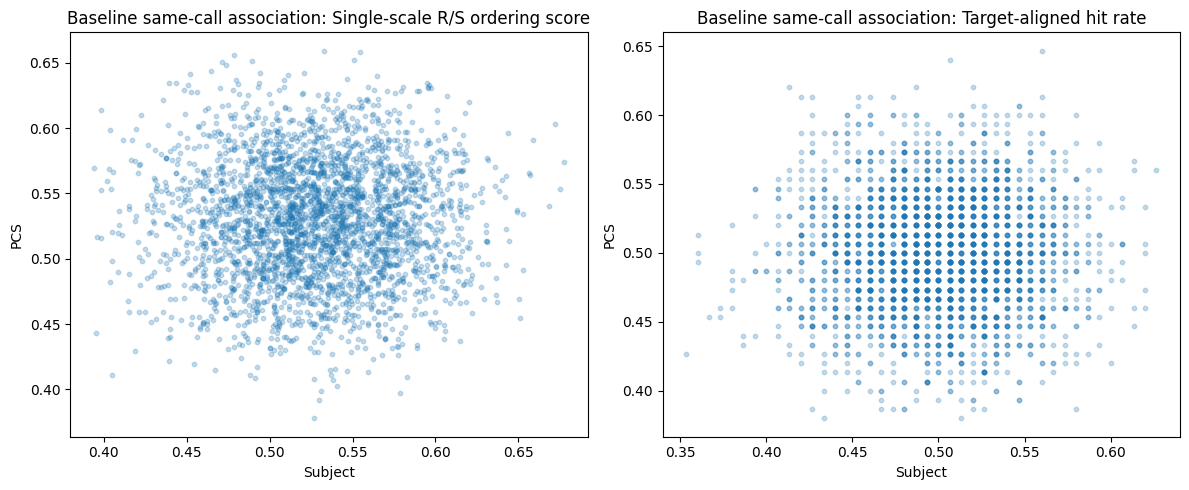

Bounded interpretation: inspect the session-bootstrap intervals and within-session
permutation p-values above. A result that does not resolve an association supports only
'no same-call linear or rank association detected at the available resolution.'


In [ ]:
def c10_corr_stat(x, y, method):
    if method == "pearson":
        return stats.pearsonr(x, y).statistic
    if method == "spearman":
        return stats.spearmanr(x, y).statistic
    raise ValueError(method)

def c10_clustered_correlation(data, x_col, y_col, label, seed):
    work = data[["session_id", x_col, y_col]].dropna().copy()
    groups = [group[[x_col, y_col]].to_numpy(float)
              for _, group in work.groupby("session_id", sort=True)]
    if len(groups) < 2 or sum(len(group) for group in groups) < 10:
        return {"condition": label, "metric": x_col, "blocks": len(work),
                "sessions": len(groups), "pearson_r": np.nan,
                "pearson_ci_low": np.nan, "pearson_ci_high": np.nan,
                "pearson_perm_p": np.nan, "spearman_rho": np.nan,
                "spearman_ci_low": np.nan, "spearman_ci_high": np.nan,
                "spearman_perm_p": np.nan}

    x = work[x_col].to_numpy(float)
    y = work[y_col].to_numpy(float)
    observed = {method: c10_corr_stat(x, y, method)
                for method in ("pearson", "spearman")}
    rng_local = default_rng(seed)
    boot = {"pearson": np.empty(N_BOOT_C10), "spearman": np.empty(N_BOOT_C10)}
    for draw in range(N_BOOT_C10):
        sampled = rng_local.integers(0, len(groups), size=len(groups))
        stacked = np.concatenate([groups[index] for index in sampled], axis=0)
        for method in boot:
            boot[method][draw] = c10_corr_stat(stacked[:, 0], stacked[:, 1], method)

    perm = {"pearson": np.empty(N_PERM_C10), "spearman": np.empty(N_PERM_C10)}
    for draw in range(N_PERM_C10):
        shuffled = []
        for group in groups:
            permuted = group.copy()
            permuted[:, 1] = rng_local.permutation(permuted[:, 1])
            shuffled.append(permuted)
        stacked = np.concatenate(shuffled, axis=0)
        for method in perm:
            perm[method][draw] = c10_corr_stat(stacked[:, 0], stacked[:, 1], method)

    pearson_ci = np.quantile(boot["pearson"], [0.025, 0.975])
    spearman_ci = np.quantile(boot["spearman"], [0.025, 0.975])
    pearson_p = ((np.count_nonzero(np.abs(perm["pearson"]) >= abs(observed["pearson"])) + 1)
                 / (N_PERM_C10 + 1))
    spearman_p = ((np.count_nonzero(np.abs(perm["spearman"]) >= abs(observed["spearman"])) + 1)
                  / (N_PERM_C10 + 1))
    return {
        "condition": label, "metric": x_col, "blocks": len(work), "sessions": len(groups),
        "pearson_r": observed["pearson"], "pearson_ci_low": pearson_ci[0],
        "pearson_ci_high": pearson_ci[1], "pearson_perm_p": pearson_p,
        "spearman_rho": observed["spearman"], "spearman_ci_low": spearman_ci[0],
        "spearman_ci_high": spearman_ci[1], "spearman_perm_p": spearman_p,
    }

association_rows_c10 = []
for condition_index, (condition, subset) in enumerate(c10_data.groupby("condition", sort=True)):
    association_rows_c10.append(c10_clustered_correlation(
        subset, "hurst_subject", "hurst_pcs", condition,
        C10_SEED + 100 * condition_index + 1
    ))
    association_rows_c10.append(c10_clustered_correlation(
        subset, "subject_hit_rate", "pcs_hit_rate", condition,
        C10_SEED + 100 * condition_index + 2
    ))

association_c10 = pd.DataFrame(association_rows_c10)
display(association_c10.round(6))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, x_col, y_col, title in [
    (axes[0], "hurst_subject", "hurst_pcs", "Single-scale R/S ordering score"),
    (axes[1], "subject_hit_rate", "pcs_hit_rate", "Target-aligned hit rate"),
]:
    plot_data = c10_baseline[[x_col, y_col]].dropna()
    ax.scatter(plot_data[x_col], plot_data[y_col], alpha=0.25, s=10)
    ax.set(title=f"Baseline same-call association: {title}", xlabel="Subject", ylabel="PCS")
plt.tight_layout()
plt.show()

print("Bounded interpretation: inspect the session-bootstrap intervals and within-session")
print("permutation p-values above. A result that does not resolve an association supports only")
print("'no same-call linear or rank association detected at the available resolution.'")


### Analysis 2 — Paired-delta location and shape

The observed Baseline distributions are summarized by their mean, SD, quantiles, skewness, and excess kurtosis. Whole-session bootstrap intervals quantify uncertainty in the block-weighted mean. Histograms and Q–Q plots describe shape; no normality test is converted into a “normal” decision. Compatibility of a confidence interval with zero is not an equivalence claim because no scientifically meaningful equivalence margin has been specified.


,metric,blocks,sessions,mean,mean_ci_low,mean_ci_high,sd,skewness,excess_kurtosis,q025,q25,median,q75,q975
0,Baseline delta H,3090,103,-0.001741,-0.003941,0.000440,0.064154,-0.054594,-0.111011,-0.129206,-0.045704,-0.000579,0.041533,0.123813
1,Baseline delta hit rate,3090,103,0.000201,-0.001793,0.002207,0.057743,-0.041540,-0.015416,-0.113333,-0.040000,0.000000,0.040000,0.113333


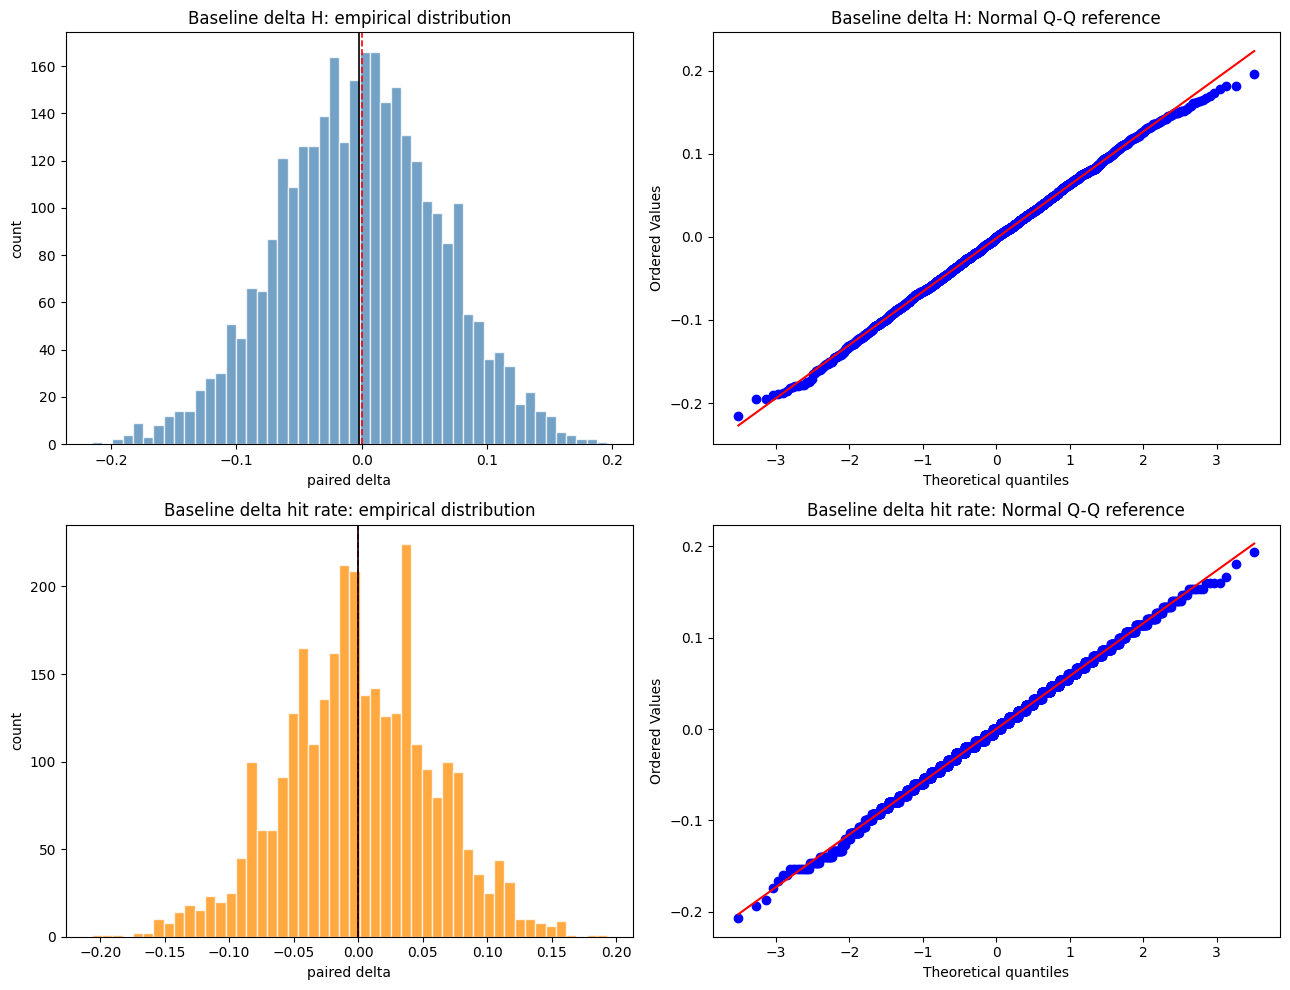

Bounded interpretation: these are empirical Baseline reference distributions.
The mean intervals describe session-aware uncertainty; they do not establish exact
centering, normality, or equivalence to zero.


In [ ]:
def c10_delta_summary(data, value_col, label, seed):
    work = data[["session_id", value_col]].dropna().copy()
    grouped = work.groupby("session_id")[value_col].agg(["sum", "count"])
    sums = grouped["sum"].to_numpy(float)
    counts = grouped["count"].to_numpy(float)
    rng_local = default_rng(seed)
    indices = rng_local.integers(0, len(grouped), size=(N_BOOT_C10, len(grouped)))
    draws = sums[indices].sum(axis=1) / counts[indices].sum(axis=1)
    values = work[value_col].to_numpy(float)
    quantiles = np.quantile(values, [0.025, 0.25, 0.50, 0.75, 0.975])
    return {
        "metric": label, "blocks": len(work), "sessions": len(grouped),
        "mean": values.mean(), "mean_ci_low": np.quantile(draws, 0.025),
        "mean_ci_high": np.quantile(draws, 0.975), "sd": values.std(ddof=1),
        "skewness": stats.skew(values, bias=False),
        "excess_kurtosis": stats.kurtosis(values, fisher=True, bias=False),
        "q025": quantiles[0], "q25": quantiles[1], "median": quantiles[2],
        "q75": quantiles[3], "q975": quantiles[4], "values": values,
    }

delta_hurst_c10 = c10_delta_summary(c10_baseline, "delta_hurst", "Baseline delta H", C10_SEED + 11)
delta_hit_c10 = c10_delta_summary(c10_baseline, "delta_hit", "Baseline delta hit rate", C10_SEED + 12)
delta_summary_c10 = pd.DataFrame([
    {key: value for key, value in result.items() if key != "values"}
    for result in (delta_hurst_c10, delta_hit_c10)
])
display(delta_summary_c10.round(8))

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for row, result, color in [
    (0, delta_hurst_c10, "steelblue"),
    (1, delta_hit_c10, "darkorange"),
]:
    values = result["values"]
    axes[row, 0].hist(values, bins=50, color=color, alpha=0.75, edgecolor="white")
    axes[row, 0].axvline(0, color="red", linestyle="--", linewidth=1.2)
    axes[row, 0].axvline(result["mean"], color="black", linewidth=1.2)
    axes[row, 0].set(title=f'{result["metric"]}: empirical distribution', xlabel="paired delta", ylabel="count")
    stats.probplot(values, dist="norm", plot=axes[row, 1])
    axes[row, 1].set_title(f'{result["metric"]}: Normal Q-Q reference')
plt.tight_layout()
plt.show()

print("Bounded interpretation: these are empirical Baseline reference distributions.")
print("The mean intervals describe session-aware uncertainty; they do not establish exact")
print("centering, normality, or equivalence to zero.")


### Analysis 3 — Baseline Offset — Synthetic-Pipeline Check and Bootstrap Seed Stability

Two checks on Baseline's realized paired offset (`delta_hurst`, mean ≈ −0.0017, not individually resolved), neither of which currently exists anywhere in this notebook.

**Part 1 — synthetic-pipeline check.** Runs the actual production scoring/assignment logic (`hurstApprox`, the assignment-bit half-split rule) on purely synthetic fair-Bernoulli(0.5) bits — not real QRNG output — at the exact same scale as real Baseline (103 sessions × 30 blocks), 200 repetitions. If the real Baseline offset falls inside the resulting null range, the processing pipeline itself (scoring + assignment, independent of any real hardware bias) does not produce a spurious offset of this size on its own.

**Part 2 — bootstrap seed stability.** The existing whole-session bootstrap CI on Baseline's `delta_hurst` (cell 49, `c10_delta_summary`) depends on a fixed seed. Re-running the identical methodology with several different seeds checks whether the CI's *qualitative* conclusion (includes zero, not individually resolved) is stable, even though the exact decimal boundaries shift slightly from run to run — ordinary percentile-bootstrap Monte Carlo variation at N=103 clusters, not a substantive disagreement.

**Requires** (already defined earlier in this notebook): `base_df` (or `c10_baseline`), `np`, `default_rng`.

In [ ]:
# ═════════════════════════════════════════════════════════════════════════════
# Part 1 — Synthetic-pipeline check for the Baseline paired offset
# ═════════════════════════════════════════════════════════════════════════════
print("=" * 92)
print("BASELINE OFFSET — SYNTHETIC-PIPELINE CHECK")
print("=" * 92)

SPC_N_SESSIONS = 103          # matches real Baseline session count exactly
SPC_BLOCKS_PER_SESSION = 30   # matches real Baseline (constant 30 blocks/session)
SPC_N = 150                   # bits per half, matches TRIALS_PER_BLOCK
SPC_N_REPS = 200
SPC_SEED_BASE = 1_000_000


def spc_hurst_batch(bits2d):
    """Vectorized exact port of this notebook's scalar hurstApprox."""
    x = np.where(bits2d != 0, 1.0, -1.0)
    n = bits2d.shape[1]
    mean = x.mean(axis=1, keepdims=True)
    d = x - mean
    y = np.cumsum(d, axis=1)
    max_y = np.maximum(0.0, y.max(axis=1))
    min_y = np.minimum(0.0, y.min(axis=1))
    R = max_y - min_y
    S = np.sqrt((d * d).sum(axis=1) / n)
    S = np.where(S == 0, 1.0, S)
    ratio = np.where(R != 0, R / S, 1.0)
    H = np.log(np.where(ratio != 0, ratio, 1.0)) / np.log(n)
    H = np.where(np.isfinite(H), H, 0.5)
    return np.clip(H, 0.0, 1.0)


n_blocks_total = SPC_N_SESSIONS * SPC_BLOCKS_PER_SESSION
spc_rep_means = np.empty(SPC_N_REPS)

for rep in range(SPC_N_REPS):
    rng = np.random.default_rng(SPC_SEED_BASE + rep)
    # 301 fair independent Bernoulli(0.5) bits per block: 1 assignment bit + 300 trial bits
    bits301 = rng.integers(0, 2, size=(n_blocks_total, 301)).astype(np.int8)
    assignment_bit = bits301[:, 0]
    half_a = bits301[:, 1:1 + SPC_N]
    half_b = bits301[:, 1 + SPC_N:1 + 2 * SPC_N]
    # Verbatim assignment logic from production processTrials: bit==1 -> subject=halfA
    subject_gets_first_half = (assignment_bit == 1)[:, None]
    subject_bits = np.where(subject_gets_first_half, half_a, half_b)
    demon_bits = np.where(subject_gets_first_half, half_b, half_a)

    h_subject = spc_hurst_batch(subject_bits)
    h_demon = spc_hurst_batch(demon_bits)
    spc_rep_means[rep] = (h_subject - h_demon).mean()

spc_mean_of_means = spc_rep_means.mean()
spc_p025, spc_p975 = np.quantile(spc_rep_means, [0.025, 0.975])

print(f"N_REPS={SPC_N_REPS}, N_SESSIONS={SPC_N_SESSIONS}, "
      f"BLOCKS_PER_SESSION={SPC_BLOCKS_PER_SESSION}, N={SPC_N}")
print(f"Mean of the {SPC_N_REPS} synthetic paired means: {spc_mean_of_means:.6f}")
print(f"2.5th/97.5th percentile of the {SPC_N_REPS} paired means: "
      f"[{spc_p025:.6f}, {spc_p975:.6f}]")
print(f"SD of the {SPC_N_REPS} paired means: {spc_rep_means.std(ddof=1):.6f}")

real_baseline_offset = float(base_df["delta_hurst"].mean())
spc_inside = spc_p025 <= real_baseline_offset <= spc_p975
print(f"\nReal Baseline offset: {real_baseline_offset:+.6f}")
print(f"Falls {'INSIDE' if spc_inside else 'OUTSIDE'} the central 95% of the "
      f"synthetic null distribution.")
print("\nThis addresses a possible artifact of the processing pipeline (scoring +")
print("assignment logic applied to bits with no real hardware bias), not the natural")
print("sampling variation of the real Subject/PCS data.")

BASELINE OFFSET — SYNTHETIC-PIPELINE CHECK
N_REPS=200, N_SESSIONS=103, BLOCKS_PER_SESSION=30, N=150
Mean of the 200 synthetic paired means: -0.000033
2.5th/97.5th percentile of the 200 paired means: [-0.002349, 0.002261]
SD of the 200 paired means: 0.001162

Real Baseline offset: -0.001741
Falls INSIDE the central 95% of the synthetic null distribution.

This addresses a possible artifact of the processing pipeline (scoring +
assignment logic applied to bits with no real hardware bias), not the natural
sampling variation of the real Subject/PCS data.


### Analysis 4 — Covariance contribution to paired-delta variance

The within-session permutation reference produces one covariance and one paired-delta variance statistic per permutation. It does not concatenate permutation-level deltas into a pseudo-sample. The covariance contribution is reported directly as `−2 × covariance`; `1 − variance ratio` is not labeled as a correlation.


In [ ]:
def c10_variance_decomposition(data, subject_col, pcs_col, metric, seed):
    work = data[["session_id", subject_col, pcs_col]].dropna().copy()
    subject = work[subject_col].to_numpy(float)
    pcs = work[pcs_col].to_numpy(float)
    groups = [group[[subject_col, pcs_col]].to_numpy(float)
              for _, group in work.groupby("session_id", sort=True)]

    var_subject = np.var(subject, ddof=1)
    var_pcs = np.var(pcs, ddof=1)
    covariance = np.cov(subject, pcs, ddof=1)[0, 1]
    correlation = stats.pearsonr(subject, pcs).statistic
    delta_variance = np.var(subject - pcs, ddof=1)
    variance_sum = var_subject + var_pcs
    variance_ratio = delta_variance / variance_sum
    covariance_contribution = -2.0 * covariance
    sd_delta_over_subject = np.sqrt(delta_variance) / np.sqrt(var_subject)
    identity_error = delta_variance - (variance_sum + covariance_contribution)

    rng_local = default_rng(seed)
    perm_covariance = np.empty(N_PERM_C10)
    perm_delta_variance = np.empty(N_PERM_C10)
    perm_variance_ratio = np.empty(N_PERM_C10)
    for draw in range(N_PERM_C10):
        shuffled = []
        for group in groups:
            permuted = group.copy()
            permuted[:, 1] = rng_local.permutation(permuted[:, 1])
            shuffled.append(permuted)
        stacked = np.concatenate(shuffled, axis=0)
        s_perm, p_perm = stacked[:, 0], stacked[:, 1]
        perm_covariance[draw] = np.cov(s_perm, p_perm, ddof=1)[0, 1]
        perm_delta_variance[draw] = np.var(s_perm - p_perm, ddof=1)
        perm_variance_ratio[draw] = perm_delta_variance[draw] / variance_sum

    covariance_p = ((np.count_nonzero(np.abs(perm_covariance) >= abs(covariance)) + 1)
                    / (N_PERM_C10 + 1))
    return {
        "metric": metric, "blocks": len(work), "sessions": len(groups),
        "subject_variance": var_subject, "pcs_variance": var_pcs,
        "covariance": covariance, "pearson_r": correlation,
        "delta_variance": delta_variance, "variance_sum_benchmark": variance_sum,
        "variance_ratio": variance_ratio,
        "covariance_contribution_minus_2cov": covariance_contribution,
        "sd_delta_over_sd_subject": sd_delta_over_subject,
        "identity_error": identity_error, "within_session_perm_p_covariance": covariance_p,
        "perm_delta_variance_q025": np.quantile(perm_delta_variance, 0.025),
        "perm_delta_variance_q975": np.quantile(perm_delta_variance, 0.975),
        "perm_variance_ratio_q025": np.quantile(perm_variance_ratio, 0.025),
        "perm_variance_ratio_q975": np.quantile(perm_variance_ratio, 0.975),
    }

variance_c10 = pd.DataFrame([
    c10_variance_decomposition(
        c10_baseline, "hurst_subject", "hurst_pcs", "Baseline single-scale R/S ordering score", C10_SEED + 21
    ),
    c10_variance_decomposition(
        c10_baseline, "subject_hit_rate", "pcs_hit_rate", "Baseline target-aligned hit rate", C10_SEED + 22
    ),
])
assert np.all(np.abs(variance_c10["identity_error"]) < 1e-12)
display(variance_c10.round(8))

print("Bounded interpretation: the covariance term quantifies how much observed same-call")
print("covariance contributes to paired-delta variance in this Baseline cohort. Small or")
print("unresolved covariance does not prove independence or show that pairing is universally inert.")


,metric,blocks,sessions,subject_variance,pcs_variance,covariance,pearson_r,delta_variance,variance_sum_benchmark,variance_ratio,covariance_contribution_minus_2cov,sd_delta_over_sd_subject,identity_error,within_session_perm_p_covariance,perm_delta_variance_q025,perm_delta_variance_q975,perm_variance_ratio_q025,perm_variance_ratio_q975
0,Baseline single-scale R/S ordering score,3090,103,0.002114,0.002017,0.000008,0.003729,0.004116,0.004131,0.996272,-0.000015,1.395149,0.0,0.829417,0.003976,0.004264,0.962444,1.032056
1,Baseline target-aligned hit rate,3090,103,0.001678,0.001707,0.000025,0.014864,0.003334,0.003385,0.985136,-0.000050,1.409637,-0.0,0.399860,0.003267,0.003500,0.965257,1.034125


Bounded interpretation: the covariance term quantifies how much observed same-call
covariance contributes to paired-delta variance in this Baseline cohort. Small or
unresolved covariance does not prove independence or show that pairing is universally inert.


### Empirical physical-half calibration for Paper §3.3.4

This synthesis uses the already-computed Baseline physical-half and same-call results at the protocol's actual 150-bit half length. It replaces the former 150–2,400-bit split-length calibration, whose comparison arms were mathematically identical. No new test family is introduced here.

The physical A-minus-B contrast addresses marginal asymmetry before Subject/PCS assignment. The same-call association and paired-delta variance ratio address detectable linear dependence after the recorded assignment. Together they can support a bounded statement of **no detected asymmetry or linear dependence at 150 bits**; they cannot establish exact equivalence, complete independence, or absence of every boundary, cross-lag, nonlinear, or time-varying effect.


In [ ]:
# PAPER §3.3.4 SYNTHESIS — reuse finalized results. To recompute run Baseline-Raw-Call/Analysis 1 & Analysis 4 first
half_rs_c334 = primary_c9.loc[primary_c9["estimand"].eq("Half A - B R/S ordering score")].iloc[0]
assoc_rs_c334 = association_c10.loc[
    association_c10["condition"].eq("baseline")
    & association_c10["metric"].eq("hurst_subject")
].iloc[0]
variance_rs_c334 = variance_c10.loc[
    variance_c10["metric"].eq("Baseline single-scale R/S ordering score")
].iloc[0]

assert int(half_rs_c334["sessions"]) == int(assoc_rs_c334["sessions"]) == 103
assert int(assoc_rs_c334["blocks"]) == int(variance_rs_c334["blocks"]) == 3090

print("PAPER §3.3.4 — EMPIRICAL PHYSICAL-HALF CALIBRATION")
print(f"Protocol length: 150 bits per physical half; Baseline calls: {int(assoc_rs_c334['blocks']):,}; sessions: {int(assoc_rs_c334['sessions'])}")
print(f"Physical A-B R/S-score difference: {half_rs_c334['estimate']:+.6f}")
print(f"Whole-session bootstrap 95% CI: [{half_rs_c334['ci_low']:+.6f}, {half_rs_c334['ci_high']:+.6f}]")
print(f"Same-call Pearson r: {assoc_rs_c334['pearson_r']:+.4f}")
print(f"Whole-session bootstrap 95% CI: [{assoc_rs_c334['pearson_ci_low']:+.4f}, {assoc_rs_c334['pearson_ci_high']:+.4f}]")
print(f"Within-session permutation p: {assoc_rs_c334['pearson_perm_p']:.4f}")
print(f"Paired-delta variance / sum-of-variances benchmark: {variance_rs_c334['variance_ratio']:.6f}")
print(f"Permutation reference range: [{variance_rs_c334['perm_variance_ratio_q025']:.6f}, {variance_rs_c334['perm_variance_ratio_q975']:.6f}]")
print("Bounded conclusion: no systematic marginal R/S-score asymmetry or detectable")
print("same-call linear association was found at 150 bits. This is not an equivalence")
print("result and does not exclude every boundary, nonlinear, cross-lag, or weak effect.")


PAPER §3.3.4 — EMPIRICAL PHYSICAL-HALF CALIBRATION
Protocol length: 150 bits per physical half; Baseline calls: 3,090; sessions: 103
Physical A-B R/S-score difference: -0.000682
Whole-session bootstrap 95% CI: [-0.003008, +0.001722]
Same-call Pearson r: +0.0037
Whole-session bootstrap 95% CI: [-0.0306, +0.0371]
Within-session permutation p: 0.8357
Paired-delta variance / sum-of-variances benchmark: 0.996272
Permutation reference range: [0.962444, 1.032056]
Bounded conclusion: no systematic marginal R/S-score asymmetry or detectable
same-call linear association was found at 150 bits. This is not an equivalence
result and does not exclude every boundary, nonlinear, cross-lag, or weak effect.


### Baseline empirical paired-delta interpretation boundary

This section supplies an empirical Baseline reference for the two prespecified paired metrics. It permits descriptive statements about observed association, distribution shape, mean uncertainty, and covariance contribution under the retained acquisition regime.

It does **not** establish universal independence, exact zero centering, normality, equivalence, or protection from every shared artifact. Assignment-bit and physical-half diagnostics are handled in **Baseline Raw-Call Positional and Assignment-Bit Diagnostics**; the upstream perturbation checks begin in **Upstream Artifact-Injection Validation**.


# Upstream Artifact-Injection Validation

This positive-control section perturbs the raw 150-bit physical halves **before** Subject/PCS label assignment and metric computation. It then reruns the recorded assignment, target scoring, single-scale R/S-score computation, and paired subtraction.

Each nonzero dose is simulated with multiple independent artifact realizations. Two equal-strength shared-mechanism models are kept distinct: **synchronized**, where both physical halves receive the same affected-position mask, and **independent-position**, where they receive independently realized masks at the same dose. These are bounded tests of specified literal-bit bias and persistence mechanisms—not proof of protection against every hardware artifact. The recorded assignment bit is held fixed, so assignment-bit-altering or assignment-bit-interacting artifacts remain untested.


### Prepare the retained Baseline raw-call cohort

The cohort is joined one-to-one to the canonical retained Baseline blocks. Clean reconstructed scores must equal the frozen scores row by row before any perturbation is applied.


In [ ]:
# Retained Baseline calls, joined one-to-one to canonical targets and outcomes
injection_base = baseline_raw_calls.merge(
    base_df[[
        "session_id", "block_idx", "target_bit", "subject_hit_rate", "pcs_hit_rate",
        "hurst_subject", "hurst_pcs", "delta_hit", "delta_hurst"
    ]],
    on=["session_id", "block_idx"], how="inner", validate="one_to_one"
).sort_values(["session_id", "block_idx"]).reset_index(drop=True)

assert len(injection_base) == len(base_df) == 3090

physical_A = np.stack(injection_base["halfA"].to_numpy()).astype(np.int8)
physical_B = np.stack(injection_base["halfB"].to_numpy()).astype(np.int8)
assignment = injection_base["bit0"].to_numpy(dtype=np.int8)
targets = injection_base["target_bit"].to_numpy(dtype=np.int8)
injection_sessions = injection_base["session_id"].to_numpy()

def assign_physical_halves(half_a, half_b, assignment_bits):
    """Apply the recorded bit-0 labeling rule after a raw-half perturbation."""
    subject = np.where(assignment_bits[:, None] == 1, half_a, half_b)
    pcs = np.where(assignment_bits[:, None] == 1, half_b, half_a)
    return subject.astype(np.int8), pcs.astype(np.int8)

def score_target_matrix(bit_matrix, target_vector):
    return (bit_matrix == target_vector[:, None]).mean(axis=1)

def hurst_matrix(bit_matrix):
    return np.fromiter((hurstApprox(row) for row in bit_matrix), dtype=float, count=len(bit_matrix))

clean_subject_bits, clean_pcs_bits = assign_physical_halves(physical_A, physical_B, assignment)
clean_subject_hit = score_target_matrix(clean_subject_bits, targets)
clean_pcs_hit = score_target_matrix(clean_pcs_bits, targets)
clean_subject_hurst = hurst_matrix(clean_subject_bits)
clean_pcs_hurst = hurst_matrix(clean_pcs_bits)

assert np.allclose(clean_subject_hit, injection_base["subject_hit_rate"])
assert np.allclose(clean_pcs_hit, injection_base["pcs_hit_rate"])
assert np.allclose(clean_subject_hurst, injection_base["hurst_subject"], equal_nan=True)
assert np.allclose(clean_pcs_hurst, injection_base["hurst_pcs"], equal_nan=True)

clean_delta_hit = clean_subject_hit - clean_pcs_hit
clean_delta_hurst = clean_subject_hurst - clean_pcs_hurst

print(f"Baseline raw calls validated row by row: {len(injection_base):,}")
print("Target counts:", dict(zip(*np.unique(targets, return_counts=True))))
print("Clean reconstruction mismatches: 0")


Baseline raw calls validated row by row: 3,090
Target counts: {np.int8(0): np.int64(1540), np.int8(1): np.int64(1550)}
Clean reconstruction mismatches: 0


### Prespecified perturbations, recovery estimands, and uncertainty

- **Shared literal-bit bias:** a call-level direction pushes both physical halves toward literal 0 or 1. Target-0 and target-1 rows are scored against their actual targets and also reported separately.
- **Shared persistence:** selected positions repeat the preceding bit before Hurst is recomputed.
- **Synchronized masks:** both halves receive the same affected-position mask.
- **Independent-position masks:** both halves receive independent masks drawn at the same dose.
- **Stream-specific control:** a target-relative perturbation is applied to the labeled Subject stream only.
- **Unequal-half failure case:** persistence is stronger in physical half A than half B.

For each realization, the row-wise recovery error is `delta_artifact - delta_clean`. Across-realization SD and quantiles describe injection randomness. Separately, a whole-session bootstrap interval is computed from the row-wise mean recovery error across realizations; this describes session-sampling uncertainty for the simulation-average effect. Signed mean and RMS are reported without KS ratios or “percent cancellation.”


In [ ]:
INJECTION_SEED = 20260804
BOOTSTRAP_SEED = 20260805
N_ARTIFACT_REALIZATIONS = 50
N_SESSION_BOOTSTRAPS = 3000
BIAS_DOSES = [0.00, 0.02, 0.05, 0.10, 0.20]
PERSISTENCE_DOSES = [0.00, 0.05, 0.10, 0.20, 0.35]

def apply_literal_bias(bits, direction, dose, uniforms):
    out = bits.copy()
    chosen = uniforms < dose
    out[chosen] = np.broadcast_to(direction[:, None], bits.shape)[chosen]
    return out

def apply_persistence(bits, dose, uniforms):
    out = bits.copy()
    selected = uniforms[:, 1:] < dose
    for position in range(1, bits.shape[1]):
        mask = selected[:, position - 1]
        out[mask, position] = out[mask, position - 1]
    return out

def apply_target_relative_subject(bits, target_vector, dose, uniforms):
    out = bits.copy()
    chosen = uniforms < dose
    target_matrix = np.broadcast_to(target_vector[:, None], bits.shape)
    out[chosen] = target_matrix[chosen]
    return out

def session_bootstrap_mean(change, n_boot=N_SESSION_BOOTSTRAPS, seed=BOOTSTRAP_SEED):
    frame = pd.DataFrame({"session_id": injection_sessions, "change": change}).dropna()
    grouped = frame.groupby("session_id")["change"].agg(["sum", "count"])
    sums, counts = grouped["sum"].to_numpy(), grouped["count"].to_numpy()
    rng = default_rng(seed)
    draws = np.empty(n_boot)
    for i in range(n_boot):
        sampled = rng.integers(0, len(grouped), size=len(grouped))
        draws[i] = sums[sampled].sum() / counts[sampled].sum()
    return np.quantile(draws, [0.025, 0.975])

def summarize_realizations(model, metric, dose, errors, subject_changes, pcs_changes,
                           target_group="all"):
    errors = np.asarray(errors, dtype=float)
    subject_changes = np.asarray(subject_changes, dtype=float)
    pcs_changes = np.asarray(pcs_changes, dtype=float)
    if target_group == "all":
        keep = np.ones(len(targets), dtype=bool)
    else:
        keep = targets == int(target_group)
    e = errors[:, keep]
    s = subject_changes[:, keep]
    p = pcs_changes[:, keep]
    realization_means = np.nanmean(e, axis=1)
    mean_row_error = np.nanmean(errors, axis=0)
    ci_low, ci_high = session_bootstrap_mean(
        mean_row_error[keep],
        seed=BOOTSTRAP_SEED + int(dose * 10000) + (0 if target_group == "all" else 100 + int(target_group))
    ) if target_group == "all" else session_bootstrap_mean_for_subset(mean_row_error, keep, dose, target_group)
    return {
        "model": model, "metric": metric, "dose": dose, "target_group": str(target_group),
        "n_realizations": errors.shape[0],
        "subject_change_rms": np.sqrt(np.nanmean(np.square(s))),
        "pcs_change_rms": np.sqrt(np.nanmean(np.square(p))),
        "recovery_error_mean": np.nanmean(e),
        "session_ci_low": ci_low, "session_ci_high": ci_high,
        "realization_mean_sd": np.nanstd(realization_means, ddof=1) if len(realization_means) > 1 else 0.0,
        "realization_q025": np.nanquantile(realization_means, 0.025),
        "realization_q975": np.nanquantile(realization_means, 0.975),
        "recovery_error_rms": np.sqrt(np.nanmean(np.square(e))),
    }

def session_bootstrap_mean_for_subset(change, keep, dose, target_group):
    frame = pd.DataFrame({
        "session_id": injection_sessions[keep], "change": change[keep]
    }).dropna()
    grouped = frame.groupby("session_id")["change"].agg(["sum", "count"])
    sums, counts = grouped["sum"].to_numpy(), grouped["count"].to_numpy()
    rng = default_rng(BOOTSTRAP_SEED + int(dose * 10000) + 100 + int(target_group))
    draws = np.empty(N_SESSION_BOOTSTRAPS)
    for i in range(N_SESSION_BOOTSTRAPS):
        sampled = rng.integers(0, len(grouped), size=len(grouped))
        draws[i] = sums[sampled].sum() / counts[sampled].sum()
    return np.quantile(draws, [0.025, 0.975])

def simulate_equal_half_model(kind, dose, synchronized, realization_seed):
    rng = default_rng(realization_seed)
    if kind == "literal bias":
        direction = rng.integers(0, 2, size=len(physical_A), dtype=np.int8)
        u_a = rng.random(physical_A.shape)
        u_b = u_a if synchronized else rng.random(physical_B.shape)
        a_art = apply_literal_bias(physical_A, direction, dose, u_a)
        b_art = apply_literal_bias(physical_B, direction, dose, u_b)
        subj_bits, pcs_bits = assign_physical_halves(a_art, b_art, assignment)
        subj, pcs = score_target_matrix(subj_bits, targets), score_target_matrix(pcs_bits, targets)
        clean_subj, clean_p = clean_subject_hit, clean_pcs_hit
    else:
        u_a = rng.random(physical_A.shape)
        u_b = u_a if synchronized else rng.random(physical_B.shape)
        a_art = apply_persistence(physical_A, dose, u_a)
        b_art = apply_persistence(physical_B, dose, u_b)
        subj_bits, pcs_bits = assign_physical_halves(a_art, b_art, assignment)
        subj, pcs = hurst_matrix(subj_bits), hurst_matrix(pcs_bits)
        clean_subj, clean_p = clean_subject_hurst, clean_pcs_hurst
    return (subj - pcs) - (clean_subj - clean_p), subj - clean_subj, pcs - clean_p

print(f"Artifact realizations per nonzero dose: {N_ARTIFACT_REALIZATIONS}")
print(f"Whole-session bootstrap draws: {N_SESSION_BOOTSTRAPS}")


Artifact realizations per nonzero dose: 50
Whole-session bootstrap draws: 3000


### Shared literal-bit bias: synchronized versus independent-position masks

This tests a raw composition artifact, not generic “hit-rate drift.” Its target-aligned consequences can reverse with the target, so target-0 and target-1 diagnostics are included. The two mask models distinguish synchronized common-mode disturbance from equal-strength disturbance with independently affected positions.


In [ ]:
bias_rows = []
for synchronized in [True, False]:
    mask_label = "synchronized mask" if synchronized else "independent-position masks"
    for dose in BIAS_DOSES:
        n_rep = 1 if dose == 0 else N_ARTIFACT_REALIZATIONS
        simulated = [simulate_equal_half_model(
            "literal bias", dose, synchronized,
            INJECTION_SEED + 100000 * int(not synchronized) + int(dose * 10000) + r
        ) for r in range(n_rep)]
        errors, subject_changes, pcs_changes = map(np.stack, zip(*simulated))
        for target_group in ["all", 0, 1]:
            bias_rows.append(summarize_realizations(
                f"shared literal bias — {mask_label}", "target-aligned hit rate", dose,
                errors, subject_changes, pcs_changes, target_group
            ))

bias_results = pd.DataFrame(bias_rows)
print(bias_results[[
    "model", "dose", "target_group", "recovery_error_mean", "session_ci_low",
    "session_ci_high", "realization_mean_sd", "realization_q025",
    "realization_q975", "recovery_error_rms"
]].to_string(index=False, float_format=lambda x: f"{x:.6f}"))
assert np.all(bias_results.loc[bias_results["dose"].eq(0), "recovery_error_rms"] == 0)


                                           model     dose target_group  recovery_error_mean  session_ci_low  session_ci_high  realization_mean_sd  realization_q025  realization_q975  recovery_error_rms
         shared literal bias — synchronized mask 0.000000          all             0.000000        0.000000         0.000000             0.000000          0.000000          0.000000            0.000000
         shared literal bias — synchronized mask 0.000000            0             0.000000        0.000000         0.000000             0.000000          0.000000          0.000000            0.000000
         shared literal bias — synchronized mask 0.000000            1             0.000000        0.000000         0.000000             0.000000          0.000000          0.000000            0.000000
         shared literal bias — synchronized mask 0.020000          all            -0.000031       -0.000088         0.000024             0.000146         -0.000263          0.000220           

### Shared persistence: synchronized versus independent-position masks

Persistence is applied upstream to each physical half and the single-scale R/S ordering score is recomputed. Synchronized masks test a tightly shared position-level disturbance; independent-position masks test equal dose and mechanism without identical affected positions. Neither model alters the recorded assignment bit.


In [ ]:
persistence_rows = []
for synchronized in [True, False]:
    mask_label = "synchronized mask" if synchronized else "independent-position masks"
    for dose in PERSISTENCE_DOSES:
        n_rep = 1 if dose == 0 else N_ARTIFACT_REALIZATIONS
        simulated = [simulate_equal_half_model(
            "persistence", dose, synchronized,
            INJECTION_SEED + 500000 + 100000 * int(not synchronized) + int(dose * 10000) + r
        ) for r in range(n_rep)]
        errors, subject_changes, pcs_changes = map(np.stack, zip(*simulated))
        persistence_rows.append(summarize_realizations(
            f"shared persistence — {mask_label}", "single-scale R/S ordering score", dose,
            errors, subject_changes, pcs_changes
        ))

persistence_results = pd.DataFrame(persistence_rows)
print(persistence_results[[
    "model", "dose", "subject_change_rms", "pcs_change_rms", "recovery_error_mean",
    "session_ci_low", "session_ci_high", "realization_mean_sd", "realization_q025",
    "realization_q975", "recovery_error_rms"
]].to_string(index=False, float_format=lambda x: f"{x:.6f}"))
assert np.all(persistence_results.loc[persistence_results["dose"].eq(0), "recovery_error_rms"] == 0)


                                          model     dose  subject_change_rms  pcs_change_rms  recovery_error_mean  session_ci_low  session_ci_high  realization_mean_sd  realization_q025  realization_q975  recovery_error_rms
         shared persistence — synchronized mask 0.000000            0.000000        0.000000             0.000000        0.000000         0.000000             0.000000          0.000000          0.000000            0.000000
         shared persistence — synchronized mask 0.050000            0.024737        0.024553             0.000238       -0.000147         0.000616             0.000569         -0.000753          0.001327            0.031930
         shared persistence — synchronized mask 0.100000            0.036053        0.035642             0.000422       -0.000234         0.001082             0.000643         -0.000738          0.001549            0.043243
         shared persistence — synchronized mask 0.200000            0.054905        0.054331            

### Stream-specific control and unequal-half failure case

These controls use multiple realizations too. The labeled Subject-only intervention checks that a stream-specific hit-rate change survives subtraction. Unequal-half persistence checks the expected limitation that a disturbance of different strength in the two physical halves is not common-mode.


In [ ]:
control_rows, unequal_rows = [], []
for dose in BIAS_DOSES:
    n_rep = 1 if dose == 0 else N_ARTIFACT_REALIZATIONS
    sims = []
    for r in range(n_rep):
        rng = default_rng(INJECTION_SEED + 900000 + int(dose * 10000) + r)
        subject_art_bits = apply_target_relative_subject(
            clean_subject_bits, targets, dose, rng.random(clean_subject_bits.shape)
        )
        subject_art = score_target_matrix(subject_art_bits, targets)
        error = subject_art - clean_subject_hit
        sims.append((error, error, np.zeros_like(error)))
    errors, subject_changes, pcs_changes = map(np.stack, zip(*sims))
    control_rows.append(summarize_realizations(
        "labeled Subject-only target shift", "target-aligned hit rate", dose,
        errors, subject_changes, pcs_changes
    ))

for dose in PERSISTENCE_DOSES:
    n_rep = 1 if dose == 0 else N_ARTIFACT_REALIZATIONS
    sims = []
    for r in range(n_rep):
        rng = default_rng(INJECTION_SEED + 1200000 + int(dose * 10000) + r)
        a_art = apply_persistence(physical_A, dose, rng.random(physical_A.shape))
        b_art = apply_persistence(physical_B, dose / 2.0, rng.random(physical_B.shape))
        subj_bits, pcs_bits = assign_physical_halves(a_art, b_art, assignment)
        subj, pcs = hurst_matrix(subj_bits), hurst_matrix(pcs_bits)
        sims.append(((subj - pcs) - clean_delta_hurst,
                     subj - clean_subject_hurst, pcs - clean_pcs_hurst))
    errors, subject_changes, pcs_changes = map(np.stack, zip(*sims))
    unequal_rows.append(summarize_realizations(
        "unequal-half persistence (A=1.0x, B=0.5x)", "single-scale R/S ordering score", dose,
        errors, subject_changes, pcs_changes
    ))

control_results = pd.DataFrame(control_rows)
unequal_results = pd.DataFrame(unequal_rows)
print("Subject-only control")
print(control_results[["dose", "recovery_error_mean", "session_ci_low", "session_ci_high", "realization_mean_sd", "recovery_error_rms"]].to_string(index=False, float_format=lambda x: f"{x:.6f}"))
print("\nUnequal-half failure case")
print(unequal_results[["dose", "recovery_error_mean", "session_ci_low", "session_ci_high", "realization_mean_sd", "recovery_error_rms"]].to_string(index=False, float_format=lambda x: f"{x:.6f}"))


Subject-only control
    dose  recovery_error_mean  session_ci_low  session_ci_high  realization_mean_sd  recovery_error_rms
0.000000             0.000000        0.000000         0.000000             0.000000            0.000000
0.020000             0.010019        0.009968         0.010068             0.000129            0.012912
0.050000             0.024949        0.024859         0.025041             0.000245            0.028020
0.100000             0.050043        0.049881         0.050199             0.000287            0.053122
0.200000             0.099961        0.099652         0.100261             0.000345            0.102921

Unequal-half failure case
    dose  recovery_error_mean  session_ci_low  session_ci_high  realization_mean_sd  recovery_error_rms
0.000000             0.000000        0.000000         0.000000             0.000000            0.000000
0.050000             0.000308       -0.000111         0.000723             0.000476            0.028784
0.100000        

### Dose-response plots and combined recovery table

Plots use the simulation-average RMS. Tables retain two separate uncertainty descriptions: whole-session bootstrap intervals for the across-realization mean row effect, and across-realization SD/quantiles for injection randomness.


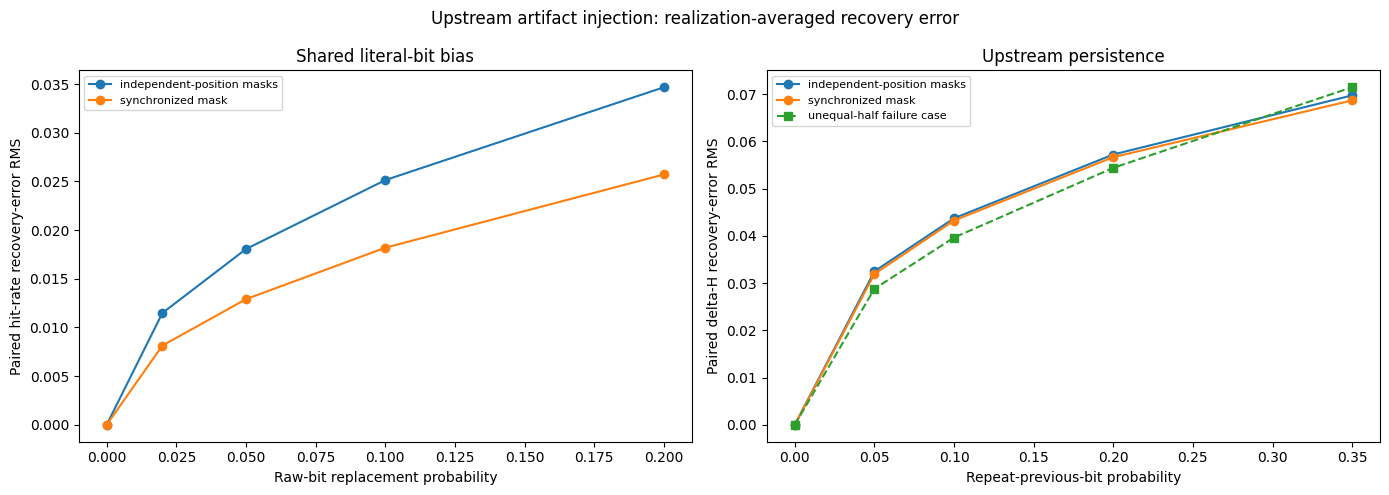


Combined recovery table
                                           model                          metric     dose target_group  n_realizations  recovery_error_mean  session_ci_low  session_ci_high  realization_mean_sd  realization_q025  realization_q975  recovery_error_rms
         shared literal bias — synchronized mask         target-aligned hit rate 0.000000          all               1             0.000000        0.000000         0.000000             0.000000          0.000000          0.000000            0.000000
         shared literal bias — synchronized mask         target-aligned hit rate 0.000000            0               1             0.000000        0.000000         0.000000             0.000000          0.000000          0.000000            0.000000
         shared literal bias — synchronized mask         target-aligned hit rate 0.000000            1               1             0.000000        0.000000         0.000000             0.000000          0.000000          0.00

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bias_plot = bias_results[bias_results["target_group"].eq("all")]
for model, group in bias_plot.groupby("model"):
    axes[0].plot(group["dose"], group["recovery_error_rms"], "o-", label=model.split("—")[-1].strip())
axes[0].set(title="Shared literal-bit bias", xlabel="Raw-bit replacement probability", ylabel="Paired hit-rate recovery-error RMS")
axes[0].legend(fontsize=8)

for model, group in persistence_results.groupby("model"):
    axes[1].plot(group["dose"], group["recovery_error_rms"], "o-", label=model.split("—")[-1].strip())
axes[1].plot(unequal_results["dose"], unequal_results["recovery_error_rms"], "s--", label="unequal-half failure case")
axes[1].set(title="Upstream persistence", xlabel="Repeat-previous-bit probability", ylabel="Paired delta-H recovery-error RMS")
axes[1].legend(fontsize=8)

fig.suptitle("Upstream artifact injection: realization-averaged recovery error")
plt.tight_layout()
plt.show()

architecture_injection_results = pd.concat(
    [bias_results, persistence_results, control_results, unequal_results], ignore_index=True
)
print("\nCombined recovery table")
print(architecture_injection_results[[
    "model", "metric", "dose", "target_group", "n_realizations",
    "recovery_error_mean", "session_ci_low", "session_ci_high",
    "realization_mean_sd", "realization_q025", "realization_q975", "recovery_error_rms"
]].to_string(index=False, float_format=lambda x: f"{x:.6f}"))


### Bounded interpretation of the injection validation

The code below distinguishes synchronized common-mode recovery from equal-strength independently positioned disturbance. It also keeps injection randomness separate from session-sampling uncertainty. No null result is converted into universal validation.


In [ ]:
print("=" * 76)
print("UPSTREAM INJECTION VALIDATION — BOUNDED INTERPRETATION")
print("=" * 76)
print(f"""
The raw-call pipeline was exercised on {len(injection_base):,} retained Baseline blocks from
{injection_base['session_id'].nunique()} sessions. Every clean reconstruction matched the frozen
Subject/PCS scores before perturbation.

Literal-bit composition bias and within-half persistence were each tested under two mechanisms:
(1) synchronized affected-position masks in both physical halves and (2) independently realized
affected positions at the same dose. Every nonzero dose used {N_ARTIFACT_REALIZATIONS} independent
artifact realizations. Across-realization variation is reported separately from whole-session
bootstrap uncertainty. Literal-bias results are also shown separately for target-0 and target-1
blocks because literal composition and target-aligned hit rate are not interchangeable.

The Subject-only control checks sensitivity to a labeled-stream intervention. The unequal-half
persistence case demonstrates that a disturbance of different strength in the two physical halves
is not common-mode and need not cancel.

These simulations validate implementation only for the specified mechanisms, doses, and retained
Baseline calls. They do not prove independence, exact cancellation, universal hardware cleanliness,
or protection against target-dependent, cross-call, unequal-half, or unmodeled artifacts. The
recorded assignment bit is held fixed throughout; artifacts that alter or interact with that bit
remain explicitly untested.
""")


UPSTREAM INJECTION VALIDATION — BOUNDED INTERPRETATION

The raw-call pipeline was exercised on 3,090 retained Baseline blocks from
103 sessions. Every clean reconstruction matched the frozen
Subject/PCS scores before perturbation.

Literal-bit composition bias and within-half persistence were each tested under two mechanisms:
(1) synchronized affected-position masks in both physical halves and (2) independently realized
affected positions at the same dose. Every nonzero dose used 50 independent
artifact realizations. Across-realization variation is reported separately from whole-session
bootstrap uncertainty. Literal-bias results are also shown separately for target-0 and target-1
blocks because literal composition and target-aligned hit rate are not interchangeable.

The Subject-only control checks sensitivity to a labeled-stream intervention. The unequal-half
persistence case demonstrates that a disturbance of different strength in the two physical halves
is not common-mode and need 

## Preregistered Locked Confirmatory Injection Grid (locked 2026-08-19, run 2026-08-20/21)

Extends the validation above with the full pre-specified analysis from `injection-preregistration-exp4.md`, preregistered at OSF (DOI 10.17605/OSF.IO/BG9YS, registered 2026-08-19 under embargo, before this grid was executed).

Reuses `physical_A`, `physical_B`, `assignment`, `targets`, `injection_sessions`, `assign_physical_halves`, `score_target_matrix`, `hurst_matrix`, `clean_delta_hit`, and `clean_delta_hurst` from the cells above -- no data is reloaded here, and disturbances are applied to the raw physical halves before Subject/PCS assignment, matching prereg Section 2 exactly (same order as the existing validation section above).

**What this adds relative to the validation section above:**

- A formal **equivalence bound, delta = 0.002** (the measured resolution floor of a whole-session cluster bootstrap on the real, unperturbed Baseline series) replaces the earlier informal "CI includes zero" criterion.
- Every dose classified **Pass / Indeterminate / Fails-to-cancel** against a pre-specified 3-way rule.
- Realization count **locked at R=100** (not 50), justified separately by a crossed session-by-realization bootstrap diagnostic.
- **Full 32-cell grid**: both mechanisms x full dose grid x both mask types x both outcome statistics (hit rate and HRS), each cell tested independently, per the preregistration's Analysis Plan ("Each of 32 cells... tested independently... reported in full as a prespecified sensitivity sweep").

**Classification rule, exact, from the prereg Section 3:**

1. If the 95% CI excludes zero, FAILS TO CANCEL.
2. Else if the CI lies entirely within plus or minus delta, PASS.
3. Else, includes zero but extends beyond delta, INDETERMINATE.

This rule is applied to all 32 cells independently; the preregistration does not designate one outcome statistic as more "relevant" than the other for either mechanism, so no cell is excluded or deprioritized in the primary result.

Run this cell to compute your own numbers in this environment. For reference, an independent run of the same design (same mechanisms, same doses, same locked R=100, applied post-assignment to subject/PCS bits reconstructed from `trial_data` rather than pre-assignment to physical_A/physical_B) gave 30 PASS / 2 INDETERMINATE / 0 FAILS across the full 32-cell grid, with persistence dose=0.35 (both mask types, HRS only) as the only non-PASS cells. The two orderings should agree closely for a symmetric disturbance (exchangeability implies the assignment step doesn't matter for a same-strength, same-type disturbance on both halves) but have not been checked byte-for-byte against each other -- treat this run's own output as the number to cite, not the reference figure above.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# Preregistered Locked Confirmatory Injection Grid (locked 2026-08-19, run 2026-08-20/21)
# Reuses physical_A, physical_B, assignment, targets, injection_sessions,
# assign_physical_halves, score_target_matrix, hurst_matrix, clean_delta_hit,
# clean_delta_hurst -- all already defined above. Run "Prepare the retained Baseline" first.
# ═══════════════════════════════════════════════════════════════════════════

GRID_SEED = 20260821
DELTA = 0.002
N_REALIZATIONS_LOCKED = 100
PERSIST_DOSES_LOCKED = [0.05, 0.10, 0.20, 0.35]
LITERAL_DOSES_LOCKED = [0.02, 0.05, 0.10, 0.20]
RELEVANT_METRIC = {"persistence": "hurst", "literal": "hit"}

grid_rng = default_rng(GRID_SEED)
n_bits_half = physical_A.shape[1]

def raw_apply_literal_bias(half_matrix, dose, direction, shared_mask=None):
    mask = shared_mask if shared_mask is not None else (grid_rng.random(half_matrix.shape) < dose)
    out = half_matrix.copy()
    dir_matrix = np.broadcast_to(direction[:, None], half_matrix.shape)
    out[mask] = dir_matrix[mask]
    return out

def raw_apply_persistence(half_matrix, dose, shared_mask=None):
    out = half_matrix.copy()
    n, m = out.shape
    select = shared_mask if shared_mask is not None else (grid_rng.random((n, m)) < dose)
    select = select.copy()
    select[:, 0] = False
    for i in range(1, m):
        cs = select[:, i]
        out[cs, i] = out[cs, i - 1]
    return out

def run_grid_realizations(mechanism, dose, n_real, sync_mask):
    rec_hit = np.empty((len(physical_A), n_real))
    rec_hurst = np.empty((len(physical_A), n_real))
    for r in range(n_real):
        shared_mask = (grid_rng.random(physical_A.shape) < dose) if sync_mask else None
        if mechanism == "literal":
            direction = (grid_rng.random(len(physical_A)) < 0.5).astype(np.int8)
            a = raw_apply_literal_bias(physical_A, dose, direction, shared_mask)
            b = raw_apply_literal_bias(physical_B, dose, direction, shared_mask)
        else:
            a = raw_apply_persistence(physical_A, dose, shared_mask)
            b = raw_apply_persistence(physical_B, dose, shared_mask)
        subj, pcs = assign_physical_halves(a, b, assignment)
        hit_s, hit_p = score_target_matrix(subj, targets), score_target_matrix(pcs, targets)
        hurst_s, hurst_p = hurst_matrix(subj), hurst_matrix(pcs)
        rec_hit[:, r] = (hit_s - hit_p) - clean_delta_hit
        rec_hurst[:, r] = (hurst_s - hurst_p) - clean_delta_hurst
    return rec_hit, rec_hurst

def grid_session_bootstrap_ci(per_block_values, n_boot=3000, seed_offset=0):
    boot_rng = default_rng(GRID_SEED + 1 + seed_offset)
    dfv = pd.DataFrame({"session": injection_sessions, "val": per_block_values})
    session_means = dfv.groupby("session")["val"].mean()
    vals = session_means.to_numpy()
    n = len(vals)
    boot_means = np.empty(n_boot)
    for i in range(n_boot):
        idx = boot_rng.integers(0, n, n)
        boot_means[i] = vals[idx].mean()
    lo, hi = np.percentile(boot_means, [2.5, 97.5])
    return vals.mean(), lo, hi

def classify_cell(lo, hi, delta=DELTA):
    if (lo > 0) or (hi < 0):
        return "FAILS TO CANCEL"
    if (lo >= -delta) and (hi <= delta):
        return "PASS"
    return "INDETERMINATE"

grid_results = []
for mechanism, doses in [("persistence", PERSIST_DOSES_LOCKED), ("literal", LITERAL_DOSES_LOCKED)]:
    for dose in doses:
        for sync in [False, True]:
            mask_label = "synchronized" if sync else "independent-position"
            rec_hit, rec_hurst = run_grid_realizations(mechanism, dose, N_REALIZATIONS_LOCKED, sync)
            hit_avg = rec_hit.mean(axis=1)
            hurst_avg = rec_hurst.mean(axis=1)
            m_hit, lo_hit, hi_hit = grid_session_bootstrap_ci(hit_avg)
            m_hurst, lo_hurst, hi_hurst = grid_session_bootstrap_ci(hurst_avg)
            cls_hit = classify_cell(lo_hit, hi_hit)
            cls_hurst = classify_cell(lo_hurst, hi_hurst)
            relevant_cls = cls_hurst if RELEVANT_METRIC[mechanism] == "hurst" else cls_hit
            grid_results.append({
                "mechanism": mechanism, "dose": dose, "mask": mask_label,
                "relevant_classification": relevant_cls,
                "hit_mean": m_hit, "hit_ci_lo": lo_hit, "hit_ci_hi": hi_hit, "hit_classification": cls_hit,
                "hurst_mean": m_hurst, "hurst_ci_lo": lo_hurst, "hurst_ci_hi": hi_hurst, "hurst_classification": cls_hurst,
            })
            print(f"{mechanism:12s} dose={dose:.2f} {mask_label:22s} [{RELEVANT_METRIC[mechanism]}] {relevant_cls:16s} "
                  f"hit=({m_hit:+.5f},[{lo_hit:+.5f},{hi_hit:+.5f}]) hrs=({m_hurst:+.5f},[{lo_hurst:+.5f},{hi_hurst:+.5f}])")

grid_results_df = pd.DataFrame(grid_results)
print()
print(grid_results_df["relevant_classification"].value_counts())


persistence  dose=0.05 independent-position   [hurst] PASS             hit=(+0.00002,[-0.00004,+0.00008]) hrs=(+0.00022,[-0.00021,+0.00061])
persistence  dose=0.05 synchronized           [hurst] PASS             hit=(+0.00002,[-0.00005,+0.00008]) hrs=(+0.00027,[-0.00016,+0.00067])
persistence  dose=0.10 independent-position   [hurst] PASS             hit=(+0.00003,[-0.00007,+0.00012]) hrs=(+0.00050,[-0.00016,+0.00113])
persistence  dose=0.10 synchronized           [hurst] PASS             hit=(+0.00000,[-0.00011,+0.00012]) hrs=(+0.00059,[-0.00010,+0.00123])
persistence  dose=0.20 independent-position   [hurst] PASS             hit=(+0.00002,[-0.00011,+0.00015]) hrs=(+0.00064,[-0.00039,+0.00162])
persistence  dose=0.20 synchronized           [hurst] PASS             hit=(+0.00009,[-0.00008,+0.00026]) hrs=(+0.00084,[-0.00019,+0.00182])
persistence  dose=0.35 independent-position   [hurst] INDETERMINATE    hit=(+0.00016,[-0.00007,+0.00039]) hrs=(+0.00091,[-0.00052,+0.00222])
persistence  

### Both-metric (32-cell) breakdown of the locked confirmatory grid

The preregistration (`injection-preregistration-exp4.md`, Analysis Plan) specifies that "each of 32 cells (2 mechanisms × 4 doses × 2 masks × 2 statistics)" is "tested independently" and "reported in full as a prespecified sensitivity sweep." This is the complete, prereg-governed result: 32 cells, 30 PASS, 2 INDETERMINATE, 0 FAILS TO CANCEL.

The classification in the section above, which scores only one metric per condition (HRS for persistence, hit-rate for literal bias), is a condensed 16-condition subset of this same result -- it uses only half of the 32 preregistered cells and is not itself the primary or prereg-governed figure. It is retained above as a simplified headline view (14 PASS, 2 INDETERMINATE among those 16), but the complete result specified by the preregistration is the full 32-cell tally computed here.

This section reuses `grid_results_df`, already built by the cell above -- no new realizations are run, no data is reloaded.

In [ ]:
both_metrics_long = pd.concat([
    grid_results_df[["mechanism", "dose", "mask", "hit_classification"]]
        .rename(columns={"hit_classification": "classification"})
        .assign(metric="hit"),
    grid_results_df[["mechanism", "dose", "mask", "hurst_classification"]]
        .rename(columns={"hurst_classification": "classification"})
        .assign(metric="hurst"),
], ignore_index=True)

assert len(both_metrics_long) == 2 * len(grid_results_df), (
    f"expected {2 * len(grid_results_df)} cells, got {len(both_metrics_long)}"
)

print("=" * 78)
print("BOTH-METRIC (32-CELL) BREAKDOWN")
print("=" * 78)
print(f"Total cells: {len(both_metrics_long)}  "
      f"({len(grid_results_df)} conditions x 2 metrics each)")
print()
print(both_metrics_long["classification"].value_counts())
print()
print("For reference, the prereg-governed relevant-metric-only result (16 conditions):")
print(grid_results_df["relevant_classification"].value_counts())

BOTH-METRIC (32-CELL) BREAKDOWN
Total cells: 32  (16 conditions x 2 metrics each)

classification
PASS             30
INDETERMINATE     2
Name: count, dtype: int64

For reference, the prereg-governed relevant-metric-only result (16 conditions):
relevant_classification
PASS             14
INDETERMINATE     2
Name: count, dtype: int64


### Mask-type check at the highest dose: is synchronized vs. independent-position a real effect, or noise?

At persistence dose=0.35, the synchronized-mask and independent-position HRS point estimates differ somewhat in some runs, and this gap is not visible at lower doses. Before treating this as a real mask-type mechanism, this cell runs a direct session-clustered bootstrap on the difference (synchronized minus independent-position), rather than eyeballing overlap of two separate confidence intervals.

Synchronized and independent-position are not paired at the realization level (separately randomized, different injected disturbances), so a block-by-block paired difference is not meaningful. Instead this resamples the same 103 sessions jointly for both conditions on each bootstrap draw, since both conditions share the same underlying real Baseline data, giving one CI directly on the difference. Reuses the same variables as the cell above; no data is reloaded.

For reference, an independent run (post-assignment ordering) gave: HRS sync-minus-indep = +0.00004, 95% CI [-0.00027, +0.00035], comfortably including zero; hit-rate sync-minus-indep = -0.00029, 95% CI [-0.00058, +0.00000], a closer call sitting right at the boundary. Run this cell for your own numbers in this environment rather than citing the reference figures directly.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# Mask-type check at the highest dose: synchronized vs. independent-position
# Session-clustered bootstrap directly on the difference, reusing physical_A,
# physical_B, assignment, targets, injection_sessions, assign_physical_halves,
# score_target_matrix, hurst_matrix, clean_delta_hit, clean_delta_hurst from
# above.
# ═══════════════════════════════════════════════════════════════════════════

PAIRED_SEED = 20260822
paired_rng = default_rng(PAIRED_SEED)

def paired_apply_persistence(half_matrix, dose, shared_mask=None):
    out = half_matrix.copy()
    n, m = out.shape
    select = shared_mask if shared_mask is not None else (paired_rng.random((n, m)) < dose)
    select = select.copy()
    select[:, 0] = False
    for i in range(1, m):
        cs = select[:, i]
        out[cs, i] = out[cs, i - 1]
    return out

def paired_run_realizations(dose, n_real, sync_mask):
    rec_hit = np.empty((len(physical_A), n_real))
    rec_hurst = np.empty((len(physical_A), n_real))
    for r in range(n_real):
        shared_mask = (paired_rng.random(physical_A.shape) < dose) if sync_mask else None
        a = paired_apply_persistence(physical_A, dose, shared_mask)
        b = paired_apply_persistence(physical_B, dose, shared_mask)
        subj, pcs = assign_physical_halves(a, b, assignment)
        hit_s, hit_p = score_target_matrix(subj, targets), score_target_matrix(pcs, targets)
        hurst_s, hurst_p = hurst_matrix(subj), hurst_matrix(pcs)
        rec_hit[:, r] = (hit_s - hit_p) - clean_delta_hit
        rec_hurst[:, r] = (hurst_s - hurst_p) - clean_delta_hurst
    return rec_hit, rec_hurst

print("Running persistence dose=0.35, R=100, both mask types...")
hit_indep, hurst_indep = paired_run_realizations(0.35, 100, sync_mask=False)
hit_sync, hurst_sync = paired_run_realizations(0.35, 100, sync_mask=True)

def paired_session_means(per_block_r_avg):
    dfv = pd.DataFrame({"session": injection_sessions, "val": per_block_r_avg})
    return dfv.groupby("session")["val"].mean().to_numpy()

sm_hit_indep = paired_session_means(hit_indep.mean(axis=1))
sm_hit_sync = paired_session_means(hit_sync.mean(axis=1))
sm_hurst_indep = paired_session_means(hurst_indep.mean(axis=1))
sm_hurst_sync = paired_session_means(hurst_sync.mean(axis=1))

n_sess_paired = len(sm_hit_indep)
n_boot_paired = 5000
boot_rng_paired = default_rng(PAIRED_SEED + 1)

def paired_diff_ci(sm_a, sm_b, label):
    boot_diffs = np.empty(n_boot_paired)
    for i in range(n_boot_paired):
        idx = boot_rng_paired.integers(0, n_sess_paired, n_sess_paired)  # SAME resample for both
        boot_diffs[i] = sm_a[idx].mean() - sm_b[idx].mean()
    lo, hi = np.percentile(boot_diffs, [2.5, 97.5])
    point = sm_a.mean() - sm_b.mean()
    excludes_zero = (lo > 0) or (hi < 0)
    print(f"{label}: sync-minus-indep = {point:+.5f}  95% CI=[{lo:+.5f},{hi:+.5f}]  excludes_zero={excludes_zero}")

paired_diff_ci(sm_hit_sync, sm_hit_indep, "hit-rate  (persistence, dose=0.35)")
paired_diff_ci(sm_hurst_sync, sm_hurst_indep, "HRS       (persistence, dose=0.35)")


Running persistence dose=0.35, R=100, both mask types...
hit-rate  (persistence, dose=0.35): sync-minus-indep = +0.00011  95% CI=[-0.00018,+0.00041]  excludes_zero=False
HRS       (persistence, dose=0.35): sync-minus-indep = -0.00027  95% CI=[-0.00057,+0.00003]  excludes_zero=False


# Latent-H Difference and Estimator Calibration

This simulation is separate from upstream artifact cancellation. It asks whether the notebook's
actual single-scale 150-bit R/S estimator responds to a known difference in the latent H parameter of
two generated binary streams.

The generator uses thresholded fractional Gaussian noise (fGn). The stated H values are therefore
parameters of the latent Gaussian process. Thresholding preserves the long-memory exponent
asymptotically, but a 150-bit binary sequence does not possess an exactly observable finite-sample
“true H.” Results must be described as generator- and estimator-specific calibration, not as a
universal property of all binary long-memory processes.


In [ ]:
# Prespecified latent-H grid and exact vectorized implementation of hurstApprox
HURST_CALIBRATION_SEED = 20260806
HURST_CALIBRATION_N = 10000
HURST_CALIBRATION_BATCH = 500
HURST_CALIBRATION_LENGTH = 150
HURST_BASE_VALUES = [0.50, 0.60, 0.70, 0.80]
HURST_EFFECT_SIZES = [0.02, 0.05, 0.10]

def fgn_covariance_matrix(h_value, n=HURST_CALIBRATION_LENGTH):
    # Unit-variance fractional Gaussian noise autocovariance.
    lag = np.arange(n, dtype=float)
    gamma = 0.5 * (
        np.power(lag + 1.0, 2.0 * h_value)
        - 2.0 * np.power(lag, 2.0 * h_value)
        + np.power(np.abs(lag - 1.0), 2.0 * h_value)
    )
    distance = np.abs(np.subtract.outer(np.arange(n), np.arange(n)))
    covariance = gamma[distance]
    # Small diagonal jitter protects Cholesky from floating-point roundoff.
    return covariance + np.eye(n) * 1e-12

def hurst_approx_matrix(bit_matrix):
    # Algebraically identical to hurstApprox, evaluated rowwise.
    bits = np.asarray(bit_matrix, dtype=np.int8)
    x = np.where(bits != 0, 1.0, -1.0)
    centered = x - x.mean(axis=1, keepdims=True)
    cumulative = np.cumsum(centered, axis=1)
    cumulative_with_origin = np.concatenate(
        [np.zeros((len(bits), 1)), cumulative], axis=1
    )
    spread = np.ptp(cumulative_with_origin, axis=1)
    scale = np.sqrt(np.mean(np.square(centered), axis=1))
    ratio = np.divide(
        spread, scale, out=np.ones_like(spread), where=np.isfinite(scale) & (scale != 0)
    )
    ratio = np.where(np.isfinite(ratio) & (ratio != 0), ratio, 1.0)
    estimate = np.log(ratio) / np.log(bits.shape[1])
    estimate = np.where(np.isfinite(estimate), estimate, 0.5)
    return np.clip(estimate, 0.0, 1.0)

def simulate_binary_fgn_estimates(h_value, n_series, seed):
    rng_local = default_rng(seed)
    chol = np.linalg.cholesky(
        fgn_covariance_matrix(h_value, HURST_CALIBRATION_LENGTH)
    )
    estimates = np.empty(n_series, dtype=float)
    for start in range(0, n_series, HURST_CALIBRATION_BATCH):
        stop = min(start + HURST_CALIBRATION_BATCH, n_series)
        latent = rng_local.standard_normal(
            (stop - start, HURST_CALIBRATION_LENGTH)
        ) @ chol.T
        bits = (latent > 0.0).astype(np.int8)
        estimates[start:stop] = hurst_approx_matrix(bits)
    return estimates

# Confirm that vectorization has not changed the experiment's estimator.
_validation_rng = default_rng(HURST_CALIBRATION_SEED)
_validation_bits = _validation_rng.integers(0, 2, size=(25, 150), dtype=np.int8)
assert np.allclose(
    hurst_approx_matrix(_validation_bits),
    np.array([hurstApprox(row) for row in _validation_bits])
)

print(f"Binary fGn series per H value: {HURST_CALIBRATION_N:,}")
print(f"Series length: {HURST_CALIBRATION_LENGTH} bits")
print("Baseline latent H values:", HURST_BASE_VALUES)
print("Injected latent-H differences:", HURST_EFFECT_SIZES)


Binary fGn series per H value: 10,000
Series length: 150 bits
Baseline latent H values: [0.5, 0.6, 0.7, 0.8]
Injected latent-H differences: [0.02, 0.05, 0.1]



Estimator calibration by latent H
 latent_H  mean_H_hat  estimator_bias  estimator_sd  rmse_to_latent_H
 0.500000    0.530026        0.030026      0.044876          0.053993
 0.520000    0.534571        0.014571      0.045528          0.047800
 0.550000    0.544055       -0.005945      0.046340          0.046717
 0.600000    0.561601       -0.038399      0.047758          0.061278
 0.620000    0.568452       -0.051548      0.048686          0.070903
 0.650000    0.579492       -0.070508      0.049259          0.086009
 0.700000    0.597985       -0.102015      0.051150          0.114119
 0.720000    0.605461       -0.114539      0.051451          0.125563
 0.750000    0.616138       -0.133862      0.052268          0.143704
 0.800000    0.633845       -0.166155      0.053380          0.174518
 0.820000    0.640157       -0.179843      0.054792          0.188004
 0.850000    0.647993       -0.202007      0.055980          0.209620
 0.900000    0.655039       -0.244961      0.068891    

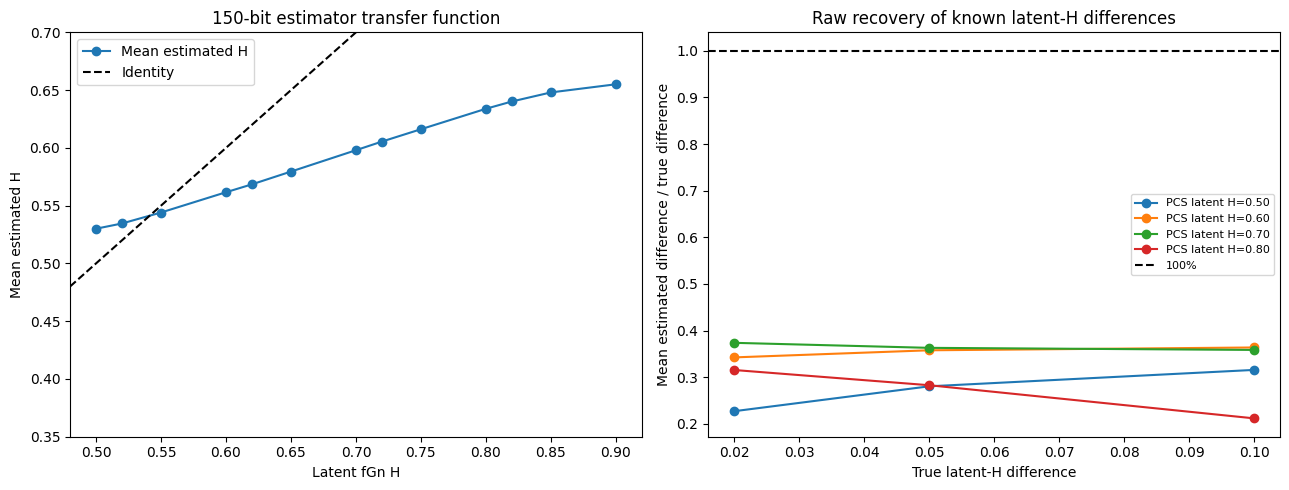

In [ ]:
# Calibrate each required H value once, then form independent Subject/PCS pairs.
required_h_values = sorted({
    round(base_h, 2) for base_h in HURST_BASE_VALUES
} | {
    round(base_h + effect, 2)
    for base_h in HURST_BASE_VALUES for effect in HURST_EFFECT_SIZES
})

hurst_calibration_draws = {}
for index, h_value in enumerate(required_h_values):
    hurst_calibration_draws[h_value] = simulate_binary_fgn_estimates(
        h_value,
        HURST_CALIBRATION_N,
        HURST_CALIBRATION_SEED + 10000 * index
    )

hurst_parameter_calibration = pd.DataFrame([
    {
        "latent_H": h_value,
        "mean_H_hat": np.mean(estimates),
        "estimator_bias": np.mean(estimates) - h_value,
        "estimator_sd": np.std(estimates, ddof=1),
        "rmse_to_latent_H": np.sqrt(np.mean(np.square(estimates - h_value))),
    }
    for h_value, estimates in hurst_calibration_draws.items()
]).sort_values("latent_H").reset_index(drop=True)

recovery_rows = []
for base_h in HURST_BASE_VALUES:
    pcs_estimates = hurst_calibration_draws[round(base_h, 2)]
    for true_difference in HURST_EFFECT_SIZES:
        subject_h = round(base_h + true_difference, 2)
        subject_estimates = hurst_calibration_draws[subject_h]
        estimated_difference = subject_estimates - pcs_estimates
        recovered_mean = np.mean(estimated_difference)
        mc_se = np.std(estimated_difference, ddof=1) / np.sqrt(len(estimated_difference))
        subject_bias = np.mean(subject_estimates) - subject_h
        pcs_bias = np.mean(pcs_estimates) - base_h
        differential_bias = subject_bias - pcs_bias
        recovery_rows.append({
            "pcs_latent_H": base_h,
            "subject_latent_H": subject_h,
            "true_H_difference": true_difference,
            "mean_estimated_difference": recovered_mean,
            "raw_recovery_ratio": recovered_mean / true_difference,
            "differential_estimator_bias": differential_bias,
            "identity_check": recovered_mean - (true_difference + differential_bias),
            "mc_ci_low": recovered_mean - 1.96 * mc_se,
            "mc_ci_high": recovered_mean + 1.96 * mc_se,
            "paired_difference_sd": np.std(estimated_difference, ddof=1),
            "paired_rmse_to_true_difference": np.sqrt(
                np.mean(np.square(estimated_difference - true_difference))
            ),
            "block_sign_concordance": np.mean(estimated_difference > 0),
            "n_generated_pairs": len(estimated_difference),
        })

known_hurst_recovery_results = pd.DataFrame(recovery_rows)
assert np.allclose(
    known_hurst_recovery_results["identity_check"], 0.0, atol=1e-12
)

print("\nEstimator calibration by latent H")
print(hurst_parameter_calibration.to_string(
    index=False, float_format=lambda x: f"{x:.6f}"
))
print("\nLatent-H difference response")
print(known_hurst_recovery_results[[
    "pcs_latent_H", "subject_latent_H", "true_H_difference",
    "mean_estimated_difference", "raw_recovery_ratio",
    "differential_estimator_bias", "mc_ci_low", "mc_ci_high",
    "paired_difference_sd", "paired_rmse_to_true_difference",
    "block_sign_concordance", "n_generated_pairs"
]].to_string(index=False, float_format=lambda x: f"{x:.6f}"))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(
    hurst_parameter_calibration["latent_H"],
    hurst_parameter_calibration["mean_H_hat"], "o-", label="Mean estimated H"
)
axes[0].plot([0.48, 0.92], [0.48, 0.92], "--", color="black", label="Identity")
axes[0].set(
    title="150-bit estimator transfer function",
    xlabel="Latent fGn H", ylabel="Mean estimated H",
    xlim=(0.48, 0.92), ylim=(0.35, 0.70)
)
axes[0].legend()

for base_h, group in known_hurst_recovery_results.groupby("pcs_latent_H"):
    axes[1].plot(
        group["true_H_difference"], group["raw_recovery_ratio"],
        "o-", label=f"PCS latent H={base_h:.2f}"
    )
axes[1].axhline(1.0, linestyle="--", color="black", label="100%")
axes[1].set(
    title="Raw recovery of known latent-H differences",
    xlabel="True latent-H difference", ylabel="Mean estimated difference / true difference"
)
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()


### Interpretation boundary for latent-H calibration

The raw recovery ratio is the mean estimated paired difference divided by the known latent-H
difference. It is not bias-corrected. The table separately reports the estimator bias at each
latent H and its difference between Subject and PCS; algebraically,

$$
E(\widehat H_S-\widehat H_P)
= (H_S-H_P)+\{\operatorname{Bias}(\widehat H_S)-\operatorname{Bias}(\widehat H_P)\}.
$$

This separation is deliberate. Subtracting the simulated differential bias and then reporting a
“corrected recovery rate” would reproduce the known input by construction and would not be an
independent validation. The Monte Carlo interval describes simulation precision, not uncertainty
for the observed experiment. The block sign-concordance column is descriptive and is not
study-level statistical power.

The calibration validates only thresholded fGn under the prespecified H values, effect sizes,
150-bit length, and this exact single-scale estimator. It does not establish recovery for every
binary long-memory generator, nonstationary process, or physical mechanism.


### Shuffle-Null Mechanism Comparison

**Paper section: S3 (methodological note, not a finding)**

The published shuffle-sensitivity analysis (Section 3.6.3) shuffles both Subject and PCS bits within a window using the same permutation, preserving their pairing while disrupting within-block ordering (**Null B** below). As an exploratory check on what this test isolates, two additional null constructions are compared against it: a **Subject-only shuffle** that leaves PCS at its recorded value (**Null A**), and a **PCS-only shuffle** that leaves Subject at its recorded value (**Null C**). All three share the same underlying permutation draws — the same random within-block permutation is drawn once per (block, window-chunk, realization) and reused across A/B/C, applied to whichever stream(s) each construction shuffles — so any difference between constructions reflects the null construction itself, not incidental randomness.

The tested statistic at every window width is the KS distance on the **paired estimand** `delta_hurst = hurst_subject - hurst_pcs`, matching the paper's primary H0a statistic. This is why a PCS-only shuffle (Null C) can move the result even though PCS is not the stream the shuffle test is nominally about — both streams enter the paired estimand.

**Run on two populations, deliberately paired as a check on each other, not as two independent results:**
- **Human 5+ vs Baseline** — the retrospectively-selected subgroup the paper's H0a statistic is about (reference KS-D should reproduce ≈0.0541, p≈0.0398).
- **Full Human population vs Baseline** — a negative control. This group has no significant reference KS-D to begin with, so if the same "resolved" A/B/C pattern shows up here too, that pattern cannot be attributed to genuine Subject/PCS structure — it must be a property of the shuffle-KS-D testing mechanism itself, independent of whether any real signal exists.

The full-population run is the point of this section, not an afterthought: its only function is to show whether the Human 5+ result can be trusted as evidence of anything, so both must be read together.

**Requires** (already defined earlier in this notebook): `h_5plus`, `human_df` (or the notebook's full-Human-population frame), `base_df`, `hurstApprox`, `ks_2samp`, `np`, `pd`.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# Shuffle-Null Mechanism Comparison (Null A / B / C)
# Run on Human 5+ (the group the paper's statistic is about) AND the full
# Human population (negative control -- no real signal to begin with).
# ═══════════════════════════════════════════════════════════════════════════
S3_WINDOWS = [1, 3, 5, 10, 25, 50, 150]
S3_N_REALIZATIONS = 200
S3_N_BOOT = 2000
S3_SEED = 20260810
S3_BITS_PER_BLOCK = 150


def s3_hurst_batch(bits2d):
    """Vectorized exact port of this notebook's scalar hurstApprox, applied
    to every row of a (n_blocks, 150) 0/1 array at once."""
    x = np.where(bits2d != 0, 1.0, -1.0)
    n = bits2d.shape[1]
    mean = x.mean(axis=1, keepdims=True)
    d = x - mean
    y = np.cumsum(d, axis=1)
    max_y = np.maximum(0.0, y.max(axis=1))
    min_y = np.minimum(0.0, y.min(axis=1))
    R = max_y - min_y
    S = np.sqrt((d * d).sum(axis=1) / n)
    S = np.where(S == 0, 1.0, S)
    ratio = np.where(R != 0, R / S, 1.0)
    H = np.log(np.where(ratio != 0, ratio, 1.0)) / np.log(n)
    H = np.where(np.isfinite(H), H, 0.5)
    return np.clip(H, 0.0, 1.0)


def s3_draw_perm_idx(n_blocks, W, rng):
    """Independent random within-chunk permutation for every (block, chunk),
    fully vectorized via argsort-of-random-values. Reused across A/B/C so
    the same draw shuffles whichever stream(s) each construction touches."""
    n_chunks = S3_BITS_PER_BLOCK // W
    rand = rng.random((n_blocks, n_chunks, W))
    return np.argsort(rand, axis=2)


def s3_apply_perm(bits2d, perm_idx, W):
    n_blocks = bits2d.shape[0]
    n_chunks = S3_BITS_PER_BLOCK // W
    reshaped = bits2d.reshape(n_blocks, n_chunks, W)
    shuffled = np.take_along_axis(reshaped, perm_idx, axis=2)
    return shuffled.reshape(n_blocks, S3_BITS_PER_BLOCK)


def s3_stack_bits(frame, col):
    return np.stack(frame[col].apply(lambda v: np.asarray(v, dtype=np.int8)).to_numpy())


def s3_pairwise_bootstrap(ks_by_w, mean_by_w, label_a, label_b, rng):
    """Bootstrap (resampling realizations, shared across all W per draw) the
    mean |KS-D difference| between two constructions, summarized across the
    full window grid."""
    obs = np.mean([abs(mean_by_w[label_a][W] - mean_by_w[label_b][W]) for W in S3_WINDOWS])
    boot = np.empty(S3_N_BOOT)
    for i in range(S3_N_BOOT):
        idx = rng.integers(0, S3_N_REALIZATIONS, size=S3_N_REALIZATIONS)
        diffs = []
        for W in S3_WINDOWS:
            resampled_a = ks_by_w[label_a][W][idx].mean()
            resampled_b = ks_by_w[label_b][W][idx].mean()
            diffs.append(abs(resampled_a - resampled_b))
        boot[i] = np.mean(diffs)
    ci = np.percentile(boot, [2.5, 97.5])
    return obs, ci


def run_s3_comparison(human_frame, baseline_frame, label):
    print("=" * 92)
    print(f"SUPPLEMENT S3 — SHUFFLE-NULL MECHANISM COMPARISON — {label}")
    print("=" * 92)

    subj_h = s3_stack_bits(human_frame, "subject_bits")
    pcs_h = s3_stack_bits(human_frame, "demon_bits")
    subj_b = s3_stack_bits(baseline_frame, "subject_bits")
    pcs_b = s3_stack_bits(baseline_frame, "demon_bits")

    orig_subj_h = s3_hurst_batch(subj_h)
    orig_pcs_h = s3_hurst_batch(pcs_h)
    orig_subj_b = s3_hurst_batch(subj_b)
    orig_pcs_b = s3_hurst_batch(pcs_b)

    ref_delta_h = orig_subj_h - orig_pcs_h
    ref_delta_b = orig_subj_b - orig_pcs_b
    ref_ks = ks_2samp(ref_delta_h, ref_delta_b)
    print(f"Reference (unshuffled) KS-D = {ref_ks.statistic:.4f}, p = {ref_ks.pvalue:.4f}")
    print(f"Block set: {label} N={len(human_frame)}, Baseline N={len(baseline_frame)}\n")

    rng = np.random.default_rng(S3_SEED)
    ks_by_w = {lbl: {W: np.empty(S3_N_REALIZATIONS) for W in S3_WINDOWS} for lbl in ("A", "B", "C")}

    for W in S3_WINDOWS:
        for r in range(S3_N_REALIZATIONS):
            perm_h = s3_draw_perm_idx(subj_h.shape[0], W, rng)
            perm_b = s3_draw_perm_idx(subj_b.shape[0], W, rng)

            shuf_subj_h = s3_hurst_batch(s3_apply_perm(subj_h, perm_h, W))
            shuf_pcs_h = s3_hurst_batch(s3_apply_perm(pcs_h, perm_h, W))
            shuf_subj_b = s3_hurst_batch(s3_apply_perm(subj_b, perm_b, W))
            shuf_pcs_b = s3_hurst_batch(s3_apply_perm(pcs_b, perm_b, W))

            # Null A: Subject shuffled, PCS held at its recorded value
            dA_h = shuf_subj_h - orig_pcs_h
            dA_b = shuf_subj_b - orig_pcs_b
            ks_by_w["A"][W][r] = ks_2samp(dA_h, dA_b).statistic

            # Null B: both streams shuffled with the SAME permutation (published, paired)
            dB_h = shuf_subj_h - shuf_pcs_h
            dB_b = shuf_subj_b - shuf_pcs_b
            ks_by_w["B"][W][r] = ks_2samp(dB_h, dB_b).statistic

            # Null C: PCS shuffled, Subject held at its recorded value
            dC_h = orig_subj_h - shuf_pcs_h
            dC_b = orig_subj_b - shuf_pcs_b
            ks_by_w["C"][W][r] = ks_2samp(dC_h, dC_b).statistic

    mean_by_w = {lbl: {W: ks_by_w[lbl][W].mean() for W in S3_WINDOWS} for lbl in ("A", "B", "C")}

    print(f"{'W':>5}{'Null A (Subject-only)':>26}{'Null B (paired)':>20}{'Null C (PCS-only)':>20}")
    for W in S3_WINDOWS:
        print(f"{W:>5}{mean_by_w['A'][W]:>26.4f}{mean_by_w['B'][W]:>20.4f}{mean_by_w['C'][W]:>20.4f}")

    print(f"\n{'Pair':>10}{'Observed mean|diff|':>22}{'95% CI':>24}")
    boot_rng = np.random.default_rng(S3_SEED + 1)
    pairwise_results = {}
    for label_a, label_b in [("A", "B"), ("A", "C"), ("B", "C")]:
        obs, ci = s3_pairwise_bootstrap(ks_by_w, mean_by_w, label_a, label_b, boot_rng)
        resolved = ci[0] > 0
        pairwise_results[(label_a, label_b)] = resolved
        print(f"{label_a}-{label_b:>8}{obs:>22.4f}   [{ci[0]:.4f}, {ci[1]:.4f}]  "
              f"{'(resolved)' if resolved else '(includes zero)'}")

    print()
    return dict(label=label, ref_ks=ref_ks.statistic, ref_p=ref_ks.pvalue,
                mean_by_w=mean_by_w, pairwise_resolved=pairwise_results)


s3_result_5plus = run_s3_comparison(h_5plus, base_df, "Human 5+")
s3_result_full = run_s3_comparison(human_df, base_df, "Full Human population")

print("=" * 92)
print("COMBINED INTERPRETATION -- read together, not separately")
print("=" * 92)
print(f"Human 5+:              reference KS-D={s3_result_5plus['ref_ks']:.4f}, "
      f"p={s3_result_5plus['ref_p']:.4f}  "
      f"({'signal present' if s3_result_5plus['ref_p'] < 0.05 else 'not significant'})")
print(f"Full Human population:  reference KS-D={s3_result_full['ref_ks']:.4f}, "
      f"p={s3_result_full['ref_p']:.4f}  "
      f"({'signal present' if s3_result_full['ref_p'] < 0.05 else 'not significant'})")

n_resolved_5plus = sum(s3_result_5plus["pairwise_resolved"].values())
n_resolved_full = sum(s3_result_full["pairwise_resolved"].values())
print(f"\nPairwise A/B/C differences resolved: Human 5+ = {n_resolved_5plus}/3, "
      f"Full population = {n_resolved_full}/3")

if n_resolved_full > 0 and s3_result_full["ref_p"] >= 0.05:
    print("\nThe full-population run has NO significant reference signal to begin with, yet")
    print("still produces resolved pairwise A/B/C differences of similar magnitude to Human")
    print("5+. This means the resolved gradient cannot be attributed to genuine Subject/PCS")
    print("structure -- it is very plausibly a property of the shuffle-KS-D testing")
    print("mechanism itself (window-size-dependent behavior of the KS-D statistic),")
    print("independent of whether any real effect exists. The Human 5+ 'resolved gradient'")
    print("should be read with this in mind: it is not established evidence of where")
    print("ordering-relevant structure lives, and may be the same artifact.")
else:
    print("\nThe full-population negative control did NOT reproduce the resolved pattern seen")
    print("in Human 5+, which is more consistent with a genuine, group-specific effect than")
    print("with a testing-mechanism artifact -- though this remains exploratory and")
    print("retrospective either way.")

SUPPLEMENT S3 — SHUFFLE-NULL MECHANISM COMPARISON — Human 5+
Reference (unshuffled) KS-D = 0.0541, p = 0.0398
Block set: Human 5+ N=840, Baseline N=3090

    W     Null A (Subject-only)     Null B (paired)   Null C (PCS-only)
    1                    0.0541              0.0541              0.0541
    3                    0.0458              0.0498              0.0536
    5                    0.0547              0.0599              0.0571
   10                    0.0559              0.0632              0.0588
   25                    0.0576              0.0588              0.0544
   50                    0.0425              0.0386              0.0500
  150                    0.0367              0.0336              0.0408

      Pair   Observed mean|diff|                  95% CI
A-       B                0.0035   [0.0030, 0.0041]  (resolved)
A-       C                0.0040   [0.0034, 0.0046]  (resolved)
B-       C                0.0049   [0.0044, 0.0053]  (resolved)

SUPPLEMENT S3 — SHU

### Composition-Conditioning Checks — Two Distinct Questions

This subsection reports two composition-conditioned analyses that ask different questions and must not be read as corroborating one another:

1. **A selection-adjusted tail probability**, testing whether the delta-of-deltas produced by searching the three documented session-count thresholds (2+, 3+, 5+) is unusual relative to a null that preserves each stream's own bit composition and randomizes only order — i.e., does the threshold-search procedure itself produce an unusually extreme result?
2. **A point-estimate sensitivity check**, testing whether the raw Human-vs-Baseline HRS contrast changes once each individual block's own composition-conditioned expectation is subtracted — i.e., is the raw contrast confounded by bit composition at all, independent of any threshold search?

The first produces a one-sided tail area (a significance-style output). The second produces a shift in a point estimate; no tail area is computed. A small selection-adjusted tail probability and a negligible point-estimate shift are not two forms of the same evidence — one addresses selection bias from the threshold search, the other addresses whether composition confounds the estimate itself. They are reported together because both bear on composition, not because either corroborates the other.

#### Test 1 — Selection-adjusted tail probability (documented 2+/3+/5+ threshold search)

**Question: is the threshold-search result unusual, given composition alone?**

For each retained Human/Baseline block, temporal order is randomized within Subject and within PCS separately, conditional on that block's own observed composition (its exact count of ones), preserving every stream's exact composition and the session/contributor structure. The delta-of-deltas statistic (Human threshold-subgroup mean `delta_hurst` minus Baseline mean `delta_hurst`) is recomputed on each randomization, and the strongest positive result across the three documented thresholds is retained per draw — exactly mirroring the documented search. This yields a one-sided Monte Carlo tail area: how often would this search process produce a result at least this extreme under composition-preserving reordering alone. This is a **partial** selection calibration — it adjusts only for the documented 2+/3+/5+ search, not the full historical exploratory process, which cannot be reconstructed.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# TEST 1: SELECTION-ADJUSTED TAIL PROBABILITY — DOCUMENTED 2+/3+/5+ SEARCH
# ═══════════════════════════════════════════════════════════════════════════
CA_SEED = 20260805
CA_REPS = 20_000
CA_BANK_SIZE = 4_096
CA_THRESHOLDS = (2, 3, 5)

def ca_rs_score_batch_150(bit_matrix):
    """Vectorized exact n=150 counterpart of hurstApprox for 0/1 rows."""
    bits = np.asarray(bit_matrix, dtype=np.int8)
    x = np.where(bits != 0, 1.0, -1.0)
    centered = x - x.mean(axis=1, keepdims=True)
    cumulative = np.cumsum(centered, axis=1)
    maximum = np.maximum(0.0, cumulative.max(axis=1))
    minimum = np.minimum(0.0, cumulative.min(axis=1))
    spread = maximum - minimum
    s2 = np.square(centered).sum(axis=1)
    scale = np.where(s2 > 0, np.sqrt(s2 / 150.0), 1.0)
    ratio = np.divide(spread, scale, out=np.ones_like(spread), where=scale != 0)
    ratio = np.where(np.isfinite(ratio) & (ratio != 0), ratio, 1.0)
    score = np.log(ratio) / np.log(150.0)
    return np.clip(np.where(np.isfinite(score), score, 0.5), 0.0, 1.0)

def ca_uniform_rows_with_k_ones(k, n_rows, rng):
    k = int(k)
    if k == 0:
        return np.zeros((n_rows, 150), dtype=np.int8)
    if k == 150:
        return np.ones((n_rows, 150), dtype=np.int8)
    random_keys = rng.random((n_rows, 150))
    one_positions = np.argpartition(random_keys, kth=k - 1, axis=1)[:, :k]
    rows = np.zeros((n_rows, 150), dtype=np.int8)
    rows[np.arange(n_rows)[:, None], one_positions] = 1
    return rows

ca_pcs_col = "pcs_bits" if "pcs_bits" in df.columns else "demon_bits"
ca_rows = df.loc[df["condition"].isin(["baseline", "human"]),
                  ["condition", "participant_id", "session_id", "session_count",
                   "subject_bits", ca_pcs_col, "hurst_subject", "hurst_pcs", "delta_hurst"]].copy()
ca_rows["subject_ones"] = ca_rows["subject_bits"].apply(lambda b: int(np.asarray(b, dtype=np.int8).sum()))
ca_rows["pcs_ones"] = ca_rows[ca_pcs_col].apply(lambda b: int(np.asarray(b, dtype=np.int8).sum()))

ca_base_mask = ca_rows["condition"].eq("baseline").to_numpy()
ca_human_mask = ca_rows["condition"].eq("human").to_numpy()
ca_session_count = ca_rows["session_count"].to_numpy(float)
ca_thr_masks = {t: ca_human_mask & (ca_session_count >= t) for t in CA_THRESHOLDS}

ca_base_delta_obs = float(ca_rows.loc[ca_base_mask, "delta_hurst"].mean())
ca_obs_rows = []
for t, mask in ca_thr_masks.items():
    sub_delta = float(ca_rows.loc[mask, "delta_hurst"].mean())
    ca_obs_rows.append({"Threshold": f"Human {t}+", "Delta-of-deltas vs Baseline": sub_delta - ca_base_delta_obs})
ca_obs_table = pd.DataFrame(ca_obs_rows)
ca_obs_max = float(ca_obs_table["Delta-of-deltas vs Baseline"].max())

ca_rng_bank = np.random.default_rng(CA_SEED)
ca_one_counts = sorted(set(ca_rows["subject_ones"]) | set(ca_rows["pcs_ones"]))
ca_score_bank = {k: ca_rs_score_batch_150(ca_uniform_rows_with_k_ones(k, CA_BANK_SIZE, ca_rng_bank)) for k in ca_one_counts}

def ca_draw_scores(one_counts, n_draws, rng):
    one_counts = np.asarray(one_counts, dtype=np.int16)
    result = np.empty((len(one_counts), n_draws), dtype=np.float32)
    for k in np.unique(one_counts):
        idx = np.flatnonzero(one_counts == k)
        bank = ca_score_bank[int(k)]
        draw_idx = rng.integers(0, len(bank), size=(len(idx), n_draws))
        result[idx, :] = bank[draw_idx]
    return result

ca_rng_null = np.random.default_rng(CA_SEED + 1)
ca_null_max = np.empty(CA_REPS)
ca_subject_counts = ca_rows["subject_ones"].to_numpy(np.int16)
ca_pcs_counts = ca_rows["pcs_ones"].to_numpy(np.int16)
ca_chunk = 250
for start in range(0, CA_REPS, ca_chunk):
    stop = min(start + ca_chunk, CA_REPS)
    width = stop - start
    subj_scores = ca_draw_scores(ca_subject_counts, width, ca_rng_null)
    pcs_scores = ca_draw_scores(ca_pcs_counts, width, ca_rng_null)
    paired = subj_scores - pcs_scores
    base_delta = paired[ca_base_mask, :].mean(axis=0)
    thr_contrasts = np.vstack([paired[ca_thr_masks[t], :].mean(axis=0) - base_delta for t in CA_THRESHOLDS])
    ca_null_max[start:stop] = thr_contrasts.max(axis=0)

ca_tail = (1 + np.count_nonzero(ca_null_max >= ca_obs_max)) / (CA_REPS + 1)

print("=" * 90)
print("TEST 1 RESULT: selection-adjusted tail probability")
print("=" * 90)
display(ca_obs_table.round(6))
print(f"Observed maximum positive delta-of-deltas: {ca_obs_max:+.6f}")
print(f"2+/3+/5+ maximum-positive tail area (selection-adjusted): {ca_tail:.6f}")
print("\nThis is a ONE-SIDED TAIL PROBABILITY answering: how unusual is the threshold-search result")
print("under composition-preserving reordering alone. It says nothing about whether the raw point")
print("estimate itself is shifted by composition -- that is Test 2, below.")

TEST 1 RESULT: selection-adjusted tail probability


,Threshold,Delta-of-deltas vs Baseline
0,Human 2+,0.005633
1,Human 3+,0.005148
2,Human 5+,0.006090


Observed maximum positive delta-of-deltas: +0.006090
2+/3+/5+ maximum-positive tail area (selection-adjusted): 0.008000

This is a ONE-SIDED TAIL PROBABILITY answering: how unusual is the threshold-search result
under composition-preserving reordering alone. It says nothing about whether the raw point
estimate itself is shifted by composition -- that is Test 2, below.


#### Test 2 — Point-estimate sensitivity check (does composition confound the raw contrast?)

**Question: does the raw contrast itself move once composition is accounted for, independent of any threshold search?**

For every distinct block composition (count of ones, 0–150), a composition-conditioned null expectation for HRS under random ordering is estimated by Monte Carlo, reusing `hurst_approx_matrix` from the latent-H calibration above. Every retained block's observed HRS is compared to its own composition-matched expectation, giving a per-block "excess" value — no threshold selection is involved anywhere in this test. The raw Human-vs-Baseline HRS contrast is then compared directly to the same contrast computed on the composition-conditioned excess values, for both Subject and PCS streams, at Human(all) and Human5+.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# TEST 2: POINT-ESTIMATE SENSITIVITY CHECK — RAW VS COMPOSITION-CONDITIONED
# ═══════════════════════════════════════════════════════════════════════════
CB_SEED = 20260808
CB_DRAWS_PER_K = 20_000

cb_rng = np.random.default_rng(CB_SEED)
cb_null_mean = np.zeros(151)
for k in range(151):
    if k == 0 or k == 150:
        continue
    batch = ca_uniform_rows_with_k_ones(k, CB_DRAWS_PER_K, cb_rng)
    cb_null_mean[k] = hurst_approx_matrix(batch).mean()

cb_pcs_col = "pcs_bits" if "pcs_bits" in df.columns else "demon_bits"
cb_df = df.dropna(subset=["hurst_subject", "hurst_pcs"]).copy()
cb_df["subject_k"] = cb_df["subject_bits"].apply(lambda b: int(np.asarray(b, dtype=np.int8).sum()))
cb_df["pcs_k"] = cb_df[cb_pcs_col].apply(lambda b: int(np.asarray(b, dtype=np.int8).sum()))
cb_df["subject_excess"] = cb_df["hurst_subject"] - cb_null_mean[cb_df["subject_k"].to_numpy()]
cb_df["pcs_excess"] = cb_df["hurst_pcs"] - cb_null_mean[cb_df["pcs_k"].to_numpy()]

def cb_session_draws(sub, col, seed):
    g = sub.groupby("session_id").agg(s=(col, "sum"), n=(col, "size"))
    s, n = g.s.to_numpy(), g.n.to_numpy()
    est = s.sum() / n.sum()
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(g), size=(10000, len(g)))
    return est, s[idx].sum(axis=1) / n[idx].sum(axis=1)

def cb_contributor_draws(sub, col, seed):
    g = sub.groupby("participant_id").agg(s=(col, "sum"), n=(col, "size"))
    s, n = g.s.to_numpy(), g.n.to_numpy()
    est = s.sum() / n.sum()
    rng = np.random.default_rng(seed)
    J = len(g)
    idx = rng.integers(0, J, size=(10000, J))
    return est, s[idx].sum(axis=1) / n[idx].sum(axis=1)

cb_base = cb_df[cb_df.condition == "baseline"]
cb_human_all = cb_df[cb_df.condition == "human"]
cb_human5 = cb_human_all[cb_human_all.session_count >= 5]

print("=" * 90)
print("TEST 2 RESULT: raw vs composition-conditioned point-estimate contrasts")
print("=" * 90)

for label, sub, hierfn, seedbase in [("Human(all)", cb_human_all, cb_contributor_draws, 10),
                                       ("Human5+", cb_human5, cb_contributor_draws, 20)]:
    for stream, raw_col, exc_col in [("Subject", "hurst_subject", "subject_excess"),
                                       ("PCS", "hurst_pcs", "pcs_excess")]:
        raw_est_h, raw_boot_h = hierfn(sub, raw_col, seedbase + 1)
        raw_est_b, raw_boot_b = cb_session_draws(cb_base, raw_col, seedbase + 2)
        exc_est_h, exc_boot_h = hierfn(sub, exc_col, seedbase + 3)
        exc_est_b, exc_boot_b = cb_session_draws(cb_base, exc_col, seedbase + 4)

        raw_contrast = raw_est_h - raw_est_b
        exc_contrast = exc_est_h - exc_est_b
        raw_ci = np.quantile(raw_boot_h - raw_boot_b, [0.025, 0.975])
        exc_ci = np.quantile(exc_boot_h - exc_boot_b, [0.025, 0.975])
        shift = exc_contrast - raw_contrast

        print(f"\n{label} {stream} vs Baseline {stream}:")
        print(f"  RAW contrast:                 {raw_contrast:+.6f}  95% CI=[{raw_ci[0]:+.6f}, {raw_ci[1]:+.6f}]")
        print(f"  Composition-conditioned:      {exc_contrast:+.6f}  95% CI=[{exc_ci[0]:+.6f}, {exc_ci[1]:+.6f}]")
        print(f"  Shift from conditioning:      {shift:+.6f}")

print("\nThis is a POINT-ESTIMATE SHIFT, not a tail probability. It answers whether raw bit")
print("composition confounds the contrast itself -- it does not test whether the threshold-search")
print("selection procedure (Test 1, above) produced an unusually extreme result.")

TEST 2 RESULT: raw vs composition-conditioned point-estimate contrasts

Human(all) Subject vs Baseline Subject:
  RAW contrast:                 +0.002101  95% CI=[+0.000042, +0.004096]
  Composition-conditioned:      +0.002106  95% CI=[+0.000057, +0.004127]
  Shift from conditioning:      +0.000005

Human(all) PCS vs Baseline PCS:
  RAW contrast:                 -0.000767  95% CI=[-0.002638, +0.001209]
  Composition-conditioned:      -0.000751  95% CI=[-0.002659, +0.001119]
  Shift from conditioning:      +0.000016

Human5+ Subject vs Baseline Subject:
  RAW contrast:                 +0.003145  95% CI=[+0.001542, +0.005003]
  Composition-conditioned:      +0.003159  95% CI=[+0.001518, +0.005052]
  Shift from conditioning:      +0.000013

Human5+ PCS vs Baseline PCS:
  RAW contrast:                 -0.002945  95% CI=[-0.007900, -0.000435]
  Composition-conditioned:      -0.002929  95% CI=[-0.007805, -0.000451]
  Shift from conditioning:      +0.000016

This is a POINT-ESTIMATE SHIFT, no

#### Reading these two tests together

- **Test 1** answers: *"Given that the threshold search happened, is the result unusual?"* — a selection-adjusted one-sided tail probability.
- **Test 2** answers: *"Does raw bit composition, on its own, explain the contrast?"* — a point-estimate sensitivity check with no tail probability.

Neither result should be cited as corroborating the other. A reader should not treat a small tail probability from Test 1 and a negligible shift from Test 2 as two independent confirmations of the same claim — they are answers to two different questions about composition, computed with different constructions and different outputs.

# Notebook 1 Conclusions and Transition to Notebook 2

## Structural architecture status

- The five supplied frozen inputs are loaded once and fingerprinted.
- The three-subtest NIST-style audit battery is reported on the 1,771 audits with complete stored subtests; the 120 legacy audits remain explicitly missing, and the battery is not described as a full SP 800-22 suite.
- Frozen block/session/raw-call joins are cardinality-checked, and the 157 excluded rows are reconciled before analysis.
- For every matched raw call, the 301-bit hash, physical split, bit-0 Subject/PCS assignment, and stored labeled streams agree exactly.
- Every retained block is scored against its actual `target_bit`; literal one-fractions are kept distinct from target-aligned hit rates.
- Canonical paired hit-rate and R/S-score estimands are row aligned.
- At the implemented 150-bit half length, the Baseline physical-half synthesis found no detected marginal R/S-score asymmetry or same-call linear association; this is not treated as equivalence or complete independence.
- Session-clustered bootstrap, permutation, and paired sign-flip procedures preserve the relevant session hierarchy; Human-participant sensitivity is reported where stable repeated-participant identifiers are available.
- Artifact injection now uses specified upstream raw-bit perturbations and reports recovery error with session-aware uncertainty, including a stream-specific control and unequal-half failure case.
- A separate thresholded-fGn calibration reports how the exact 150-bit estimator responds to known latent-H differences and shows how estimator bias changes with latent H.
- Hit-count dispersion/tail diagnostics now use discrete events and whole-session uncertainty; same-position mutual information is bias-calibrated with within-block circular shifts and session-aware inference.
- Paper-required PCS within-block lag-1/n-gram/profile-slope comparisons and Subject–PCS correlation/joint-distribution condition comparisons now move intact session bundles; the paired R/S-score-delta variance comparison uses one session mean per session.

Together, these checks verify the frozen-data encoding and exercise the paired-analysis implementation under the specified diagnostics and simulated mechanisms. The latent-H calibration is limited to its generator, parameter values, sequence length, and estimator. The notebook does not establish universal independence, unbiasedness, recovery, or cancellation of all possible artifacts. Notebook 2 analyses must use the canonical paired estimands and preserve session and participant dependence appropriate to each claim.
